# Classification error analysis

Six-step analysis of out-of-fold SVM predictions and **previously computed SHAP values**.
Class 0: clean read; class 1: infected read. 

Steps 1–2 use the full prediction export when feature counts are available. Steps 3–6 use only
the saved SHAP subset. Prediction groups refer to the replayed SVM; SHAP values explain the
older model's infection probability. Their agreement is audited below.

Results are descriptive: repeated sequences and paired clean/infected reads are not independent
observations. Effect sizes are reported without read-level significance tests. Cluster structure
is exploratory and does not establish distinct biological mechanisms.


## Setup and data validation

Run the cells in order after the export script finishes. Adjust the configuration below for another
experiment. Figures are saved as vector PDF and 300-dpi PNG; tables are saved as CSV.
Dependencies: NumPy, pandas, Matplotlib, SciPy, scikit-learn and IPython.


In [23]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, leaves_list, cut_tree
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_score
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from matplotlib.lines import Line2D
import plotly.graph_objects as go


DATASET, ALGORITHM = "ecoli", "svm"
FRAGMENT_LENGTH, RETENTION_POSITION, ENCRYPTION_KEY = 5, 5, 0
K, N_FEATURES, TOP_N = 4, 100, 20
SAVE_OUTPUTS = True
MAX_CLUSTERS = 6
MAX_WATERFALL_FEATURES = 10

REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "experiments/comparison/fp_error_analysis.py").exists()),
    Path("/home/cosimo/Desktop/PhD/Cyberbiosecurity/DNA_attacks"),
)
TAG = (f"{ALGORITHM}_{DATASET}_fl{FRAGMENT_LENGTH}_rp{RETENTION_POSITION}"
       f"_ek{ENCRYPTION_KEY}_k{K}_n{N_FEATURES}")
METRICS_DIR = (REPO_ROOT / "experiments/results/metrics" / ALGORITHM / DATASET
               / f"fragment_len_{FRAGMENT_LENGTH}" / f"retention_pos_{RETENTION_POSITION}"
               / f"encryption_key_{ENCRYPTION_KEY}")
DATA_DIR = METRICS_DIR / "fp_error_analysis"
SHAP_DIR = METRICS_DIR / "shap/All_split"
OUTPUT_DIR = Path(os.environ.get(
    "DNA_ERROR_ANALYSIS_OUTPUT", str(DATA_DIR / "notebook_outputs" / TAG)
))

GROUPS = ["TN", "FP", "TP", "FN"]
COLORS = {"TN": "#0072B2", "FP": "#D55E00", "TP": "#009E73", "FN": "#CC79A7"}
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 14)

def show_figure(fig, name):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("pdf", "png"):
            fig.savefig(OUTPUT_DIR / f"{name}.{extension}", bbox_inches="tight")
    plt.show()
    plt.close(fig)

def table(frame, name, rows=25):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        frame.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    display(frame.head(rows).round(4))

def require(condition, message):
    if not condition:
        raise ValueError(message)

print(f"Experiment: {TAG}")
print(f"Outputs: {OUTPUT_DIR}")


Experiment: svm_ecoli_fl5_rp5_ek0_k4_n100
Outputs: /home/cosimo/Desktop/PhD/Cyberbiosecurity/DNA_attacks/experiments/results/metrics/svm/ecoli/fragment_len_5/retention_pos_5/encryption_key_0/fp_error_analysis/notebook_outputs/svm_ecoli_fl5_rp5_ek0_k4_n100


In [2]:
prediction_path = DATA_DIR / f"all_reads_predictions_{TAG}.csv"
require(prediction_path.exists(), "Run fp_error_analysis.py before this notebook.")
pred = pd.read_csv(prediction_path)
required = {"read_id", "outer_fold", "true_label", "predicted_label", "outcome",
            "probability_infected", "decision_score"}
require(required.issubset(pred.columns), "The prediction export is missing required columns.")
require(not pred[list(required)].isna().any().any(), "Missing prediction values; the export may be incomplete.")
require(pred.read_id.is_unique, "read_id must be unique in the prediction export.")
require(pred.true_label.isin([0, 1]).all() and pred.predicted_label.isin([0, 1]).all(), "Labels must be binary.")
require(pred.probability_infected.between(0, 1).all(), "Probabilities must lie in [0, 1].")
require(np.isfinite(pred.decision_score).all(), "Non-finite decision scores.")
expected_group = np.select(
    [(pred.true_label == 0) & (pred.predicted_label == 0),
     (pred.true_label == 0) & (pred.predicted_label == 1),
     (pred.true_label == 1) & (pred.predicted_label == 1)],
    ["TN", "FP", "TP"], default="FN",
)
require(np.array_equal(pred.outcome.to_numpy(), expected_group), "Inconsistent prediction groups.")
pred = pred.sort_values("read_id").set_index("read_id", drop=False)
pred["absolute_decision_score"] = pred.decision_score.abs()
pred["margin_percentile_within_fold"] = pred.groupby("outer_fold")[
    "absolute_decision_score"
].rank(method="average", pct=True)
pred["probability_of_predicted_class"] = np.where(
    pred.predicted_label.eq(1), pred.probability_infected, 1 - pred.probability_infected
)

reference_path = DATA_DIR / f"shap_reference_{TAG}.csv.gz"
raw_shap_path = SHAP_DIR / f"shap_per_read_ALL_{TAG}.csv"
source_path = reference_path if reference_path.exists() else raw_shap_path
require(source_path.exists(), "Saved per-read SHAP data were not found.")
raw = pd.read_csv(source_path).rename(columns={"split": "outer_fold"})
require({"read_id", "outer_fold", "label", "k_mer", "feature_value", "shap_value"}.issubset(raw.columns),
        "The saved SHAP file is missing required columns.")
require(not raw.duplicated(["read_id", "outer_fold", "k_mer"]).any(), "Duplicate SHAP entries.")
require(raw.groupby("read_id").outer_fold.nunique().eq(1).all(), "A read appears in multiple SHAP folds.")
require(np.isfinite(raw[["feature_value", "shap_value"]]).all().all(), "Non-finite SHAP input data.")

base_by_fold, source_files = {}, [prediction_path, source_path]
for fold in sorted(raw.outer_fold.unique()):
    path = SHAP_DIR / f"shap_values_{TAG}_split{int(fold)}.npz"
    if path.exists():
        with np.load(path, allow_pickle=False) as saved:
            base_by_fold[int(fold)] = float(np.asarray(saved["expected_value"]).item())
        source_files.append(path)
    else:
        require("base_value" in raw, f"Missing saved baseline for fold {fold}.")
        values = raw.loc[raw.outer_fold.eq(fold), "base_value"].unique()
        require(len(values) == 1 and np.isfinite(values[0]), "Invalid SHAP baseline.")
        base_by_fold[int(fold)] = float(values[0])

shap_long = raw[["read_id", "outer_fold", "label", "k_mer", "feature_value", "shap_value"]].merge(
    pred[list(required)].reset_index(drop=True),
    on=["read_id", "outer_fold"], how="left", validate="many_to_one", indicator=True,
)
require(shap_long._merge.eq("both").all(), "Some saved SHAP reads do not match the current prediction export.")
require(shap_long.label.eq(shap_long.true_label).all(), "SHAP and prediction labels differ.")
shap_long = shap_long.drop(columns="_merge")
shap_long["base_value"] = shap_long.outer_fold.map(base_by_fold)
phi = shap_long.pivot(index="read_id", columns="k_mer", values="shap_value").sort_index()
saved_features = shap_long.pivot(index="read_id", columns="k_mer", values="feature_value").reindex_like(phi)
require(not phi.isna().any().any() and not saved_features.isna().any().any(), "Incomplete SHAP feature vectors.")
require(phi.shape[1] == N_FEATURES, "Saved SHAP feature count differs from N_FEATURES.")
reference = pred.loc[phi.index].copy()
reference["base_value"] = reference.outer_fold.map(base_by_fold)
reference["old_probability_from_shap"] = reference.base_value + phi.sum(axis=1)
require(reference.old_probability_from_shap.between(-1e-6, 1 + 1e-6).all(),
        "Saved SHAP values do not reconstruct a probability; verify explained output and baseline.")
reference["probability_difference"] = reference.probability_infected - reference.old_probability_from_shap

feature_columns = [f"kmer__{k}" for k in phi.columns]
if set(feature_columns).issubset(pred.columns):
    features = pred[feature_columns].rename(columns=lambda s: s.removeprefix("kmer__"))
    np.testing.assert_allclose(features.loc[phi.index, phi.columns], saved_features, atol=0, rtol=0)
    feature_scope = f"All exported reads (n = {len(features):,})"
else:
    features = saved_features.copy()
    feature_scope = f"Saved SHAP subset only (n = {len(features):,})"
    display(Markdown("**Full feature export is not yet available.** Step 2 uses saved feature values "
                     "for the SHAP subset. Rerun after the updated export script completes to use all reads."))
require(np.isfinite(features).all().all() and features.ge(0).all().all(), "Invalid k-mer counts.")
feature_meta = pred.loc[features.index]

summary_path = SHAP_DIR / f"shap_kmer_importance_SUMMARY_{TAG}.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    top_features = summary.sort_values("mean", ascending=False).k_mer.head(TOP_N).tolist()
    source_files.append(summary_path)
else:
    top_features = phi.abs().mean().sort_values(ascending=False).head(TOP_N).index.tolist()
require(set(top_features).issubset(phi.columns), "Global top features do not match saved SHAP columns.")

coverage = pd.DataFrame({
    "outcome": GROUPS,
    "all_reads": pred.outcome.value_counts().reindex(GROUPS, fill_value=0).values,
    "explained_reads": reference.outcome.value_counts().reindex(GROUPS, fill_value=0).values,
})
coverage["SHAP_coverage_percent"] = 100 * coverage.explained_reads / coverage.all_reads.replace(0, np.nan)
table(coverage, "00_coverage")
print(f"SHAP: {len(reference):,} reads, {phi.shape[1]} features. Step 2: {feature_scope}.")

audit = reference.groupby("outer_fold").agg(
    explained_reads=("outcome", "size"),
    saved_SHAP_baseline=("base_value", "first"),
    mean_absolute_probability_difference=("probability_difference", lambda s: s.abs().mean()),
    max_absolute_probability_difference=("probability_difference", lambda s: s.abs().max()),
).reset_index()
table(audit, "00_shap_probability_alignment")
manifest = {
    "experiment": TAG, "prediction_reads": len(pred), "SHAP_reads": len(reference),
    "feature_scope": feature_scope, "top_features": top_features,
    "cluster_settings": {"min_k": 2, "max_k": MAX_CLUSTERS,
                         "partitions": "all", "silhouette_use": "descriptive_only"},
    "versions": {name: importlib.metadata.version(name) for name in
                 ["numpy", "pandas", "matplotlib", "scipy", "scikit-learn"]},
    "sources": [{"path": str(p), "sha256": hashlib.sha256(p.read_bytes()).hexdigest()}
                for p in source_files],
}
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "00_provenance.json").write_text(json.dumps(manifest, indent=2))


,outcome,all_reads,explained_reads,SHAP_coverage_percent
0,TN,8842,911,10.3031
1,FP,1158,119,10.2763
2,TP,9336,895,9.5865
3,FN,664,75,11.2952


SHAP: 2,000 reads, 100 features. Step 2: All exported reads (n = 20,000).


,outer_fold,explained_reads,saved_SHAP_baseline,mean_absolute_probability_difference,max_absolute_probability_difference
0,0,400,0.9578,0.0008,0.0070
1,1,400,0.9662,0.0013,0.0112
2,2,400,0.9792,0.0020,0.0156
3,3,400,0.9901,0.0007,0.0084
4,4,400,0.9478,0.0010,0.0080


## 1. Characterize classification errors

Use the recorded predictions to define TN, FP, TP and FN. The SVM decision boundary is at score 0;
probability 0.5 is an uncertainty reference and need not coincide with that boundary. Probabilities
are model estimates, not independently verified calibration. Decision-score magnitudes are also
summarized by fold because different fitted models need not have comparable scales.


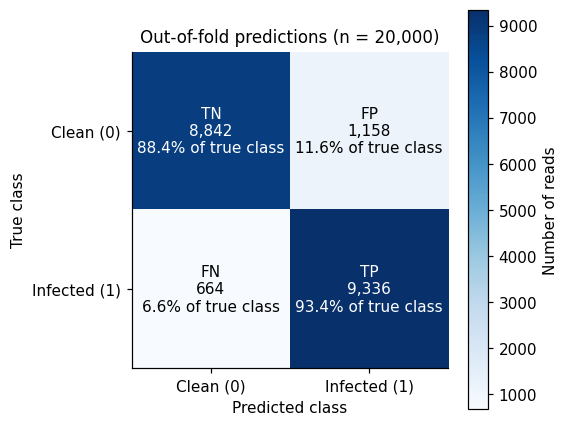

,outcome,n,median_probability_infected,probability_q25,probability_q75,median_absolute_score
0,TN,8842,0.0206,0.0063,0.0516,1.1372
1,FP,1158,0.9929,0.9552,1.0000,0.8498
2,TP,9336,1.0000,0.9963,1.0000,1.5538
3,FN,664,0.4313,0.1499,0.6357,0.3296


,outer_fold,outcome,n,median_probability_infected,median_absolute_score
0,0,FN,137,0.5097,0.2584
1,0,FP,260,0.9963,0.9752
2,0,TN,1740,0.0173,1.1673
3,0,TP,1863,1.0000,1.5188
4,1,FN,152,0.2994,0.4480
5,1,FP,211,0.9892,0.8035
6,1,TN,1789,0.0262,1.0987
7,1,TP,1848,1.0000,1.5462
8,2,FN,128,0.4460,0.3129
9,2,FP,197,0.9835,0.6641


In [3]:
confusion = pd.crosstab(pred.true_label, pred.predicted_label).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(confusion.to_numpy(), cmap="Blues")
names = np.array([["TN", "FP"], ["FN", "TP"]])
for i in range(2):
    for j in range(2):
        count = confusion.iloc[i, j]
        proportion = count / confusion.iloc[i].sum() if confusion.iloc[i].sum() else np.nan
        ax.text(j, i, f"{names[i, j]}\n{count:,}\n{proportion:.1%} of true class",
                ha="center", va="center", color="white" if count > confusion.to_numpy().max() / 2 else "black")
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Clean (0)", "Infected (1)"],
       yticklabels=["Clean (0)", "Infected (1)"], xlabel="Predicted class", ylabel="True class",
       title=f"Out-of-fold predictions (n = {len(pred):,})")
fig.colorbar(im, ax=ax, label="Number of reads")
fig.tight_layout()
show_figure(fig, "01_confusion_matrix")

confidence_summary = pred.groupby("outcome").agg(
    n=("outcome", "size"),
    median_probability_infected=("probability_infected", "median"),
    probability_q25=("probability_infected", lambda s: s.quantile(.25)),
    probability_q75=("probability_infected", lambda s: s.quantile(.75)),
    median_absolute_score=("absolute_decision_score", "median"),
).reindex(GROUPS).reset_index()
table(confidence_summary, "01_confidence_summary")
table(pred.groupby(["outer_fold", "outcome"]).agg(
    n=("outcome", "size"), median_probability_infected=("probability_infected", "median"),
    median_absolute_score=("absolute_decision_score", "median"),
).reset_index(), "01_confidence_by_fold")


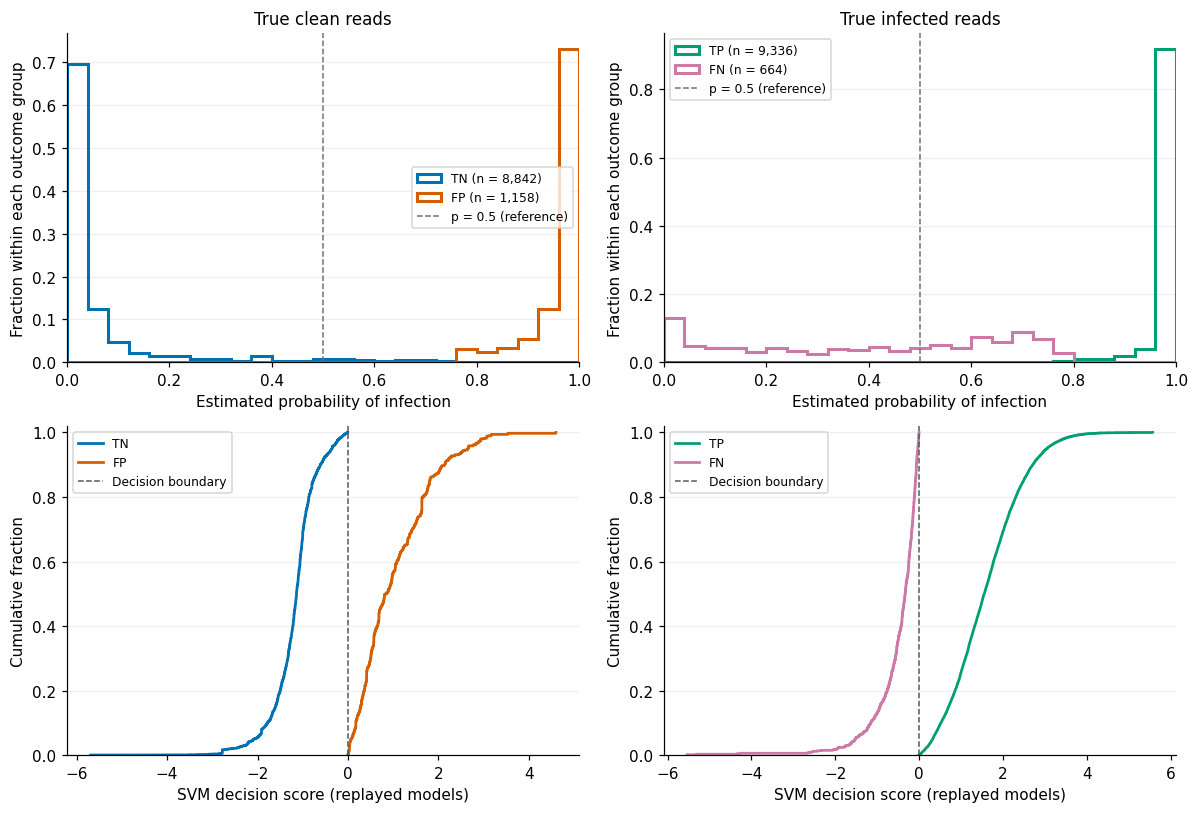

Recorded prediction differs from a p ≥ 0.5 rule for 618 reads.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for col, pair in enumerate([("TN", "FP"), ("TP", "FN")]):
    for group in pair:
        subset = pred.loc[pred.outcome.eq(group)]
        if subset.empty:
            continue
        axes[0, col].hist(subset.probability_infected, bins=np.linspace(0, 1, 26),
                          weights=np.ones(len(subset)) / len(subset), histtype="step", linewidth=2,
                          color=COLORS[group], label=f"{group} (n = {len(subset):,})")
        values = np.sort(subset.decision_score.to_numpy())
        axes[1, col].step(values, np.arange(1, len(values) + 1) / len(values), where="post",
                          color=COLORS[group], linewidth=1.8, label=group)
    axes[0, col].axvline(.5, color="0.45", linestyle="--", linewidth=1, label="p = 0.5 (reference)")
    axes[1, col].axvline(0, color="0.35", linestyle="--", linewidth=1, label="Decision boundary")
    axes[0, col].set(xlabel="Estimated probability of infection", ylabel="Fraction within each outcome group",
                     title="True clean reads" if col == 0 else "True infected reads", xlim=(0, 1))
    axes[1, col].set(xlabel="SVM decision score (replayed models)", ylabel="Cumulative fraction", ylim=(0, 1.02))
    for row in range(2):
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(axis="y", alpha=.2)
fig.tight_layout()
show_figure(fig, "01_probability_and_score_distributions")

probability_prediction_disagreement = ((pred.probability_infected >= .5).astype(int) != pred.predicted_label)
print(f"Recorded prediction differs from a p ≥ 0.5 rule for {probability_prediction_disagreement.sum():,} reads.")


## 2. Compare feature distributions

Compare raw k-mer counts in FP versus TN and FN versus TP. Boxes show medians and interquartile
ranges; whiskers extend to 1.5 IQR and points beyond them are retained. Cliff's δ summarizes the
distributional difference: positive values indicate larger counts in the error group. It is a
descriptive effect size with ties included; no independence-based p-values are reported.


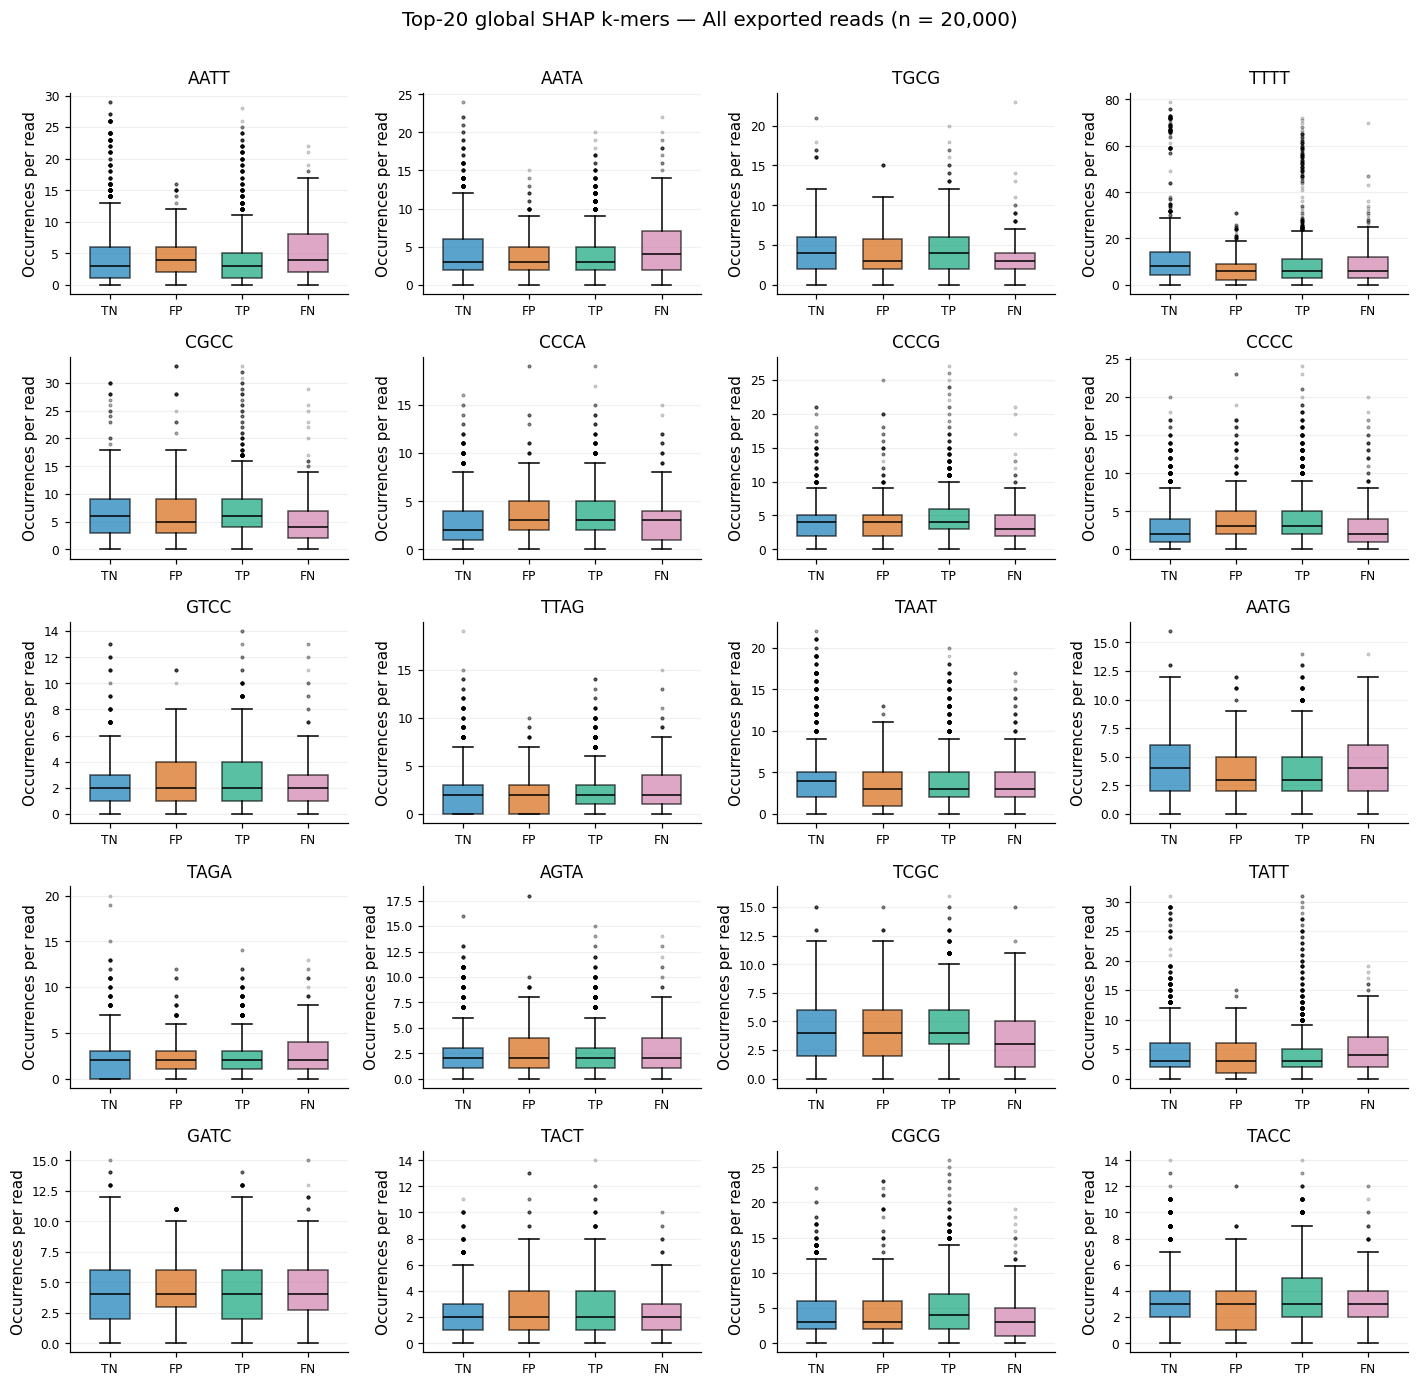

,k_mer,outcome,n,mean,median,q25,q75,presence_rate
0,AATT,TN,8842,4.3196,3.0,1.0,6.00,0.8763
1,AATT,FP,1158,4.0561,4.0,2.0,6.00,0.9059
2,AATT,TP,9336,3.6549,3.0,1.0,5.00,0.8935
3,AATT,FN,664,5.1867,4.0,2.0,8.00,0.9247
4,AATA,TN,8842,4.2566,3.0,2.0,6.00,0.9271
5,AATA,FP,1158,3.8005,3.0,2.0,5.00,0.8938
6,AATA,TP,9336,3.6201,3.0,2.0,5.00,0.9124
7,AATA,FN,664,4.5979,4.0,2.0,7.00,0.8961
8,TGCG,TN,8842,3.8905,4.0,2.0,6.00,0.9256
9,TGCG,FP,1158,4.0302,3.0,2.0,5.75,0.9404


,k_mer,contrast,n_error,n_correct,cliffs_delta
0,AATT,FP − TN,1158,8842,0.0360
1,AATT,FN − TP,664,9336,0.2442
2,AATA,FP − TN,1158,8842,-0.0213
3,AATA,FN − TP,664,9336,0.1320
4,TGCG,FP − TN,1158,8842,0.0047
5,TGCG,FN − TP,664,9336,-0.2690
6,TTTT,FP − TN,1158,8842,-0.2433
7,TTTT,FN − TP,664,9336,0.0012
8,CGCC,FP − TN,1158,8842,0.0011
9,CGCC,FN − TP,664,9336,-0.2244


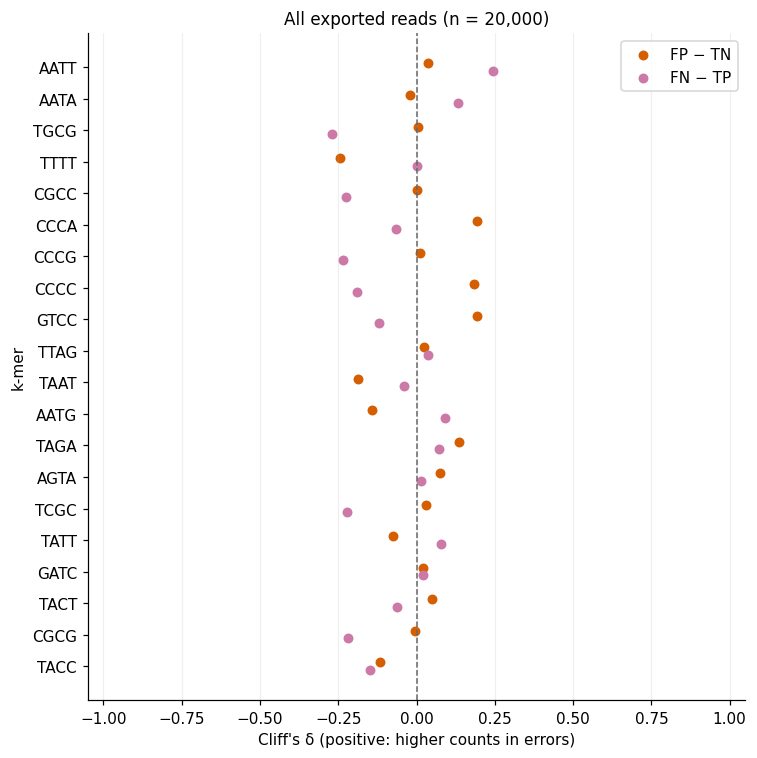

In [5]:
def distribution_grid(values, metadata, feature_names, ylabel, title, output_name, zero_line=False):
    rows = int(np.ceil(len(feature_names) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(13, 2.5 * rows), squeeze=False)
    for ax, feature in zip(axes.flat, feature_names):
        present = [g for g in GROUPS if metadata.outcome.eq(g).any()]
        arrays = [values.loc[metadata.index[metadata.outcome.eq(g)], feature].to_numpy() for g in present]
        positions = [GROUPS.index(g) + 1 for g in present]
        if arrays:
            bp = ax.boxplot(arrays, positions=positions, widths=.6, patch_artist=True, showfliers=True,
                            flierprops={"markersize": 1.5, "alpha": .25}, medianprops={"color": "black"})
            for patch, group in zip(bp["boxes"], present):
                patch.set_facecolor(COLORS[group]); patch.set_alpha(.65)
        ax.set(xticks=np.arange(1, 5), xticklabels=GROUPS, xlim=(.4, 4.6), title=feature, ylabel=ylabel)
        ax.tick_params(labelsize=8)
        ax.grid(axis="y", alpha=.18)
        if zero_line:
            ax.axhline(0, color="0.4", linewidth=.7, linestyle="--")
    for ax in list(axes.flat)[len(feature_names):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.005, fontsize=13)
    fig.tight_layout()
    show_figure(fig, output_name)

distribution_grid(features, feature_meta, top_features, "Occurrences per read",
                  f"Top-{len(top_features)} global SHAP k-mers — {feature_scope}", "02_feature_distributions")

feature_rows, effect_rows = [], []
for feature in top_features:
    for group in GROUPS:
        a = features.loc[feature_meta.index[feature_meta.outcome.eq(group)], feature]
        feature_rows.append({"k_mer": feature, "outcome": group, "n": len(a),
                             "mean": a.mean(), "median": a.median(), "q25": a.quantile(.25),
                             "q75": a.quantile(.75), "presence_rate": a.gt(0).mean() if len(a) else np.nan})
    for error, correct in [("FP", "TN"), ("FN", "TP")]:
        a = features.loc[feature_meta.index[feature_meta.outcome.eq(error)], feature]
        b = features.loc[feature_meta.index[feature_meta.outcome.eq(correct)], feature]
        delta = 2 * mannwhitneyu(a, b, method="asymptotic").statistic / (len(a) * len(b)) - 1 if len(a) and len(b) else np.nan
        effect_rows.append({"k_mer": feature, "contrast": f"{error} − {correct}",
                            "n_error": len(a), "n_correct": len(b), "cliffs_delta": delta})
table(pd.DataFrame(feature_rows), "02_feature_descriptive_statistics", rows=12)
feature_effects = pd.DataFrame(effect_rows)
table(feature_effects, "02_feature_effect_sizes", rows=12)

fig, ax = plt.subplots(figsize=(7, 7))
for offset, contrast, color in [(-.12, "FP − TN", COLORS["FP"]), (.12, "FN − TP", COLORS["FN"])]:
    vals = feature_effects.loc[feature_effects.contrast.eq(contrast)].set_index("k_mer").reindex(top_features)
    ax.scatter(vals.cliffs_delta, np.arange(len(top_features)) + offset, label=contrast, color=color, s=30)
ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
ax.set(yticks=np.arange(len(top_features)), yticklabels=top_features, xlim=(-1.05, 1.05),
       xlabel="Cliff's δ (positive: higher counts in errors)", ylabel="k-mer", title=feature_scope)
ax.invert_yaxis(); ax.legend(); ax.grid(axis="x", alpha=.2)
fig.tight_layout()
show_figure(fig, "02_feature_effect_sizes")


,Selected reads
outcome,
TN,2908
FP,614
TP,7765
FN,47


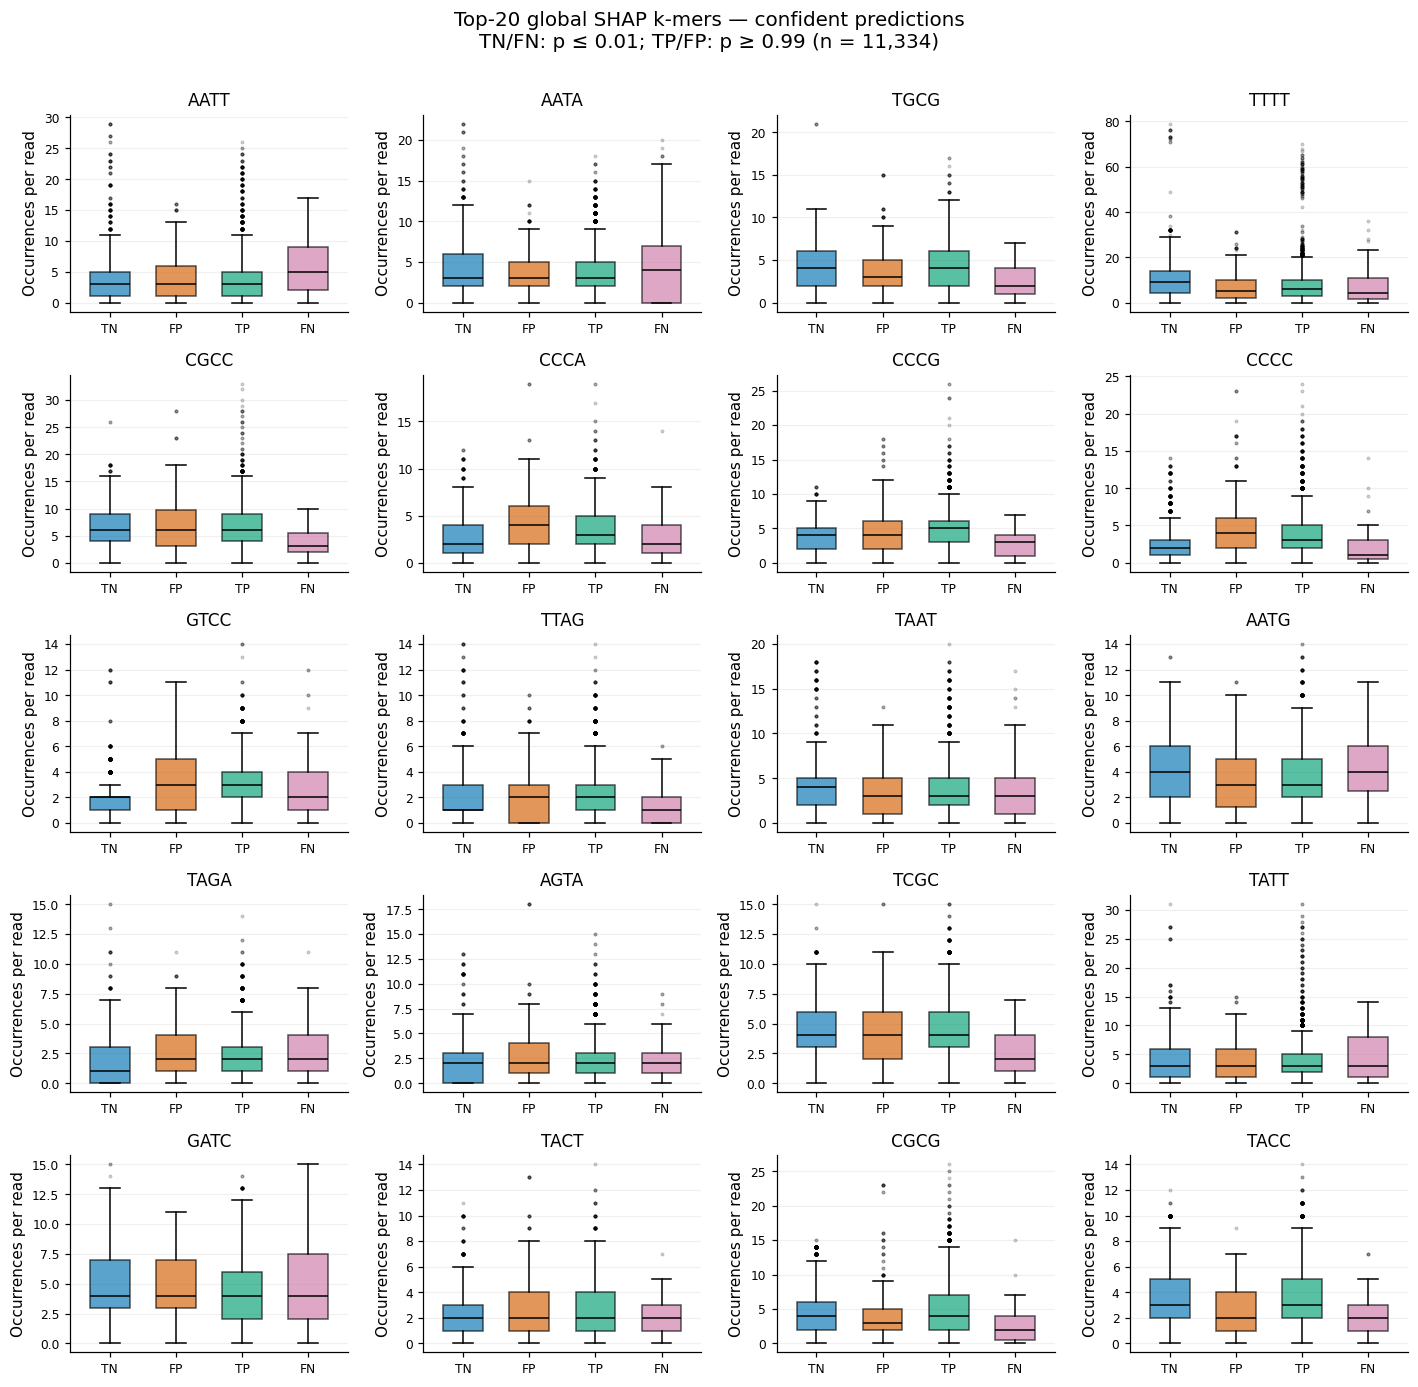

In [10]:
LOW_PROB, HIGH_PROB = 0.01, 0.99

p = feature_meta["probability_infected"]
outcome = feature_meta["outcome"]

keep = (
    (outcome.isin(["TN", "FN"]) & p.le(LOW_PROB))
    | (outcome.isin(["TP", "FP"]) & p.ge(HIGH_PROB))
)

confident_meta = feature_meta.loc[keep].copy()
confident_features = features.loc[confident_meta.index]

display(
    confident_meta["outcome"]
    .value_counts()
    .reindex(GROUPS, fill_value=0)
    .rename("Selected reads")
    .to_frame()
)

if not confident_meta.empty:
    distribution_grid(
        confident_features,
        confident_meta,
        top_features,
        "Occurrences per read",
        (
            f"Top-{len(top_features)} global SHAP k-mers — confident predictions\n"
            f"TN/FN: p ≤ {LOW_PROB}; TP/FP: p ≥ {HIGH_PROB} "
            f"(n = {len(confident_meta):,})"
        ),
        "02_feature_distributions_confident",
    )
else:
    print("No reads meet the probability thresholds.")
    

In [8]:
confident_meta

,read_id,outer_fold,true_label,predicted_label,outcome,probability_infected,decision_score,...,kmer__GGAG,kmer__TCCG,kmer__ACGA,kmer__TCGG,kmer__TAAC,margin_percentile_within_fold,probability_of_predicted_class
read_id,,,,,,,,,,,,,,,
0,0,2,0,0,TN,0.000106,-2.339315,...,2,4,3,2,3,0.892375,0.999894
1,1,4,0,0,TN,0.051543,-0.939157,...,6,1,3,3,4,0.305125,0.948457
3,3,3,0,0,TN,0.032003,-1.037709,...,4,9,5,2,5,0.347500,0.967997
4,4,4,0,0,TN,0.016721,-1.191571,...,3,3,2,6,4,0.487750,0.983279
5,5,3,0,0,TN,0.012481,-1.245760,...,1,0,3,0,1,0.530125,0.987519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,19994,3,1,1,TP,1.000000,1.686109,...,4,4,4,2,5,0.741000,1.000000
19995,19995,4,1,1,TP,1.000000,1.461485,...,6,1,6,4,8,0.635500,1.000000
19997,19997,4,1,1,TP,1.000000,1.469794,...,3,2,2,6,3,0.638750,1.000000


outcome,TN,FP,TP,FN
outer_fold,,,,
0,398,21,379,2
1,392,34,366,8
2,396,11,389,4
3,382,4,396,18
4,394,17,383,6


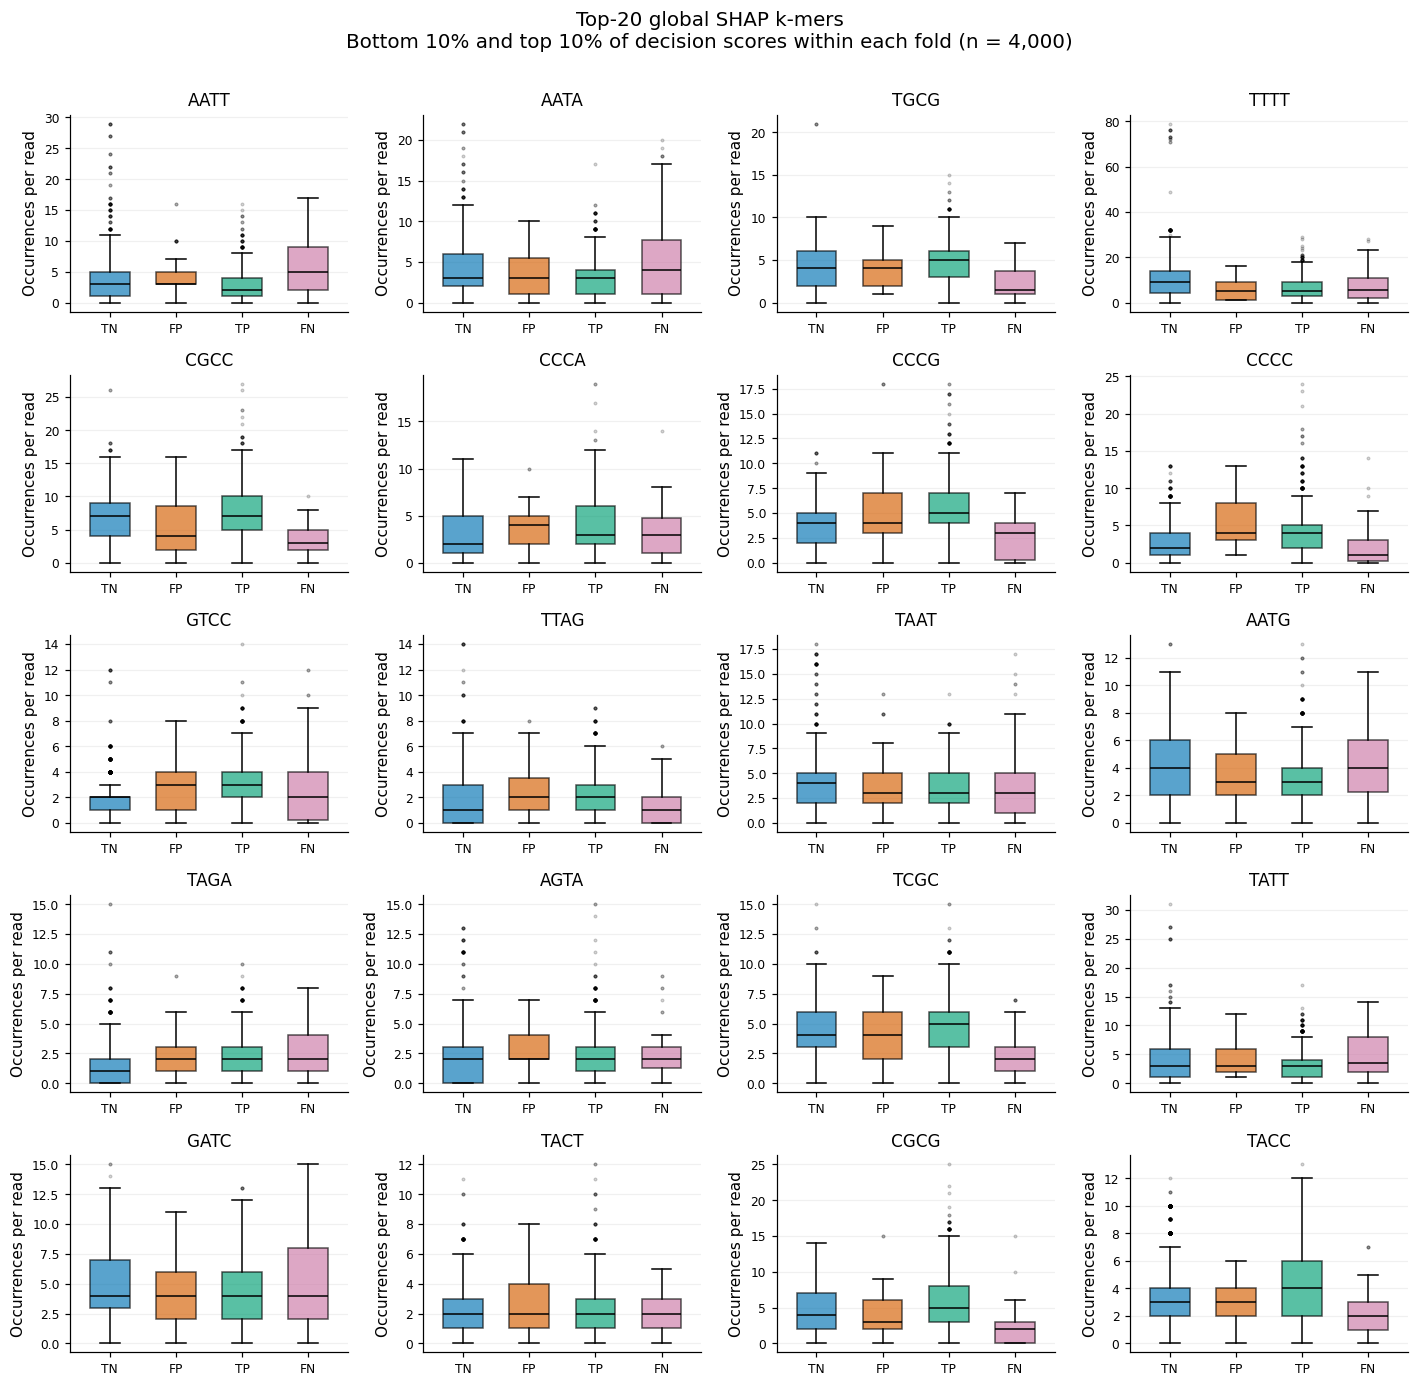

In [11]:
selected_ids = []

for fold, fold_reads in pred.groupby("outer_fold"):
    # Break score ties deterministically using read_id.
    ranked = fold_reads.reset_index(drop=True).sort_values(
        ["decision_score", "read_id"]
    )
    n_each_tail = len(ranked) // 10

    if n_each_tail:
        selected_ids.extend(ranked.head(n_each_tail)["read_id"])
        selected_ids.extend(ranked.tail(n_each_tail)["read_id"])

extreme_meta = feature_meta.loc[
    feature_meta.index.isin(selected_ids)
].copy()
extreme_features = features.loc[extreme_meta.index]

display(
    extreme_meta.groupby(["outer_fold", "outcome"])
    .size()
    .unstack("outcome", fill_value=0)
    .reindex(columns=GROUPS, fill_value=0)
)

if not extreme_meta.empty:
    distribution_grid(
        extreme_features,
        extreme_meta,
        top_features,
        "Occurrences per read",
        (
            f"Top-{len(top_features)} global SHAP k-mers\n"
            f"Bottom 10% and top 10% of decision scores within each fold "
            f"(n = {len(extreme_meta):,})"
        ),
        "02_feature_distributions_decision_extremes_per_fold",
    )
else:
    print("No reads available for the selected extremes.")

,Read totali,Sequenze distinte,Read singoli,Sequenze ripetute,Read in duplicati,Copie aggiuntive,% read in duplicati,Massimo copie
Gruppo,,,,,,,,
Puliti,10000,2860,592,2268,9408,7140,94.08,110
Infetti,10000,9943,9888,55,112,57,1.12,3
TN,8842,2489,510,1979,8332,6353,94.23,110
FP,1158,371,82,289,1076,787,92.92,48
TP,9336,9280,9226,54,110,56,1.18,3
FN,664,663,662,1,2,1,0.30,2


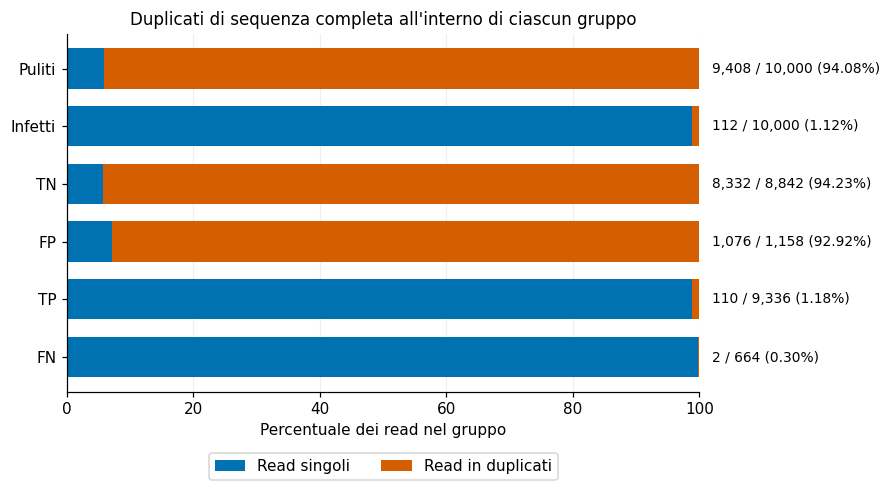

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

assert {"sequence", "true_label", "outcome", "read_id"}.issubset(pred.columns)
assert pred["sequence"].notna().all(), "Sono presenti sequenze mancanti."
assert pred["sequence"].ne("").all(), "Sono presenti sequenze vuote."

gruppi = {
    "Puliti": pred.loc[pred["true_label"].eq(0)],
    "Infetti": pred.loc[pred["true_label"].eq(1)],
    **{
        gruppo: pred.loc[pred["outcome"].eq(gruppo)]
        for gruppo in ["TN", "FP", "TP", "FN"]
    },
}

riepilogo = []
dettagli = []

for nome, dati in gruppi.items():
    frequenze = dati["sequence"].value_counts()
    ripetute = frequenze.loc[frequenze.gt(1)]

    totale = len(dati)
    read_duplicati = int(ripetute.sum())

    riepilogo.append({
        "Gruppo": nome,
        "Read totali": totale,
        "Sequenze distinte": len(frequenze),
        "Read singoli": int(frequenze.eq(1).sum()),
        "Sequenze ripetute": len(ripetute),
        "Read in duplicati": read_duplicati,
        "Copie aggiuntive": totale - len(frequenze),
        "% read in duplicati": (
            100 * read_duplicati / totale if totale else float("nan")
        ),
        "Massimo copie": int(frequenze.max()) if totale else 0,
    })

    # Una riga per sequenza ripetuta, con gli ID di tutte le copie.
    ids_per_sequenza = (
        dati.loc[dati["sequence"].isin(ripetute.index)]
        .groupby("sequence")["read_id"]
        .agg(list)
    )

    for sequenza, numero_copie in ripetute.items():
        dettagli.append({
            "Gruppo": nome,
            "Numero copie": int(numero_copie),
            "read_ids": ids_per_sequenza.loc[sequenza],
            "sequence": sequenza,
        })

duplicate_summary = pd.DataFrame(riepilogo).set_index("Gruppo")

duplicate_details = pd.DataFrame(
    dettagli,
    columns=["Gruppo", "Numero copie", "read_ids", "sequence"],
).sort_values(
    ["Gruppo", "Numero copie"],
    ascending=[True, False],
    ignore_index=True,
)

display(duplicate_summary.round(2))

# Grafico: percentuali calcolate all'interno di ciascun gruppo.
percentuali = (
    duplicate_summary[["Read singoli", "Read in duplicati"]]
    .div(duplicate_summary["Read totali"].replace(0, float("nan")), axis=0)
    .mul(100)
)

ax = percentuali.plot.barh(
    stacked=True,
    figsize=(10, 5),
    color=["#0072B2", "#D55E00"],
    width=0.7,
)

for posizione, (_, riga) in enumerate(duplicate_summary.iterrows()):
    percentuale = riga["% read in duplicati"]
    if pd.notna(percentuale):
        ax.text(
            102, posizione,
            f'{int(riga["Read in duplicati"]):,} / '
            f'{int(riga["Read totali"]):,} ({percentuale:.2f}%)',
            va="center",
            fontsize=9,
        )

ax.set(
    xlim=(0, 100),
    xlabel="Percentuale dei read nel gruppo",
    ylabel="",
    title="Duplicati di sequenza completa all'interno di ciascun gruppo",
)
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.gcf().subplots_adjust(right=0.70, bottom=0.23)
plt.show()

In [14]:


feature_cols = [c for c in pred.columns if c.startswith("kmer__")]
assert feature_cols, "Mancano le colonne dei conteggi kmer__... nell'export."

required = ["read_id", "sequence", "true_label", "outcome", "outer_fold"]
df = pred[required + feature_cols].reset_index(drop=True).copy()

assert df["read_id"].is_unique
assert df[required + feature_cols].notna().all().all()
assert np.isfinite(df[feature_cols].to_numpy()).all()

# Controllo prima di conservare una sola copia per sequenza.
coerenza = df.groupby("sequence")[["true_label", "outcome"]].nunique()
incoerenti = coerenza.loc[coerenza.gt(1).any(axis=1)]

if not incoerenti.empty:
    display(df.loc[df["sequence"].isin(incoerenti.index), required])
    raise ValueError(
        "Alcune sequenze identiche hanno etichette o esiti diversi. "
        "Esaminarle prima di deduplicare."
    )

df_unique = df.drop_duplicates("sequence").copy()
confronti = [("FP", "TN"), ("FN", "TP")]


def confronta_kmer(dati, errore, corretto):
    a = dati.loc[dati["outcome"].eq(errore), feature_cols]
    b = dati.loc[dati["outcome"].eq(corretto), feature_cols]

    risultato = pd.DataFrame({
        "kmer": [c.removeprefix("kmer__") for c in feature_cols],
        "n_errore": len(a),
        "n_corretto": len(b),
        "presenza_errore_pct": (100 * a.gt(0).mean()).to_numpy(),
        "presenza_corretto_pct": (100 * b.gt(0).mean()).to_numpy(),
        "media_errore": a.mean().to_numpy(),
        "media_corretto": b.mean().to_numpy(),
        "mediana_errore": a.median().to_numpy(),
        "mediana_corretto": b.median().to_numpy(),
    })

    risultato["diff_presenza_pp"] = (
        risultato["presenza_errore_pct"]
        - risultato["presenza_corretto_pct"]
    )
    risultato["diff_media"] = (
        risultato["media_errore"] - risultato["media_corretto"]
    )
    risultato["diff_mediana"] = (
        risultato["mediana_errore"] - risultato["mediana_corretto"]
    )
    return risultato


tabelle = []

for versione, dati in [
    ("Tutti i read", df),
    ("Sequenze distinte", df_unique),
]:
    for errore, corretto in confronti:
        tabella = confronta_kmer(dati, errore, corretto)
        tabella["confronto"] = f"{errore}-{corretto}"
        tabella["versione"] = versione
        tabelle.append(tabella)

# Tabella completa: tutti i k-mer, entrambi i confronti e le versioni.
kmer_summary = pd.concat(tabelle, ignore_index=True)

# Confronto affiancato per valutare l'effetto della deduplicazione.
kmer_comparison = kmer_summary.pivot(
    index=["confronto", "kmer"],
    columns="versione",
    values=["diff_presenza_pp", "diff_media", "diff_mediana"],
)

# Ordine principale: differenza media assoluta sulle sequenze distinte.
ranking_kmer = {}

for errore, corretto in confronti:
    confronto = f"{errore}-{corretto}"
    tabella = kmer_comparison.xs(confronto, level="confronto")

    ordine = (
        tabella[("diff_media", "Sequenze distinte")]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    ranking_kmer[confronto] = ordine.tolist()

    print(f"\n{confronto}: primi 20 k-mer per differenza media assoluta")
    display(tabella.reindex(ordine).head(20).round(3))


FP-TN: primi 20 k-mer per differenza media assoluta


diff_presenza_pp                     diff_media               \
versione Sequenze distinte Tutti i read Sequenze distinte Tutti i read   
kmer                                                                     
TTTT                -2.910       -5.458            -2.815       -3.313   
TTAA                -4.573       -7.984            -1.268       -1.339   
CCTC                 4.843        5.247             1.075        1.090   
ATTT                -3.546       -3.417            -1.054       -1.195   
TCGA                 7.528        9.819             1.010        1.110   
CCCC                -1.392       -4.584             0.974        0.993   
TTTA                -3.367       -9.247            -0.932       -1.210   
GTAC                12.184       14.863             0.910        1.122   
TAAA                -2.929       -2.585            -0.855       -0.832   
GAGG                 3.843        3.202             0.837        0.756   
TAAT                -6.980      -11.742            -0.802       -0.921   
GGAC                 2.212        1.804             0.727        0.605   
CTCG                 0.868        1.712             0.724        0.873   
CTTG                 6.819        6.725             0.707        0.900   
CGTC                 2.790        3.657             0.705        0.869   
TATT                -1.479       -1.186            -0.685       -0.795   
GGGG                 1.461       -4.081             0.684        0.263   
GGCG                 1.272       -1.638             0.680        0.668   
AATA                -4.571       -3.327            -0.636       -0.456   
GTCC                 2.477        0.825             0.635        0.826   

              diff_mediana               
versione Sequenze distinte Tutti i read  
kmer                                     
TTTT                  -2.0         -2.0  
TTAA                   0.0          0.0  
CCTC                   1.0          1.0  
ATTT                   0.0          0.0  
TCGA                   1.0          1.0  
CCCC                   1.0          1.0  
TTTA                   0.0         -1.0  
GTAC                   1.0          1.0  
TAAA                   0.0          0.0  
GAGG                   1.0          1.0  
TAAT                  -1.0         -1.0  
GGAC                   1.0          0.0  
CTCG                   0.0          0.0  
CTTG                   0.0          0.0  
CGTC                   1.0          1.0  
TATT                   0.0          0.0  
GGGG                   1.0          1.0  
GGCG                   0.0          0.0  
AATA                   0.0          0.0  
GTCC                   0.0          0.0


FN-TP: primi 20 k-mer per differenza media assoluta


diff_presenza_pp                     diff_media               \
versione Sequenze distinte Tutti i read Sequenze distinte Tutti i read   
kmer                                                                     
CCGC                -4.599       -4.610            -1.582       -1.589   
AATT                 3.073        3.117             1.531        1.532   
CGCC                -3.878       -3.880            -1.430       -1.439   
GCGC                -2.757       -2.762            -1.418       -1.415   
CAAA                 3.612        3.736             1.393        1.401   
CGCG                -5.816       -5.807            -1.288       -1.288   
TAAA                -0.957       -0.874             1.219        1.227   
TGCG                -3.307       -3.321            -1.093       -1.095   
CCCG                -7.034       -7.023            -1.045       -1.049   
AAGT                 6.304        6.329             0.992        0.996   
AATA                -1.646       -1.630             0.979        0.978   
ATAT                 0.649        0.644             0.967        0.966   
ATTT                -1.399       -1.421             0.933        0.933   
CGGG                -6.194       -6.208            -0.921       -0.926   
TCGC                -6.398       -6.379            -0.904       -0.903   
ATTA                -3.790       -3.790             0.837        0.841   
GAAT                 4.010        3.988             0.704        0.708   
TTAA                -3.145       -3.132             0.605        0.604   
TACC                -4.157       -4.144            -0.597       -0.598   
TATA                -3.251       -3.196             0.592        0.593   

              diff_mediana               
versione Sequenze distinte Tutti i read  
kmer                                     
CCGC                  -2.0         -2.0  
AATT                   1.0          1.0  
CGCC                  -2.0         -2.0  
GCGC                  -2.0         -2.0  
CAAA                   1.0          1.0  
CGCG                  -1.0         -1.0  
TAAA                   1.0          1.0  
TGCG                  -1.0         -1.0  
CCCG                  -1.0         -1.0  
AAGT                   1.0          1.0  
AATA                   1.0          1.0  
ATAT                   1.0          1.0  
ATTT                   1.0          1.0  
CGGG                  -1.0         -1.0  
TCGC                  -1.0         -1.0  
ATTA                   1.0          1.0  
GAAT                   0.0          0.0  
TTAA                   0.0          0.0  
TACC                   0.0          0.0  
TATA                   0.0          0.0

In [17]:
# Sostituisci "AAAA" con il k-mer da esaminare.
display(kmer_summary.loc[kmer_summary["kmer"].eq("TTTT")].round(3))

,kmer,n_errore,n_corretto,presenza_errore_pct,presenza_corretto_pct,media_errore,media_corretto,mediana_errore,mediana_corretto,diff_presenza_pp,diff_media,diff_mediana,confronto,versione
77,TTTT,1158,8842,91.364,96.822,6.849,10.162,6.0,8.0,-5.458,-3.313,-2.0,FP-TN,Tutti i read
177,TTTT,664,9336,93.825,95.030,8.199,8.107,6.0,6.0,-1.205,0.092,0.0,FN-TP,Tutti i read
277,TTTT,371,2489,92.992,95.902,6.879,9.694,6.0,8.0,-2.910,-2.815,-2.0,FP-TN,Sequenze distinte
377,TTTT,663,9280,93.816,95.032,8.207,8.112,6.0,6.0,-1.216,0.094,0.0,FN-TP,Sequenze distinte


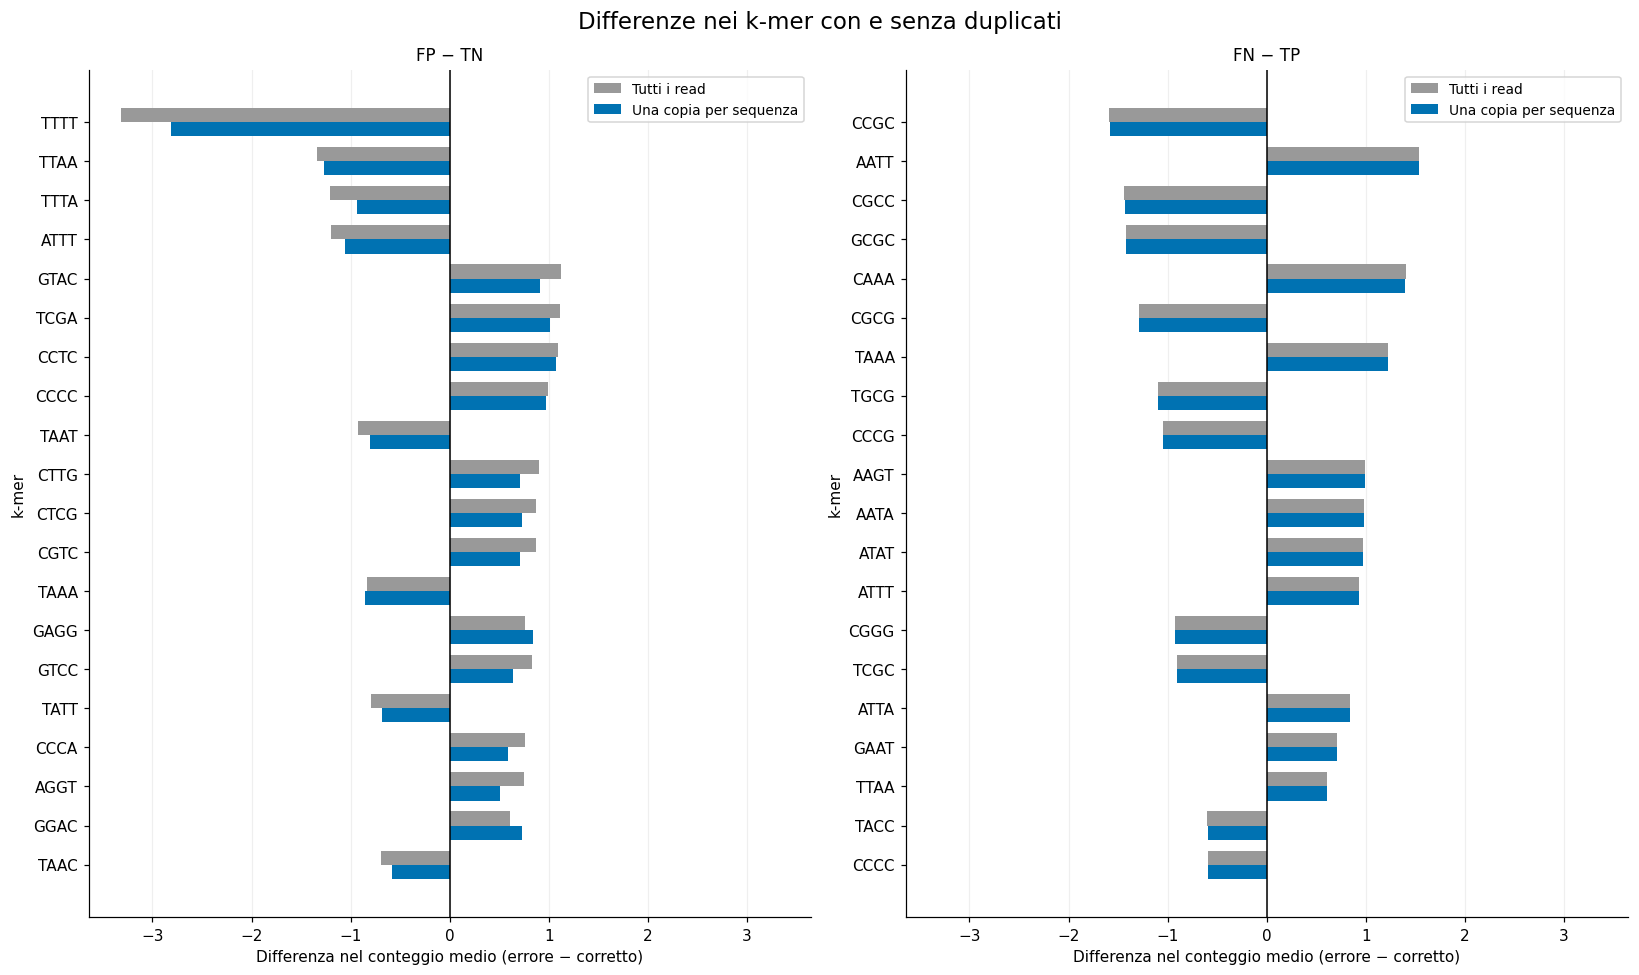


FP-TN


versione,Tutti i read,Sequenze distinte
kmer,,
TTTT,-3.313,-2.815
TTAA,-1.339,-1.268
TTTA,-1.210,-0.932
ATTT,-1.195,-1.054
GTAC,1.122,0.910
TCGA,1.110,1.010
CCTC,1.090,1.075
CCCC,0.993,0.974
TAAT,-0.921,-0.802



FN-TP


versione,Tutti i read,Sequenze distinte
kmer,,
CCGC,-1.589,-1.582
AATT,1.532,1.531
CGCC,-1.439,-1.430
GCGC,-1.415,-1.418
CAAA,1.401,1.393
CGCG,-1.288,-1.288
TAAA,1.227,1.219
TGCG,-1.095,-1.093
CCCG,-1.049,-1.045


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

TOP_N = 20

# Alternative: "diff_presenza_pp" oppure "diff_mediana".
METRICA = "diff_media"

etichette = {
    "diff_media": "Differenza nel conteggio medio (errore − corretto)",
    "diff_presenza_pp": (
        "Differenza di presenza (punti percentuali; errore − corretto)"
    ),
    "diff_mediana": "Differenza nel conteggio mediano (errore − corretto)",
}

versioni = ["Tutti i read", "Sequenze distinte"]
confronti_plot = ["FP-TN", "FN-TP"]

# Stessa scala sull'asse x per entrambi i pannelli.
fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharex=True)
dati_grafico = {}

for ax, confronto in zip(axes, confronti_plot):
    tabella = (
        kmer_comparison
        .xs(confronto, level="confronto")[METRICA]
        .reindex(columns=versioni)
        .dropna()
    )

    # Seleziona le differenze maggiori in almeno una delle due versioni.
    ordine = (
        tabella.abs()
        .max(axis=1)
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    selezionati = tabella.reindex(ordine)
    dati_grafico[confronto] = selezionati.copy()

    y = np.arange(len(selezionati))
    altezza = 0.36

    ax.barh(
        y - altezza / 2,
        selezionati["Tutti i read"],
        height=altezza,
        color="#999999",
        label="Tutti i read",
    )
    ax.barh(
        y + altezza / 2,
        selezionati["Sequenze distinte"],
        height=altezza,
        color="#0072B2",
        label="Una copia per sequenza",
    )

    ax.axvline(0, color="black", linewidth=1)
    ax.set(
        yticks=y,
        yticklabels=selezionati.index,
        xlabel=etichette[METRICA],
        ylabel="k-mer",
        title=confronto.replace("-", " − "),
    )
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9)

# Limiti comuni e simmetrici rispetto allo zero.
massimi = [
    tabella.abs().to_numpy().max()
    for tabella in dati_grafico.values()
    if not tabella.empty
]
massimo = max(massimi, default=0)
limite = massimo * 1.1 if massimo > 0 else 1

axes[0].set_xlim(-limite, limite)

fig.suptitle(
    "Differenze nei k-mer con e senza duplicati",
    fontsize=15,
)
fig.tight_layout()
plt.show()

# Valori numerici rappresentati nei grafici.
for confronto, tabella in dati_grafico.items():
    print(f"\n{confronto}")
    display(tabella.round(3))

In [26]:


SOLO_SEQUENZE_DISTINTE = True

GRUPPI = ["TN", "FP", "TP", "FN"]
COLORI = {
    "TN": "#0072B2",
    "FP": "#D55E00",
    "TP": "#009E73",
    "FN": "#CC79A7",
}

# ------------------------------------------------------------
# 1. Preparazione dei vettori
# ------------------------------------------------------------
feature_cols = [c for c in pred.columns if c.startswith("kmer__")]
assert len(feature_cols) >= 3, "Servono almeno tre feature."

dati = pred[
    ["read_id", "sequence", "true_label", "outcome"] + feature_cols
].reset_index(drop=True).copy()

assert dati.notna().all().all(), "Sono presenti valori mancanti."
assert dati["outcome"].isin(GRUPPI).all()

if SOLO_SEQUENZE_DISTINTE:
    coerenza = (
        dati.groupby("sequence")[["true_label", "outcome"]]
        .nunique()
    )
    if coerenza.gt(1).any().any():
        raise ValueError(
            "Sequenze identiche hanno etichette o esiti diversi: "
            "esaminarle prima di deduplicare."
        )

    dati = dati.drop_duplicates("sequence").reset_index(drop=True)

X = dati[feature_cols].to_numpy(dtype=float)

assert np.isfinite(X).all(), "Conteggi non finiti."
assert len(X) >= 3
assert np.var(X, axis=0).sum() > 0, "Tutti i vettori sono identici."

numerosita = (
    dati["outcome"].value_counts()
    .reindex(GRUPPI, fill_value=0)
)
assert numerosita.gt(0).all(), "Uno dei quattro gruppi è vuoto."

# ------------------------------------------------------------
# 2. Centroidi nello spazio originale
# ------------------------------------------------------------
centroidi_originali = (
    dati.groupby("outcome")[feature_cols]
    .mean()
    .reindex(GRUPPI)
)

# ------------------------------------------------------------
# 3. PCA su tutti i vettori selezionati
# ------------------------------------------------------------
# PCA centra automaticamente le feature.
# Manteniamo i conteggi originali, senza standardizzazione.
pca = PCA(n_components=3, svd_solver="full")

coordinate = pca.fit_transform(X)

coordinate_centroidi = pca.transform(
    centroidi_originali.to_numpy()
)

coordinate_reads = pd.DataFrame(
    coordinate,
    columns=["PC1", "PC2", "PC3"],
)
coordinate_reads["read_id"] = dati["read_id"].to_numpy()
coordinate_reads["outcome"] = dati["outcome"].to_numpy()

centroidi_pca = pd.DataFrame(
    coordinate_centroidi,
    index=GRUPPI,
    columns=["PC1", "PC2", "PC3"],
)
centroidi_pca.index.name = "outcome"
centroidi_pca["n"] = numerosita

# Per una trasformazione PCA, la proiezione del centroide
# coincide con la media delle coordinate proiettate.
np.testing.assert_allclose(
    coordinate_reads.groupby("outcome")[["PC1", "PC2", "PC3"]]
    .mean()
    .reindex(GRUPPI)
    .to_numpy(),
    coordinate_centroidi,
    atol=1e-8,
    rtol=1e-8,
)

varianza_pct = 100 * pca.explained_variance_ratio_

print(
    f"Analisi su {len(dati):,} read e {len(feature_cols)} feature."
)
print(
    "Una copia per sequenza."
    if SOLO_SEQUENZE_DISTINTE
    else "Tutti i read, comprese le copie."
)

display(pd.DataFrame({
    "Componente": ["PC1", "PC2", "PC3"],
    "Varianza spiegata (%)": varianza_pct,
    "Varianza cumulativa (%)": np.cumsum(varianza_pct),
}).round(2))

print("Centroidi proiettati:")
display(centroidi_pca.round(3))

# ------------------------------------------------------------
# 4. Grafico tridimensionale
# ------------------------------------------------------------
fig_pca = go.Figure()

# Read: punti semitrasparenti, separati per gruppo.
for gruppo in GRUPPI:
    punti = coordinate_reads.loc[
        coordinate_reads["outcome"].eq(gruppo)
    ]

    fig_pca.add_trace(go.Scatter3d(
        x=punti["PC1"],
        y=punti["PC2"],
        z=punti["PC3"],
        mode="markers",
        name=f"{gruppo} (n = {numerosita[gruppo]:,})",
        legendgroup=gruppo,
        marker=dict(
            size=2,
            color=COLORI[gruppo],
            opacity=0.20,
        ),
        customdata=punti["read_id"].to_numpy(),
        hovertemplate=(
            f"<b>{gruppo}</b><br>"
            "Read ID: %{customdata}<br>"
            "PC1: %{x:.3f}<br>"
            "PC2: %{y:.3f}<br>"
            "PC3: %{z:.3f}"
            "<extra></extra>"
        ),
    ))

    # Centroide associato allo stesso gruppo della legenda.
    centro = centroidi_pca.loc[gruppo]

    fig_pca.add_trace(go.Scatter3d(
        x=[centro["PC1"]],
        y=[centro["PC2"]],
        z=[centro["PC3"]],
        mode="markers+text",
        text=[gruppo],
        textposition="top center",
        textfont=dict(size=15, color=COLORI[gruppo]),
        name=f"Centroide {gruppo}",
        legendgroup=gruppo,
        showlegend=False,
        marker=dict(
            size=10,
            symbol="diamond",
            color=COLORI[gruppo],
            opacity=1,
            line=dict(color="black", width=2),
        ),
        hovertemplate=(
            f"<b>Centroide {gruppo}</b><br>"
            "PC1: %{x:.3f}<br>"
            "PC2: %{y:.3f}<br>"
            "PC3: %{z:.3f}"
            "<extra></extra>"
        ),
    ))

scope = (
    "Sequenze distinte"
    if SOLO_SEQUENZE_DISTINTE
    else "Tutti i read"
)

fig_pca.update_layout(
    title=dict(
        text=(
            "PCA dei vettori di k-mer e centroidi"
            f"<br><sup>{scope} — varianza spiegata in 3D: "
            f"{varianza_pct.sum():.1f}%</sup>"
        ),
        x=0.5,
    ),
    scene=dict(
        xaxis_title=f"PC1 ({varianza_pct[0]:.1f}%)",
        yaxis_title=f"PC2 ({varianza_pct[1]:.1f}%)",
        zaxis_title=f"PC3 ({varianza_pct[2]:.1f}%)",
        aspectmode="data",
        dragmode="orbit",
    ),
    legend=dict(
        title="Gruppi — rombi: centroidi",
        groupclick="togglegroup",
    ),
    template="plotly_white",
    height=800,
    margin=dict(l=0, r=0, b=0, t=90),
)

fig_pca.show(
    renderer="browser",
    config={
        "scrollZoom": True,
        "displaylogo": False,
    },
)

# ------------------------------------------------------------
# 5. Distanze tra centroidi nello spazio originale
# ------------------------------------------------------------
distanze_centroidi = pd.DataFrame(
    pairwise_distances(
        centroidi_originali.to_numpy(),
        metric="euclidean",
    ),
    index=GRUPPI,
    columns=GRUPPI,
)

print("Distanze euclidee tra centroidi nello spazio originale:")
display(distanze_centroidi.round(3))

Analisi su 12,803 read e 100 feature.
Una copia per sequenza.


,Componente,Varianza spiegata (%),Varianza cumulativa (%)
0,PC1,31.72,31.72
1,PC2,7.50,39.22
2,PC3,4.94,44.16


Centroidi proiettati:


,PC1,PC2,PC3,n
outcome,,,,
TN,2.396,-0.041,-0.400,2489
FP,-1.282,-1.634,-0.887,371
TP,-0.822,0.260,0.237,9280
FN,3.229,-2.574,-1.324,663


Distanze euclidee tra centroidi nello spazio originale:


,TN,FP,TP,FN
TN,0.000,5.476,4.143,3.719
FP,5.476,0.000,3.465,5.027
TP,4.143,3.465,0.000,5.671
FN,3.719,5.027,5.671,0.000


In [27]:
COLORI = {
    "TN": "#0057D9",  # Blu
    "FP": "#FF8C00",  # Arancione
    "TP": "#008A45",  # Verde
    "FN": "#C000C8",  # Magenta
}

fig_pca_legenda = go.Figure(fig_pca)

# Aggiorna i colori dei read e dei centroidi.
for traccia in fig_pca_legenda.data:
    gruppo = traccia.legendgroup

    if gruppo in COLORI:
        traccia.marker.color = COLORI[gruppo]
        traccia.showlegend = False

        if "text" in (traccia.mode or ""):
            traccia.textfont.color = COLORI[gruppo]

# Elementi dedicati alla legenda:
# grandi e opachi, senza cambiare la dimensione dei read.
for gruppo in GRUPPI:
    fig_pca_legenda.add_trace(go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode="markers",
        name=f"{gruppo} (n = {numerosita[gruppo]:,})",
        legendgroup=gruppo,
        showlegend=True,
        marker=dict(
            size=18,
            color=COLORI[gruppo],
            opacity=1,
            symbol="circle",
        ),
        hoverinfo="skip",
    ))

fig_pca_legenda.update_layout(
    legend=dict(
        title=dict(
            text="Gruppi — rombi: centroidi",
            font=dict(size=18),
        ),
        font=dict(size=20),
        itemsizing="trace",
        itemwidth=50,
        groupclick="togglegroup",
    ),
)

fig_pca_legenda.show(
    renderer="browser",
    config={
        "scrollZoom": True,
        "displaylogo": False,
    },
)

In [15]:
tabelle_fold = []

for fold, dati_fold in df.groupby("outer_fold"):
    dati_fold = dati_fold.drop_duplicates("sequence")

    for errore, corretto in confronti:
        tabella = confronta_kmer(dati_fold, errore, corretto)
        tabella["confronto"] = f"{errore}-{corretto}"
        tabella["outer_fold"] = fold
        tabelle_fold.append(tabella)

kmer_by_fold = pd.concat(tabelle_fold, ignore_index=True)

for errore, corretto in confronti:
    confronto = f"{errore}-{corretto}"

    tabella = (
        kmer_by_fold.loc[kmer_by_fold["confronto"].eq(confronto)]
        .pivot(index="kmer", columns="outer_fold", values="diff_media")
        .reindex(ranking_kmer[confronto])
    )

    print(f"\n{confronto}: differenza media per fold, sequenze distinte")
    display(tabella.head(20).round(3))


FP-TN: differenza media per fold, sequenze distinte


outer_fold,0,1,2,3,4
kmer,,,,,
TTTT,-3.086,-4.028,-2.817,-2.298,-1.894
TTAA,-1.928,-1.231,-1.018,-1.462,-0.575
CCTC,1.369,0.871,1.034,1.055,0.948
ATTT,-1.883,-1.247,-1.303,-0.623,-0.107
TCGA,0.790,1.413,1.054,0.876,0.963
CCCC,2.155,0.755,1.051,0.001,0.652
TTTA,-1.556,-1.181,-1.359,-0.698,0.201
GTAC,0.640,1.147,0.847,1.069,0.906
TAAA,-0.981,-1.401,-0.496,-0.694,-0.646



FN-TP: differenza media per fold, sequenze distinte


outer_fold,0,1,2,3,4
kmer,,,,,
CCGC,-1.821,-1.874,-1.008,-2.425,-0.789
AATT,1.567,1.145,1.348,2.331,1.378
CGCC,-1.469,-1.955,-0.732,-2.219,-0.775
GCGC,-1.428,-1.669,-1.552,-1.787,-0.641
CAAA,1.018,1.433,1.249,1.949,1.347
CGCG,-0.882,-1.900,-1.321,-1.676,-0.613
TAAA,1.191,1.506,1.085,1.713,0.587
TGCG,-1.008,-1.136,-1.291,-1.366,-0.685
CCCG,-1.101,-1.166,-0.483,-1.535,-0.953


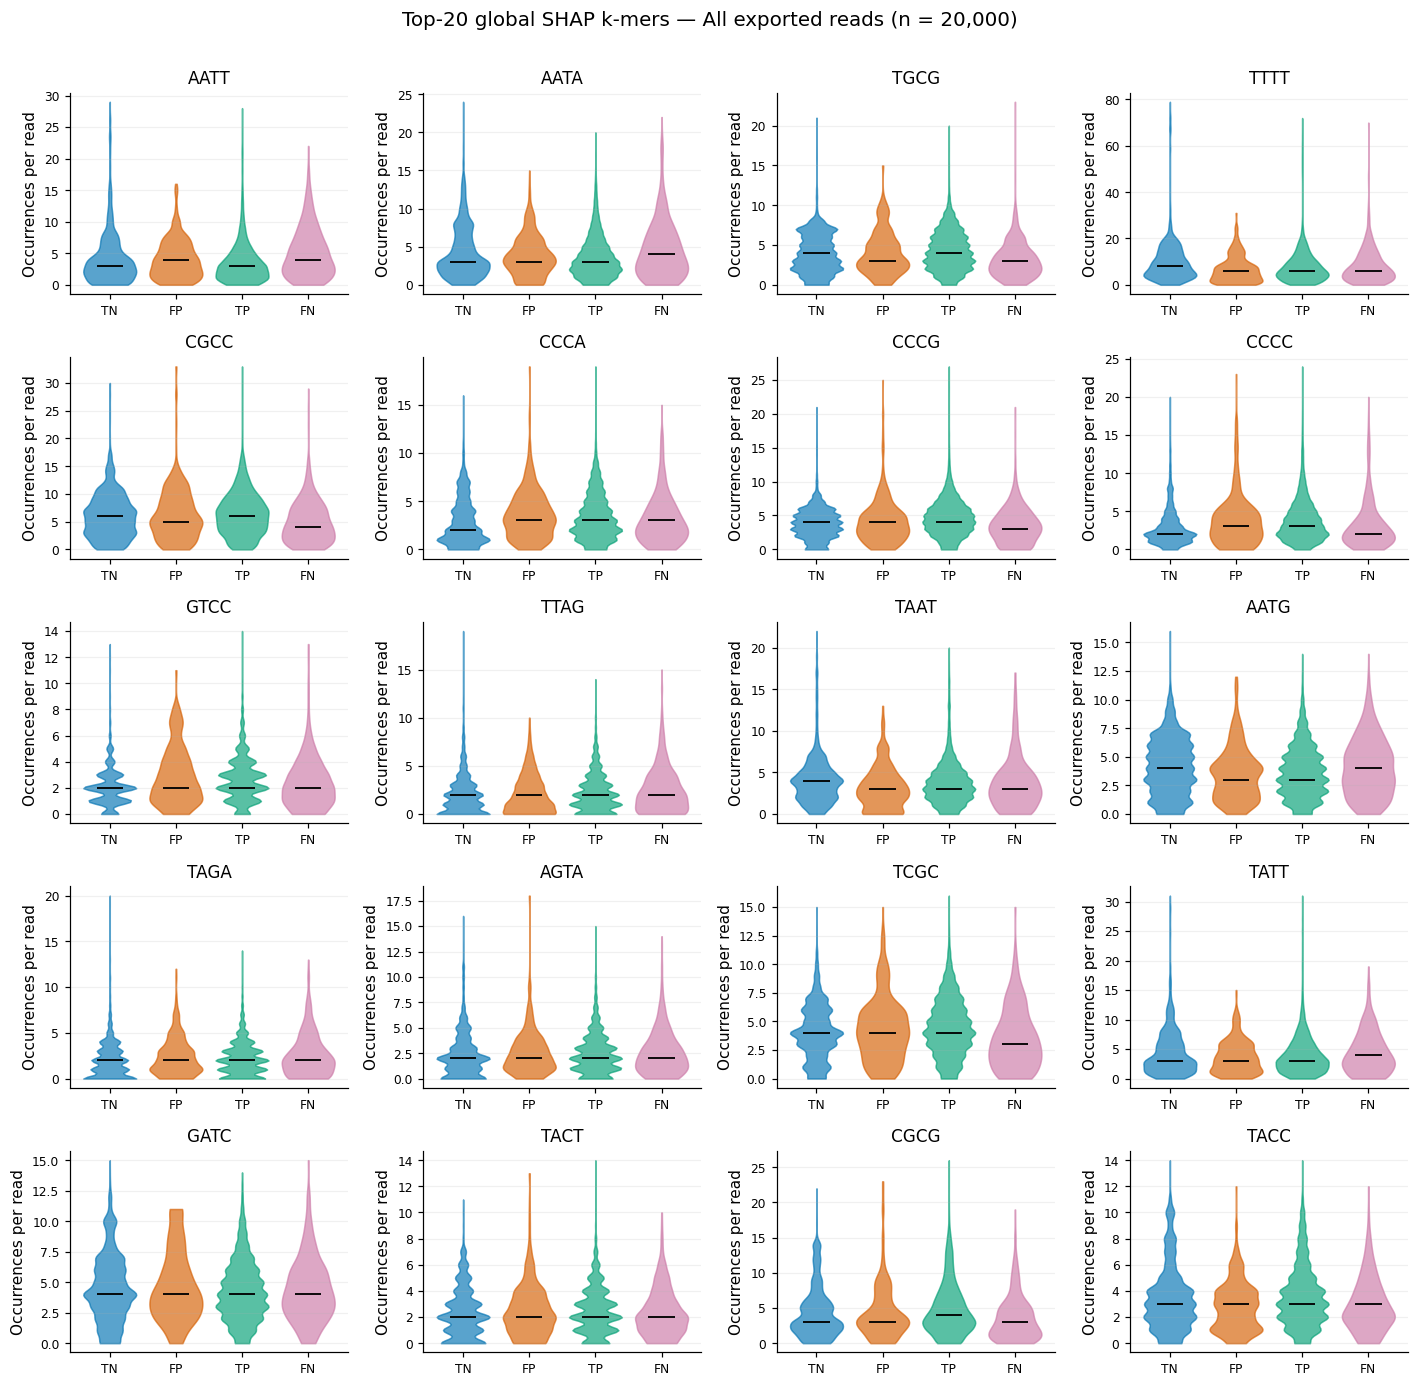

,k_mer,outcome,n,mean,median,q25,q75,presence_rate
0,AATT,TN,8842,4.3196,3.0,1.0,6.00,0.8763
1,AATT,FP,1158,4.0561,4.0,2.0,6.00,0.9059
2,AATT,TP,9336,3.6549,3.0,1.0,5.00,0.8935
3,AATT,FN,664,5.1867,4.0,2.0,8.00,0.9247
4,AATA,TN,8842,4.2566,3.0,2.0,6.00,0.9271
5,AATA,FP,1158,3.8005,3.0,2.0,5.00,0.8938
6,AATA,TP,9336,3.6201,3.0,2.0,5.00,0.9124
7,AATA,FN,664,4.5979,4.0,2.0,7.00,0.8961
8,TGCG,TN,8842,3.8905,4.0,2.0,6.00,0.9256
9,TGCG,FP,1158,4.0302,3.0,2.0,5.75,0.9404


,k_mer,contrast,n_error,n_correct,cliffs_delta
0,AATT,FP − TN,1158,8842,0.0360
1,AATT,FN − TP,664,9336,0.2442
2,AATA,FP − TN,1158,8842,-0.0213
3,AATA,FN − TP,664,9336,0.1320
4,TGCG,FP − TN,1158,8842,0.0047
5,TGCG,FN − TP,664,9336,-0.2690
6,TTTT,FP − TN,1158,8842,-0.2433
7,TTTT,FN − TP,664,9336,0.0012
8,CGCC,FP − TN,1158,8842,0.0011
9,CGCC,FN − TP,664,9336,-0.2244


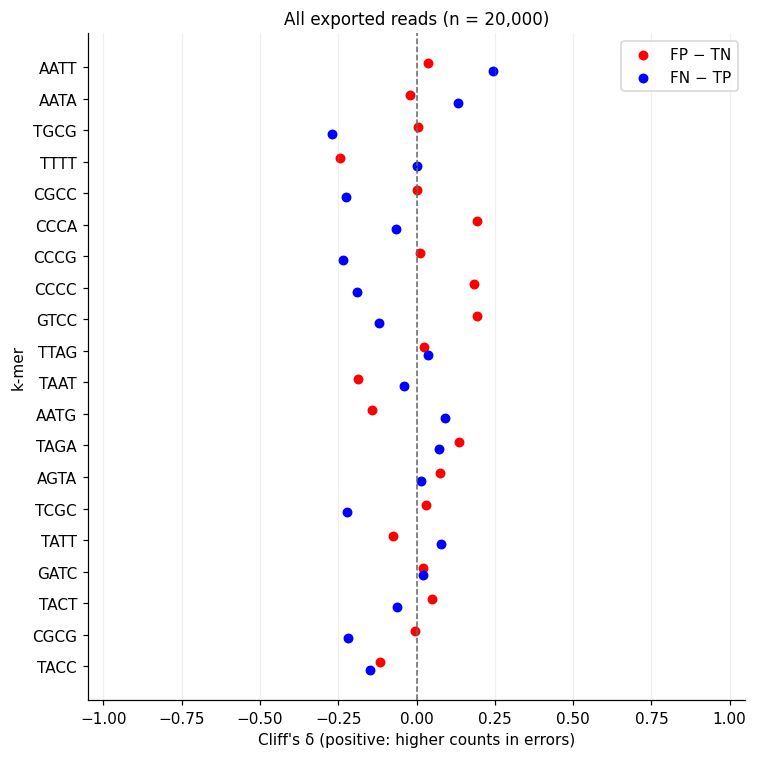

In [10]:
def distribution_grid(
    values, metadata, feature_names, ylabel, title, output_name, zero_line=False
):
    rows = int(np.ceil(len(feature_names) / 4))
    fig, axes = plt.subplots(
        rows, 4, figsize=(13, 2.5 * rows), squeeze=False
    )

    for ax, feature in zip(axes.flat, feature_names):
        present = [g for g in GROUPS if metadata.outcome.eq(g).any()]
        arrays = [
            values.loc[
                metadata.index[metadata.outcome.eq(g)], feature
            ].dropna().to_numpy()
            for g in present
        ]
        positions = [GROUPS.index(g) + 1 for g in present]

        for array, position, group in zip(arrays, positions, present):
            if len(array) == 0:
                continue

            # Una distribuzione costante viene rappresentata con una linea.
            if len(array) < 2 or np.all(array == array[0]):
                ax.hlines(
                    array[0],
                    position - 0.3,
                    position + 0.3,
                    color=COLORS[group],
                    linewidth=2,
                    alpha=0.8,
                )
                continue

            vp = ax.violinplot(
                [array],
                positions=[position],
                widths=0.8,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )

            for body in vp["bodies"]:
                body.set_facecolor(COLORS[group])
                body.set_edgecolor(COLORS[group])
                body.set_alpha(0.65)

            vp["cmedians"].set_color("black")
            vp["cmedians"].set_linewidth(1.2)

        ax.set(
            xticks=np.arange(1, len(GROUPS) + 1),
            xticklabels=GROUPS,
            xlim=(0.4, len(GROUPS) + 0.6),
            title=feature,
            ylabel=ylabel,
        )
        ax.tick_params(labelsize=8)
        ax.grid(axis="y", alpha=0.18)

        if zero_line:
            ax.axhline(
                0, color="0.4", linewidth=0.7, linestyle="--"
            )

    for ax in list(axes.flat)[len(feature_names):]:
        ax.set_visible(False)

    fig.suptitle(title, y=1.005, fontsize=13)
    fig.tight_layout()
    show_figure(fig, output_name)


distribution_grid(
    features,
    feature_meta,
    top_features,
    "Occurrences per read",
    f"Top-{len(top_features)} global SHAP k-mers — {feature_scope}",
    "02_feature_distributions",
)


feature_rows, effect_rows = [], []

for feature in top_features:
    for group in GROUPS:
        a = features.loc[
            feature_meta.index[feature_meta.outcome.eq(group)], feature
        ]
        feature_rows.append(
            {
                "k_mer": feature,
                "outcome": group,
                "n": len(a),
                "mean": a.mean(),
                "median": a.median(),
                "q25": a.quantile(0.25),
                "q75": a.quantile(0.75),
                "presence_rate": a.gt(0).mean() if len(a) else np.nan,
            }
        )

    for error, correct in [("FP", "TN"), ("FN", "TP")]:
        a = features.loc[
            feature_meta.index[feature_meta.outcome.eq(error)], feature
        ]
        b = features.loc[
            feature_meta.index[feature_meta.outcome.eq(correct)], feature
        ]

        delta = (
            2
            * mannwhitneyu(a, b, method="asymptotic").statistic
            / (len(a) * len(b))
            - 1
            if len(a) and len(b)
            else np.nan
        )

        effect_rows.append(
            {
                "k_mer": feature,
                "contrast": f"{error} − {correct}",
                "n_error": len(a),
                "n_correct": len(b),
                "cliffs_delta": delta,
            }
        )

table(
    pd.DataFrame(feature_rows),
    "02_feature_descriptive_statistics",
    rows=12,
)

feature_effects = pd.DataFrame(effect_rows)
table(feature_effects, "02_feature_effect_sizes", rows=12)


fig, ax = plt.subplots(figsize=(7, 7))

for offset, contrast, color in [
    (-0.12, "FP − TN", "red"),
    (0.12, "FN − TP", "blue")
]:
    vals = (
        feature_effects.loc[feature_effects.contrast.eq(contrast)]
        .set_index("k_mer")
        .reindex(top_features)
    )

    ax.scatter(
        vals.cliffs_delta,
        np.arange(len(top_features)) + offset,
        label=contrast,
        color=color,
        s=30,
    )

ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
ax.set(
    yticks=np.arange(len(top_features)),
    yticklabels=top_features,
    xlim=(-1.05, 1.05),
    xlabel="Cliff's δ (positive: higher counts in errors)",
    ylabel="k-mer",
    title=feature_scope,
)
ax.invert_yaxis()
ax.legend()
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()
show_figure(fig, "02_feature_effect_sizes")

## 3. Compare signed SHAP contributions

Positive SHAP values support infection; negative values support the clean class, relative to each
older model's saved baseline. Contributions are in probability units. Compare FP–TN and FN–TP
within the explained subset; the replayed prediction groups do not establish that these values
exactly explain the replayed model's decisions.


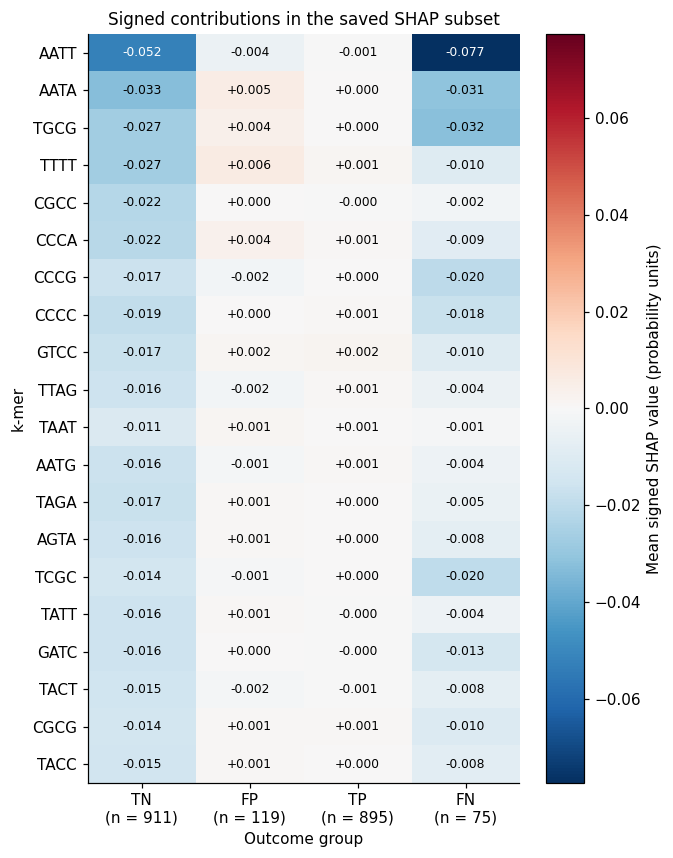

,k_mer,TN,FP,TP,FN
0,AATT,-0.0521,-0.0043,-0.0005,-0.0774
1,AATA,-0.0332,0.0055,0.0000,-0.0313
2,TGCG,-0.0270,0.0038,0.0003,-0.0324
3,TTTT,-0.0272,0.0062,0.0015,-0.0099
4,CGCC,-0.0219,0.0002,-0.0004,-0.0022
5,CCCA,-0.0215,0.0035,0.0008,-0.0088
6,CCCG,-0.0167,-0.0019,0.0001,-0.0203
7,CCCC,-0.0193,0.0002,0.0012,-0.0175
8,GTCC,-0.0175,0.0017,0.0018,-0.0098
9,TTAG,-0.0160,-0.0019,0.0012,-0.0045


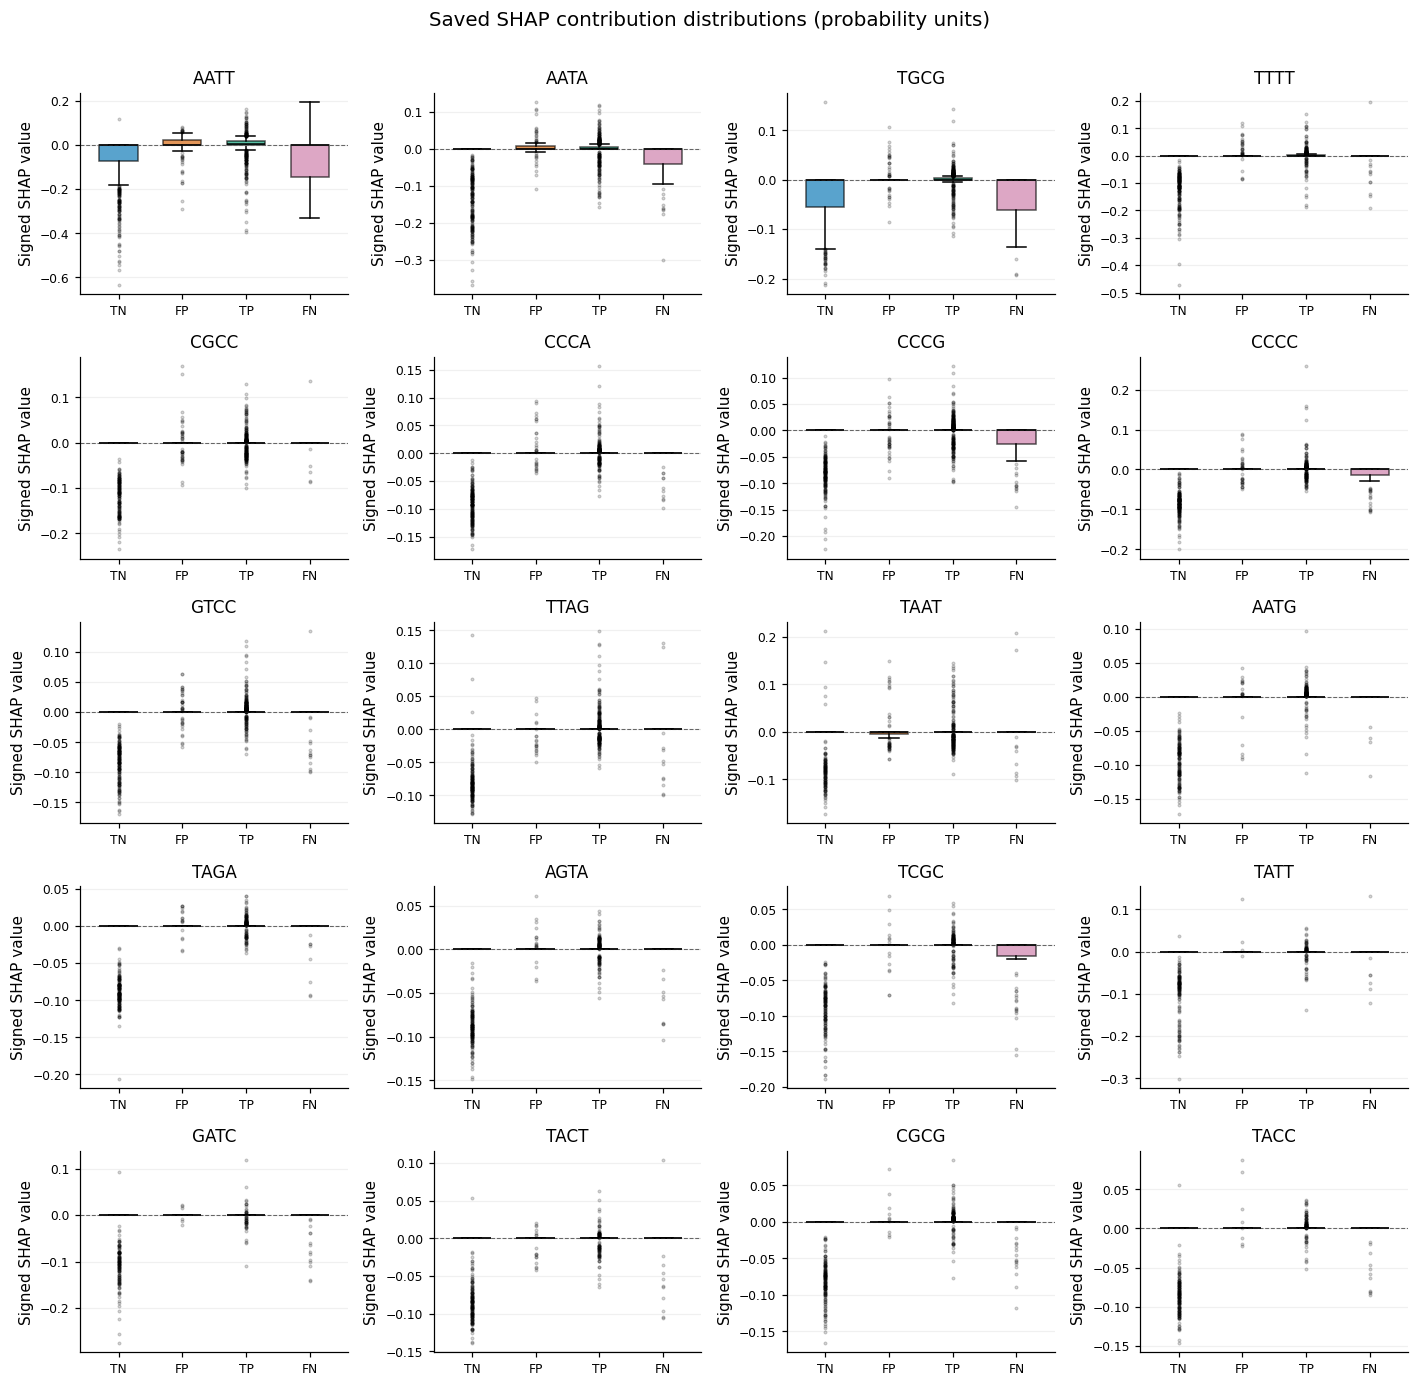

,outer_fold,outcome,k_mer,n,mean_signed_shap,mean_absolute_shap
0,0,FN,AATA,15,-0.0528,0.0528
1,0,FN,AATG,15,-0.0040,0.0040
2,0,FN,AATT,15,-0.0632,0.0892
3,0,FN,AGTA,15,-0.0035,0.0035
4,0,FN,CCCA,15,-0.0102,0.0102
5,0,FN,CCCC,15,-0.0081,0.0081
6,0,FN,CCCG,15,-0.0168,0.0168
7,0,FN,CGCC,15,-0.0010,0.0010
8,0,FN,CGCG,15,-0.0056,0.0056
9,0,FN,GATC,15,-0.0100,0.0100


In [26]:
def signed_heatmap(frame, title, name, xlabel="Outcome group"):
    fig, ax = plt.subplots(figsize=(max(6, .8 * len(frame.columns) + 3), max(4, .32 * len(frame) + 1.5)))
    limit = np.nanmax(np.abs(frame.to_numpy())) if np.isfinite(frame.to_numpy()).any() else 1
    limit = max(limit, 1e-8)
    im = ax.imshow(frame.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set(xticks=np.arange(len(frame.columns)), xticklabels=frame.columns,
           yticks=np.arange(len(frame)), yticklabels=frame.index, xlabel=xlabel, ylabel="k-mer", title=title)
    for i in range(len(frame)):
        for j in range(len(frame.columns)):
            value = frame.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.3f}", ha="center", va="center", fontsize=8,
                        color="white" if abs(value) > .65 * limit else "black")
    fig.colorbar(im, ax=ax, label="Mean signed SHAP value (probability units)")
    fig.tight_layout(); show_figure(fig, name)

signed_means = pd.DataFrame({g: phi.loc[reference.outcome.eq(g)].mean() for g in GROUPS}).loc[top_features]
counts = reference.outcome.value_counts()
heat = signed_means.rename(columns={g: f"{g}\n(n = {counts.get(g, 0)})" for g in GROUPS})
signed_heatmap(heat, "Signed contributions in the saved SHAP subset", "03_signed_shap_heatmap")
table(signed_means.rename_axis("k_mer").reset_index(), "03_signed_shap_means")
distribution_grid(phi, reference, top_features, "Signed SHAP value",
                  "Saved SHAP contribution distributions (probability units)", "03_shap_distributions", zero_line=True)

shap_by_fold = shap_long.loc[shap_long.k_mer.isin(top_features)].groupby(
    ["outer_fold", "outcome", "k_mer"]
).agg(n=("shap_value", "size"), mean_signed_shap=("shap_value", "mean"),
      mean_absolute_shap=("shap_value", lambda s: s.abs().mean())).reset_index()
table(shap_by_fold, "03_shap_by_fold", rows=10)


## 4. Rank features specifically important in errors

Rank **all saved features** by mean absolute SHAP value, separately overall, in FP and in FN.
Magnitude is not evidence of an error-driving direction. Signed means and directional contributions
are therefore exported too. Error-versus-correct differences compare FP with TN and FN with TP.


,k_mer,global_mean_abs,TN_mean_abs,TN_mean_signed,FP_mean_abs,FP_mean_signed,TP_mean_abs,...,FP_minus_TN_mean_abs,FN_minus_TP_mean_abs,FP_mean_positive_contribution,FN_mean_negative_magnitude,global_rank,FP_rank,FN_rank
0,AATT,0.0397,0.0524,-0.0521,0.0324,-0.0043,0.0241,...,-0.0199,0.0585,0.0141,0.0800,1.0,1.0,1.0
1,AATA,0.0221,0.0332,-0.0332,0.0133,0.0055,0.0111,...,-0.0200,0.0203,0.0094,0.0313,2.0,4.0,3.0
2,TGCG,0.0175,0.0274,-0.0270,0.0109,0.0038,0.0071,...,-0.0164,0.0253,0.0073,0.0324,3.0,7.0,2.0
3,TTTT,0.0163,0.0272,-0.0272,0.0115,0.0062,0.0059,...,-0.0156,0.0092,0.0089,0.0126,4.0,6.0,7.0
4,CGCC,0.0140,0.0219,-0.0219,0.0134,0.0002,0.0068,...,-0.0085,-0.0010,0.0068,0.0040,5.0,3.0,44.0
5,CCCA,0.0125,0.0215,-0.0215,0.0079,0.0035,0.0042,...,-0.0137,0.0046,0.0057,0.0088,6.0,10.0,27.0
6,CCCG,0.0122,0.0167,-0.0167,0.0116,-0.0019,0.0070,...,-0.0050,0.0133,0.0049,0.0203,7.0,5.0,4.0
7,CCCC,0.0120,0.0193,-0.0193,0.0088,0.0002,0.0045,...,-0.0105,0.0130,0.0045,0.0175,8.0,8.0,6.0
8,GTCC,0.0110,0.0175,-0.0175,0.0084,0.0017,0.0046,...,-0.0091,0.0088,0.0050,0.0116,9.0,9.0,8.0
9,TTAG,0.0106,0.0165,-0.0160,0.0042,-0.0019,0.0053,...,-0.0123,0.0061,0.0011,0.0079,10.0,18.0,13.0


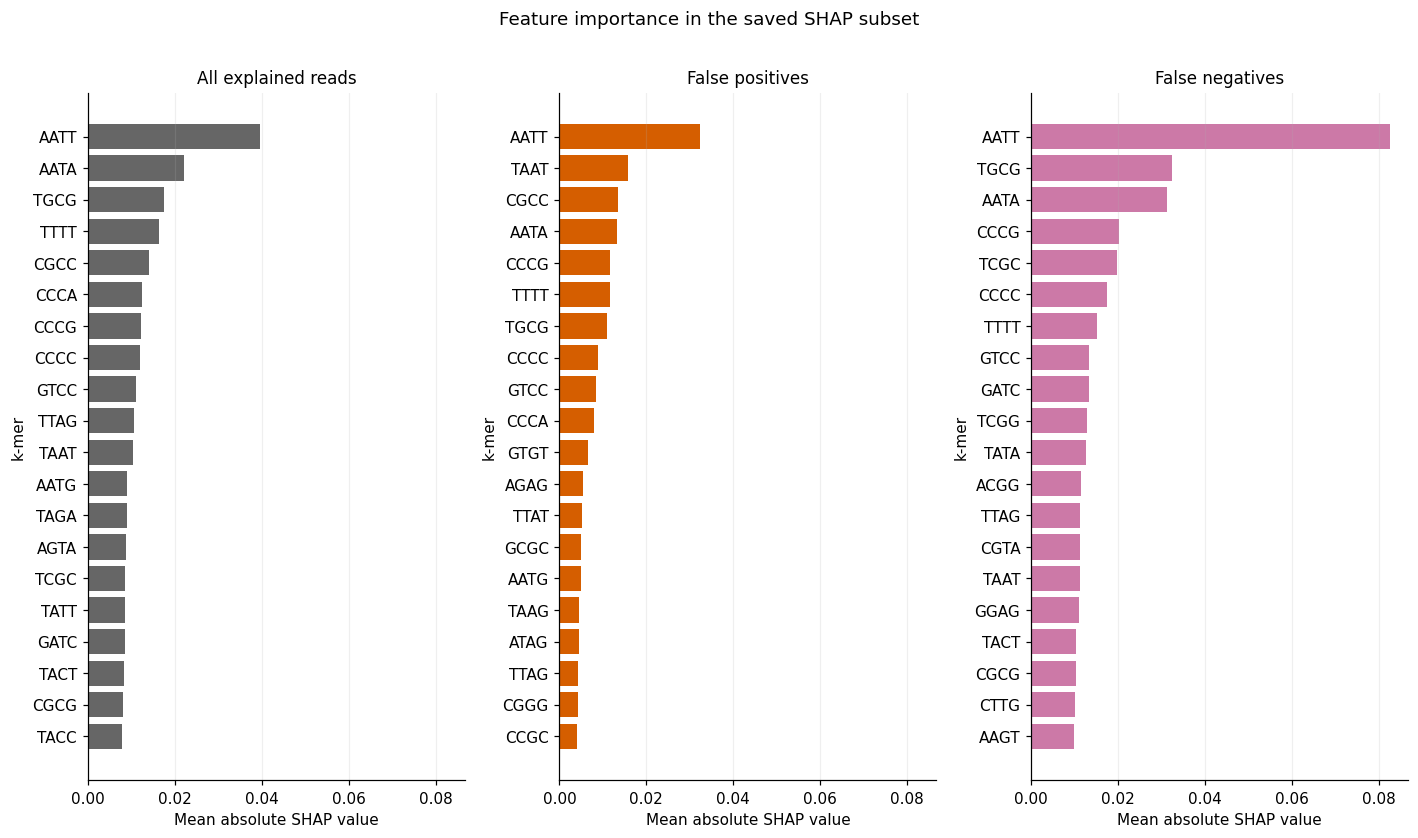

In [27]:
importance = pd.DataFrame({"global_mean_abs": phi.abs().mean()})
for group in GROUPS:
    group_phi = phi.loc[reference.outcome.eq(group)]
    importance[f"{group}_mean_abs"] = group_phi.abs().mean()
    importance[f"{group}_mean_signed"] = group_phi.mean()
importance["FP_minus_TN_mean_abs"] = importance.FP_mean_abs - importance.TN_mean_abs
importance["FN_minus_TP_mean_abs"] = importance.FN_mean_abs - importance.TP_mean_abs
importance["FP_mean_positive_contribution"] = phi.loc[reference.outcome.eq("FP")].clip(lower=0).mean()
importance["FN_mean_negative_magnitude"] = -phi.loc[reference.outcome.eq("FN")].clip(upper=0).mean()
for label, column in [("global", "global_mean_abs"), ("FP", "FP_mean_abs"), ("FN", "FN_mean_abs")]:
    importance[f"{label}_rank"] = importance[column].rank(ascending=False, method="min")
table(importance.sort_values("global_mean_abs", ascending=False).rename_axis("k_mer").reset_index(),
      "04_all_feature_rankings", rows=20)

fig, axes = plt.subplots(1, 3, figsize=(13, 7.5), sharex=True)
for ax, label, column, color in zip(axes, ["All explained reads", "False positives", "False negatives"],
                                   ["global_mean_abs", "FP_mean_abs", "FN_mean_abs"],
                                   ["#666666", COLORS["FP"], COLORS["FN"]]):
    ordered = importance[column].dropna().sort_values(ascending=False).head(TOP_N)
    ax.barh(np.arange(len(ordered)), ordered.values, color=color)
    ax.set(yticks=np.arange(len(ordered)), yticklabels=ordered.index, title=label,
           xlabel="Mean absolute SHAP value", ylabel="k-mer")
    ax.invert_yaxis(); ax.grid(axis="x", alpha=.2)
fig.suptitle("Feature importance in the saved SHAP subset", y=1.01)
fig.tight_layout(); show_figure(fig, "04_global_fp_fn_rankings")


## 5. Identify recurring error profiles

Cluster FP and FN separately using signed SHAP vectors for the global top-20 features.
Average-linkage hierarchical clustering uses Euclidean distances without feature standardization.
**All cuts from 2 to 6 groups are displayed and exported.** No group-size or silhouette threshold
is applied, and no preferred cut is selected. Silhouette scores are descriptive only.

Every plot reports group sizes and the silhouette for its partition. Group identifiers are local
to each outcome and number of groups; group 1 at k = 2 need not equal group 1 at k = 3.
Inspect fold composition because models and SHAP backgrounds differ between folds.
A single-read group is an individual profile, not a recurring error type. Each group's representative
is its medoid (minimum average within-group distance).


FP, k = 2: group sizes [118, 1]; silhouette = 0.592 (descriptive only).


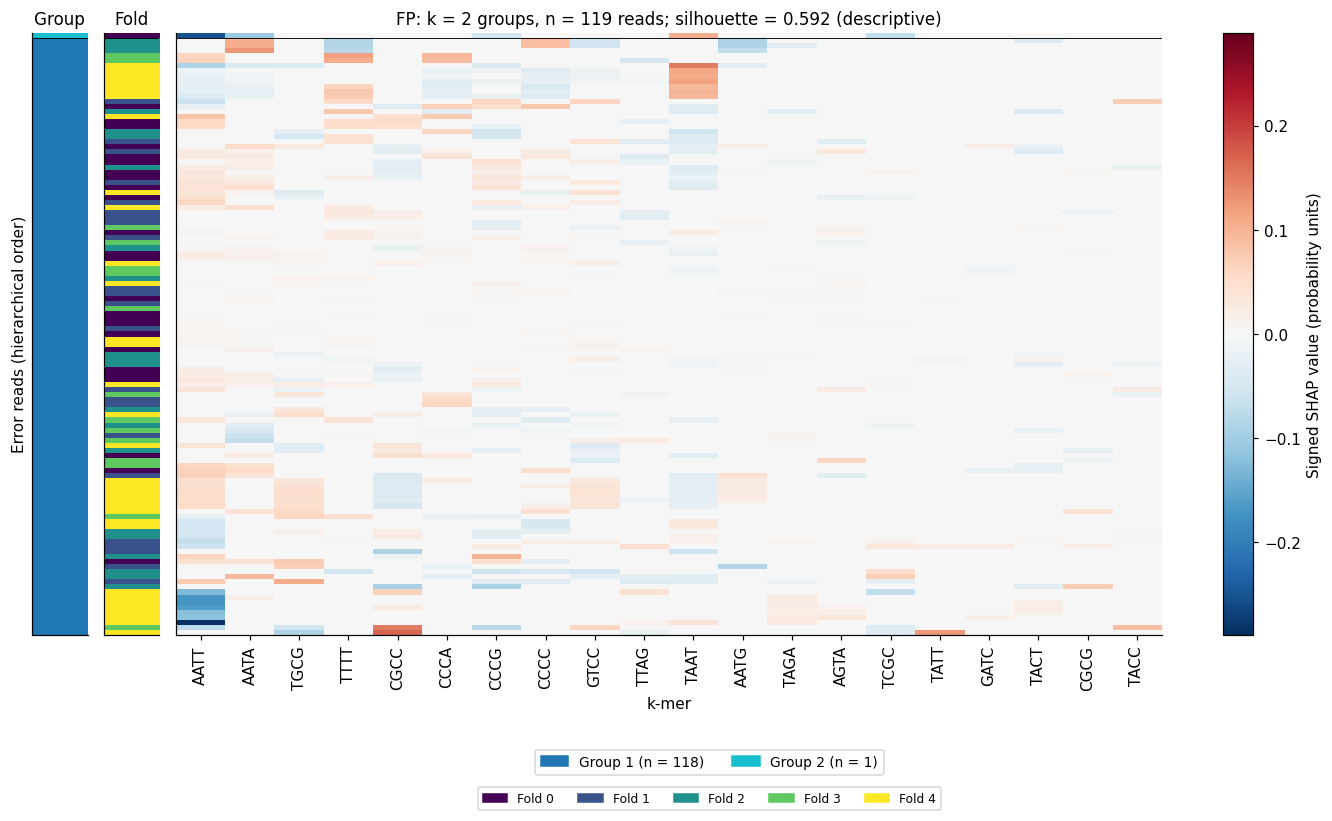

FP, k = 3: group sizes [116, 2, 1]; silhouette = 0.498 (descriptive only).


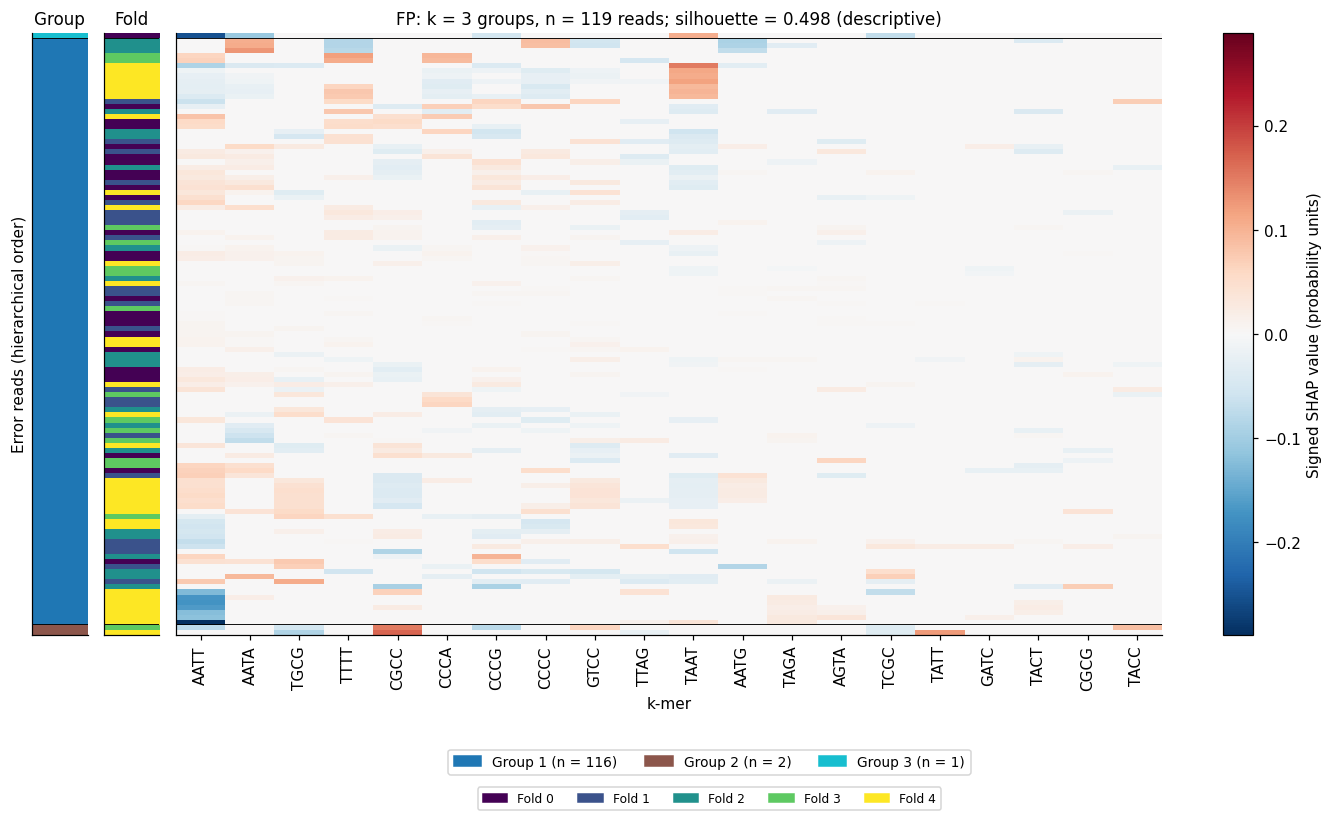

FP, k = 4: group sizes [113, 3, 2, 1]; silhouette = 0.435 (descriptive only).


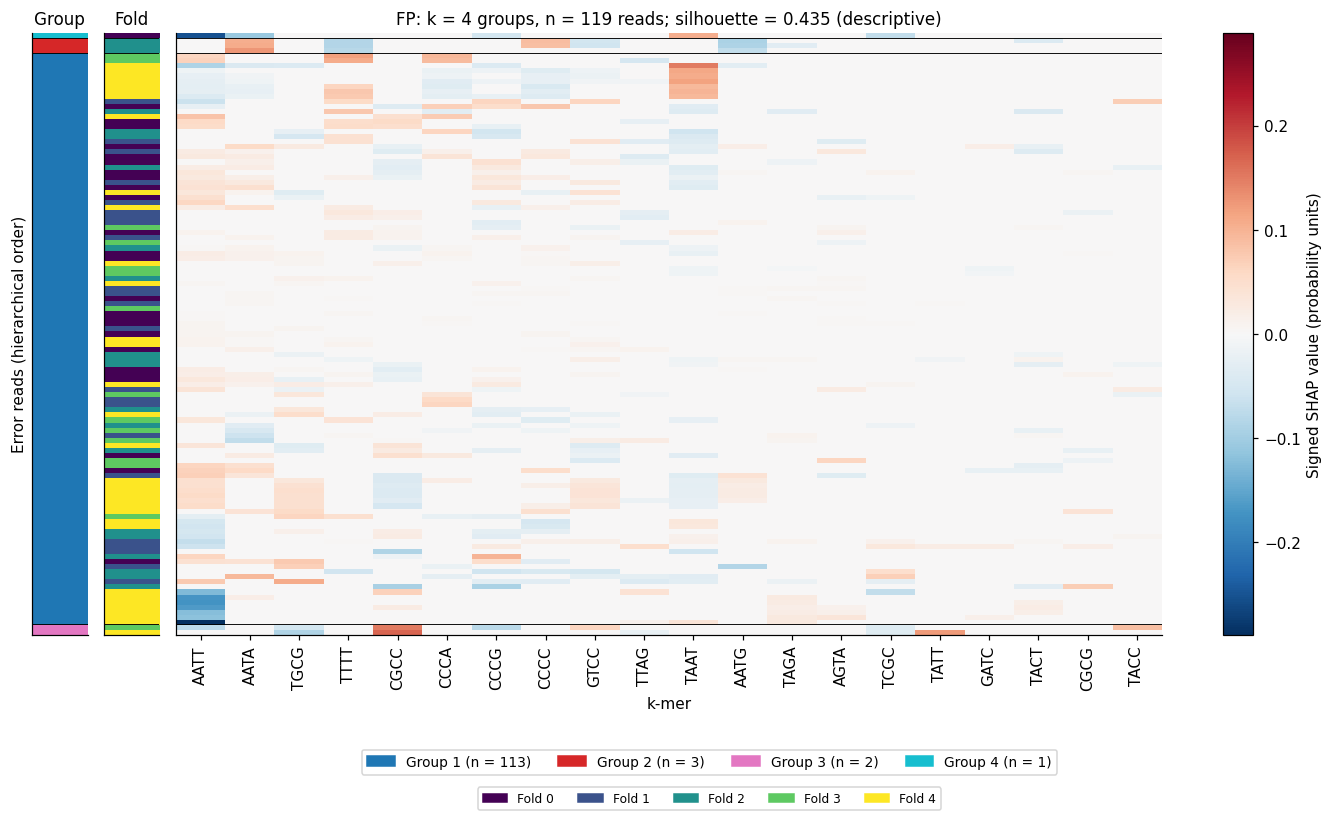

FP, k = 5: group sizes [113, 3, 1, 1, 1]; silhouette = 0.428 (descriptive only).


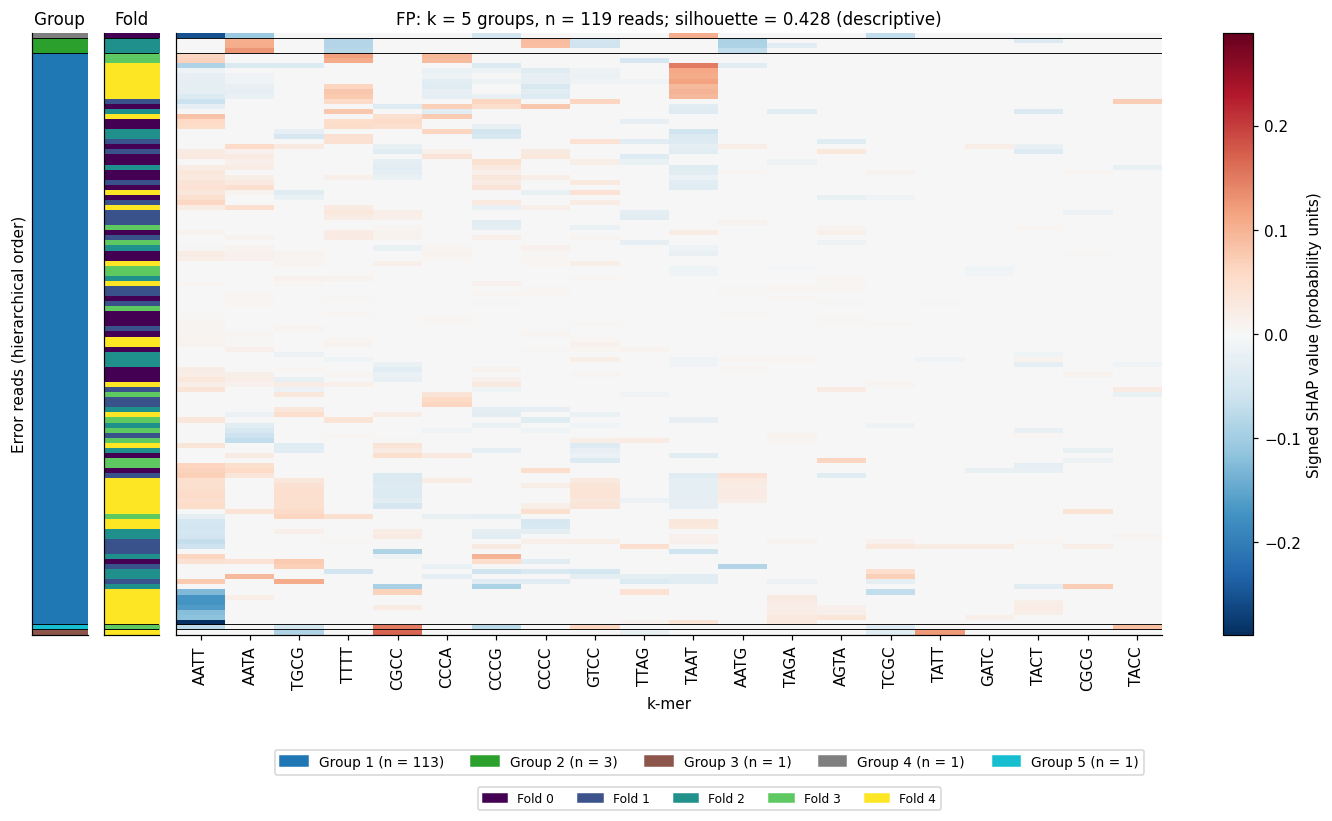

FP, k = 6: group sizes [106, 7, 3, 1, 1, 1]; silhouette = 0.444 (descriptive only).


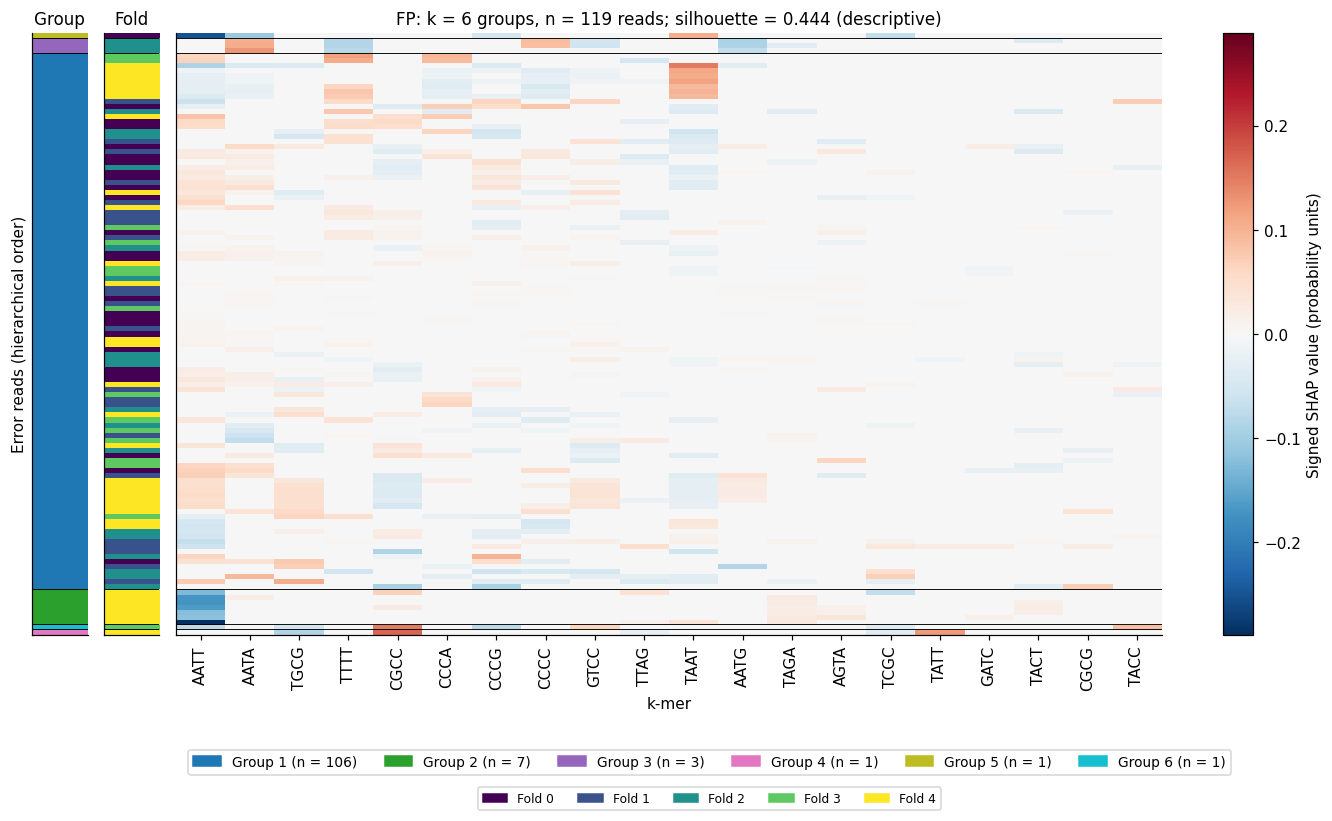

FN, k = 2: group sizes [67, 8]; silhouette = 0.341 (descriptive only).


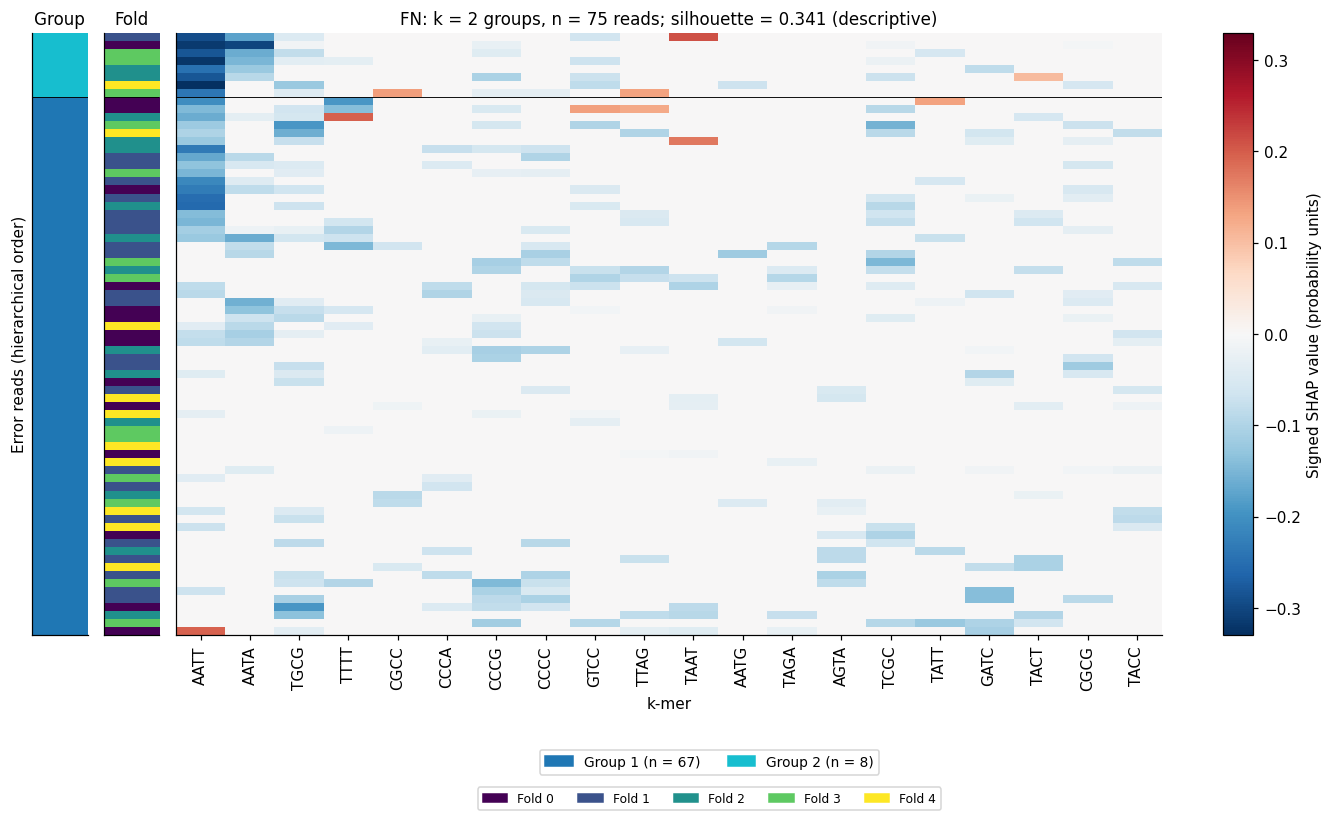

FN, k = 3: group sizes [65, 8, 2]; silhouette = 0.299 (descriptive only).


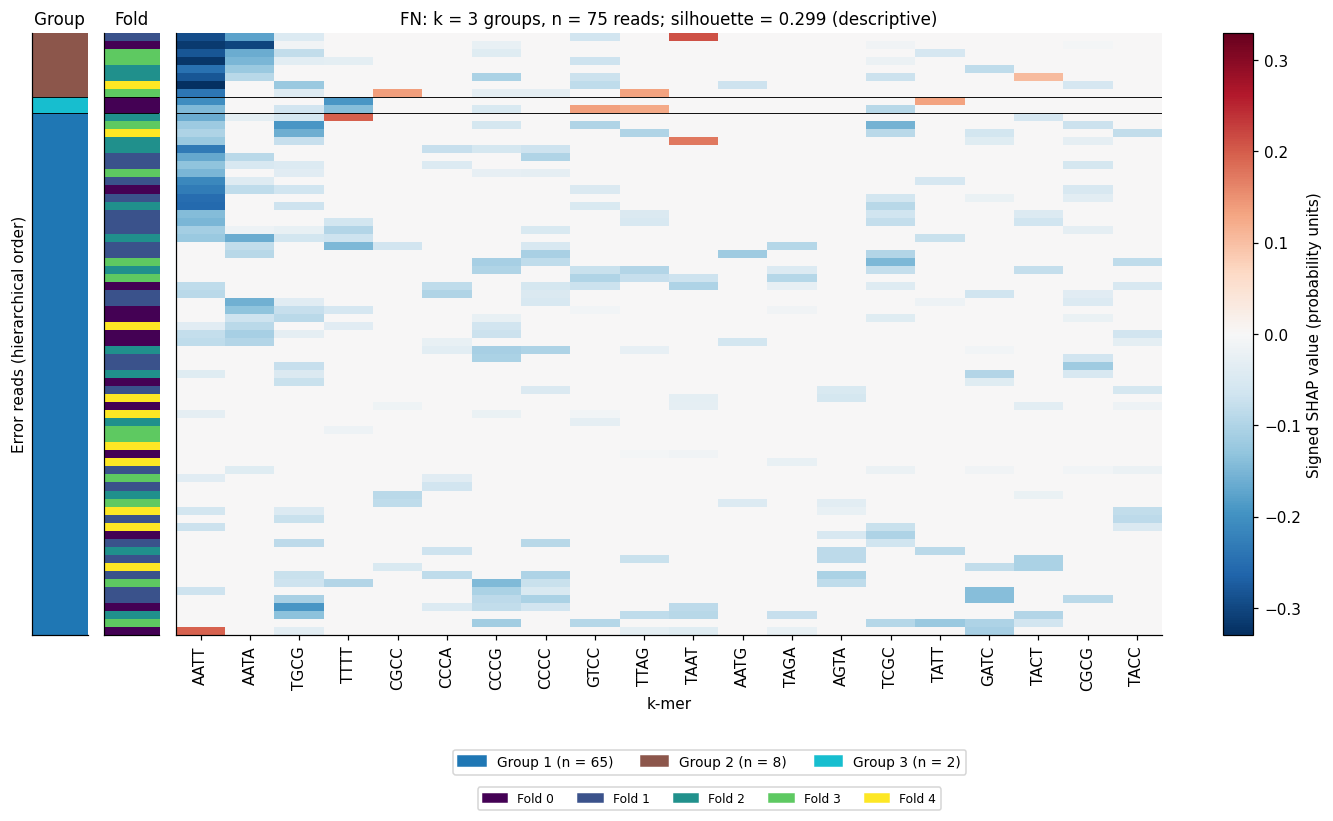

FN, k = 4: group sizes [64, 8, 1, 2]; silhouette = 0.220 (descriptive only).


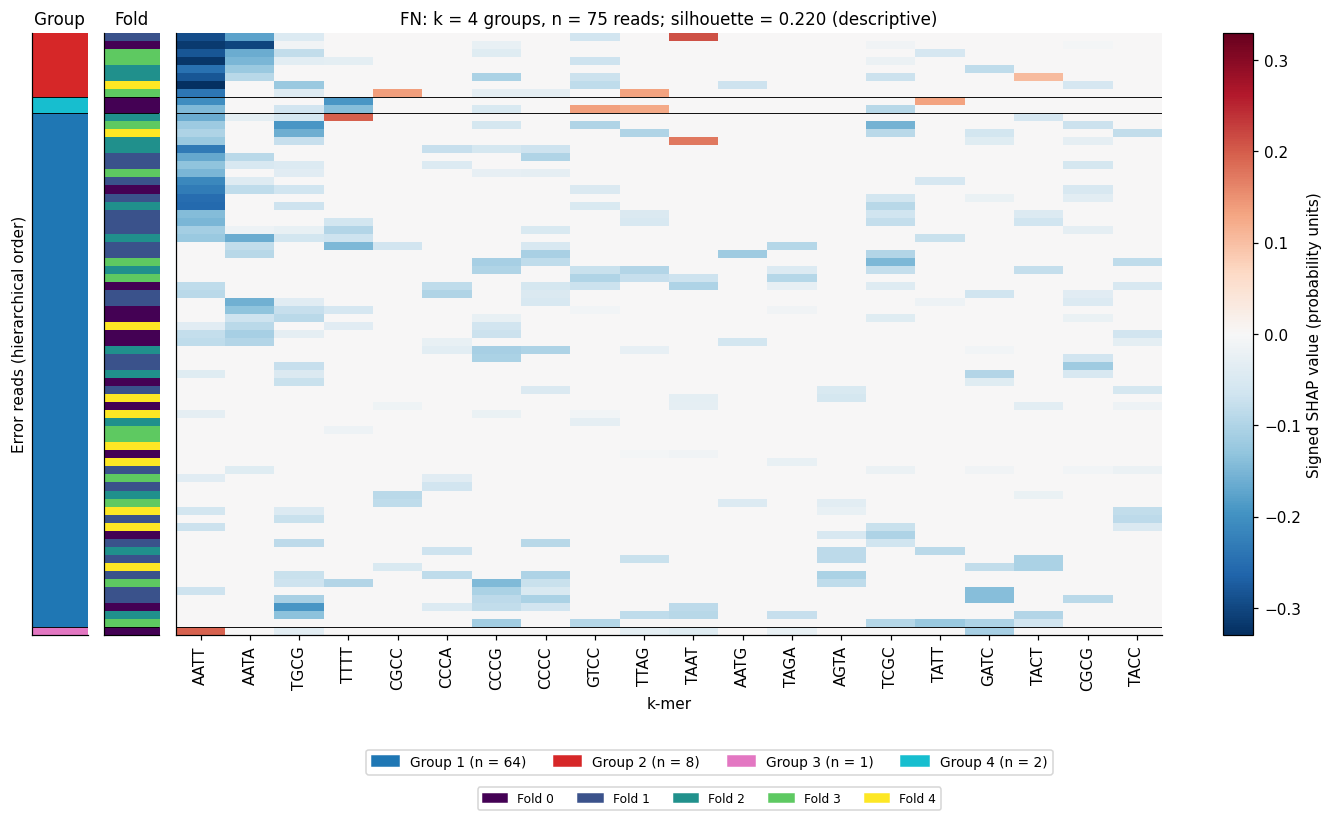

FN, k = 5: group sizes [64, 7, 1, 2, 1]; silhouette = 0.201 (descriptive only).


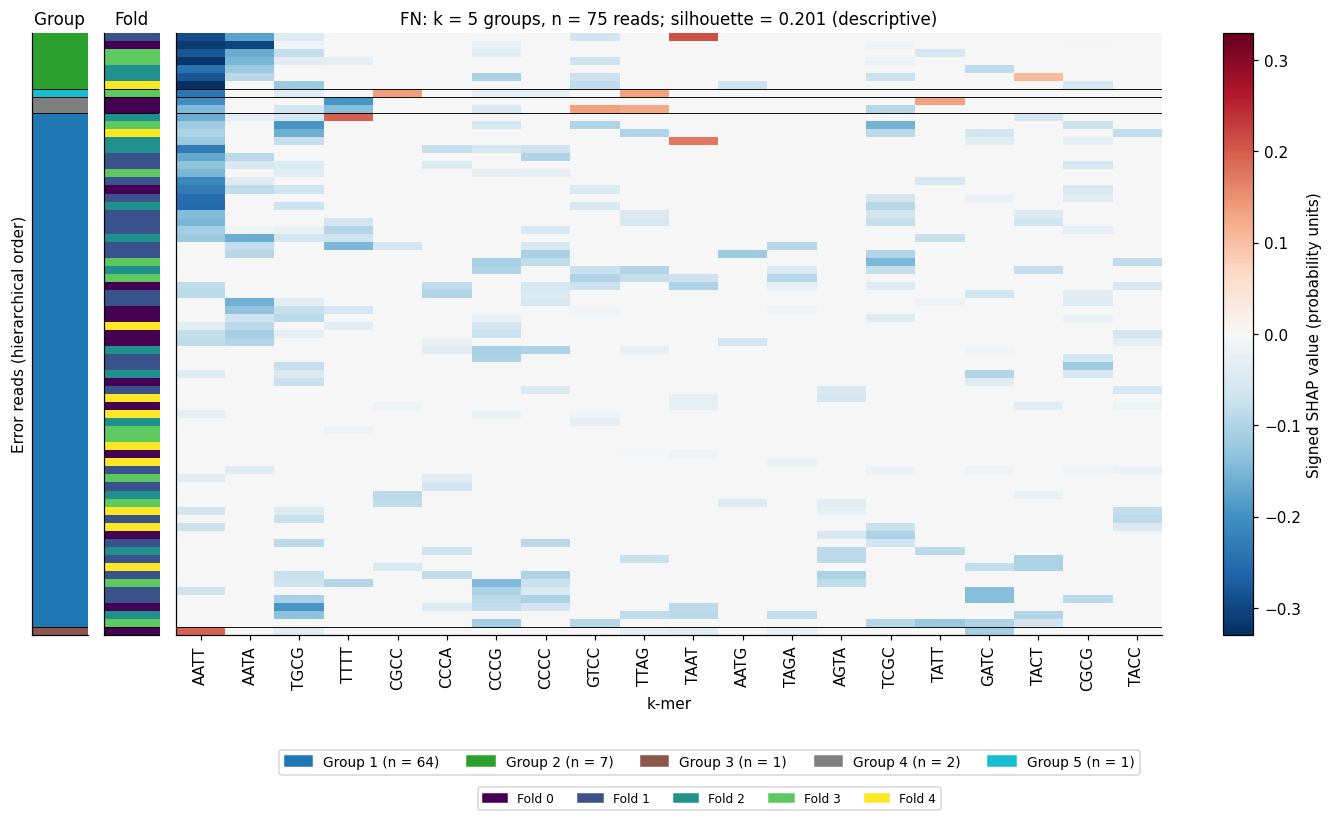

FN, k = 6: group sizes [63, 7, 1, 1, 2, 1]; silhouette = 0.194 (descriptive only).


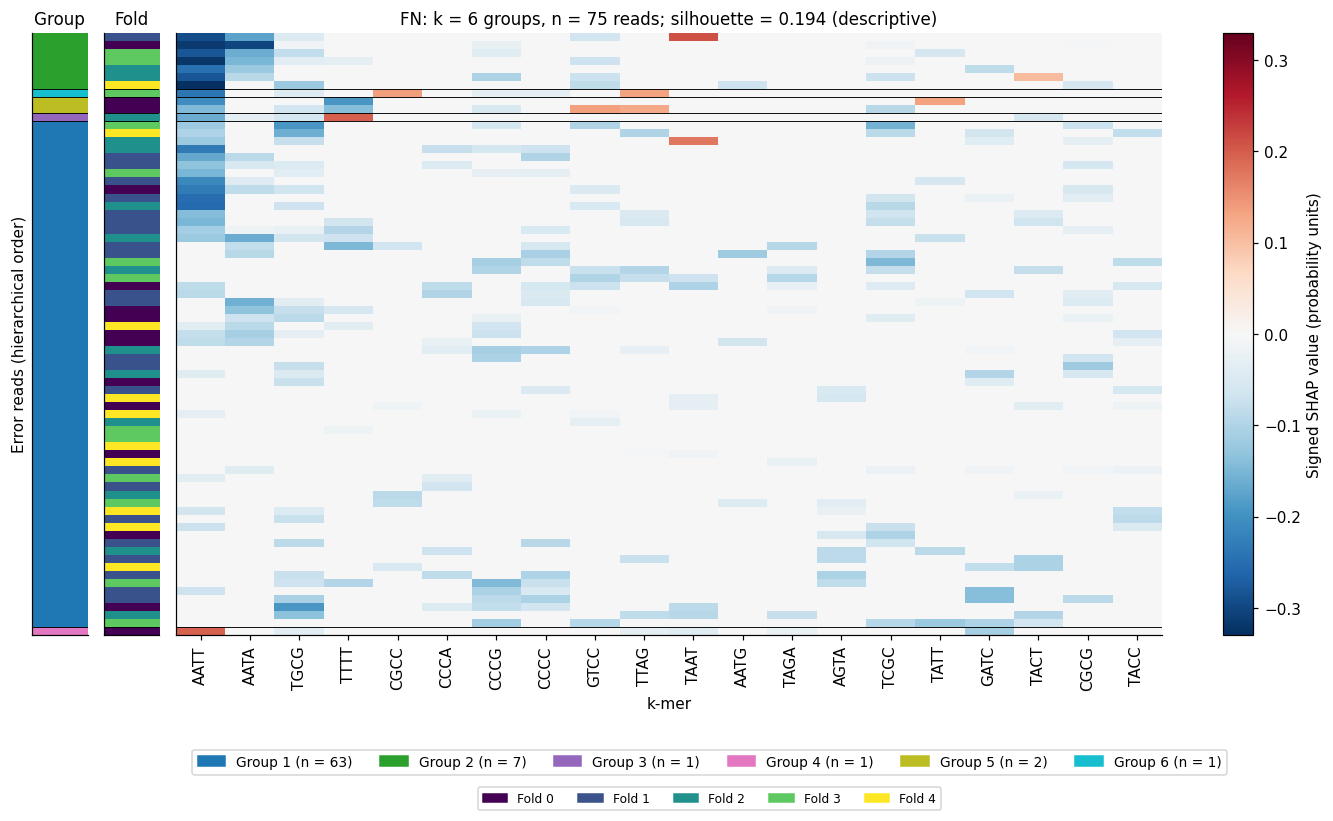

,outcome,k,n_reads,group_sizes,silhouette
0,FP,2,119,"118, 1",0.5925
1,FP,3,119,"116, 2, 1",0.4976
2,FP,4,119,"113, 3, 2, 1",0.4350
3,FP,5,119,"113, 3, 1, 1, 1",0.4282
4,FP,6,119,"106, 7, 3, 1, 1, 1",0.4437
5,FN,2,75,"67, 8",0.3413
6,FN,3,75,"65, 8, 2",0.2991
7,FN,4,75,"64, 8, 1, 2",0.2199
8,FN,5,75,"64, 7, 1, 2, 1",0.2014
9,FN,6,75,"63, 7, 1, 1, 2, 1",0.1940


,outcome,k,cluster,n,medoid_read_id,silhouette
0,FP,2,1,118,2826,0.5925
1,FP,2,2,1,2510,0.5925
2,FP,3,1,116,2826,0.4976
3,FP,3,2,2,1738,0.4976
4,FP,3,3,1,2510,0.4976
...,...,...,...,...,...,...
35,FN,6,2,7,12375,0.1940
36,FN,6,3,1,14273,0.1940
37,FN,6,4,1,14629,0.1940
38,FN,6,5,2,14751,0.1940


,read_id,outcome,k,cluster,n,criterion
0,2826,FP,2,1,118,"FP, k=2, group 1 medoid (n=118)"
1,2510,FP,2,2,1,"FP, k=2, group 2 medoid (n=1)"
2,2826,FP,3,1,116,"FP, k=3, group 1 medoid (n=116)"
3,1738,FP,3,2,2,"FP, k=3, group 2 medoid (n=2)"
4,2510,FP,3,3,1,"FP, k=3, group 3 medoid (n=1)"
...,...,...,...,...,...,...
35,12375,FN,6,2,7,"FN, k=6, group 2 medoid (n=7)"
36,14273,FN,6,3,1,"FN, k=6, group 3 medoid (n=1)"
37,14629,FN,6,4,1,"FN, k=6, group 4 medoid (n=1)"
38,14751,FN,6,5,2,"FN, k=6, group 5 medoid (n=2)"


,read_id,outcome,k,cluster,outer_fold
0,40,FP,2,1,0
1,74,FP,2,1,3
2,93,FP,2,1,0
3,123,FP,2,1,4
4,249,FP,2,1,2
5,278,FP,2,1,4
6,329,FP,2,1,4
7,546,FP,2,1,2
8,737,FP,2,1,4
9,751,FP,2,1,2


In [28]:
cluster_rows, diagnostic_rows, representative_rows, cluster_summary_rows = [], [], [], []
for outcome in ["FP", "FN"]:
    ids = reference.index[reference.outcome.eq(outcome)].to_numpy()
    values = phi.loc[ids, top_features].to_numpy()
    if len(ids) < 2:
        print(f"{outcome}: fewer than two explained reads; no cut into two or more groups is possible.")
        continue
    distances = squareform(pdist(values, metric="euclidean"))
    tree = linkage(values, method="average", metric="euclidean", optimal_ordering=True)
    order = leaves_list(tree)
    fold_levels = sorted(pred.outer_fold.unique())
    fold_codes = np.array([fold_levels.index(f) for f in reference.loc[ids, "outer_fold"].to_numpy()[order]])
    fold_cmap = plt.get_cmap("viridis", len(fold_levels))
    limit = max(float(np.max(np.abs(values))), 1e-8)

    for k in range(2, MAX_CLUSTERS + 1):
        if k > len(ids):
            print(f"{outcome}, k = {k}: more groups than reads; cut not defined.")
            continue
        labels = cut_tree(tree, n_clusters=k).ravel() + 1
        sizes = np.bincount(labels, minlength=k + 1)[1:]
        score = silhouette_score(distances, labels, metric="precomputed") if k < len(ids) else np.nan
        score_label = f"{score:.3f}" if np.isfinite(score) else "undefined (one read per group)"
        diagnostic_rows.append({"outcome": outcome, "k": k, "n_reads": len(ids),
                                "group_sizes": ", ".join(str(int(n)) for n in sizes), "silhouette": score})
        print(f"{outcome}, k = {k}: group sizes {sizes.tolist()}; silhouette = {score_label} (descriptive only).")
        for i, read_id in enumerate(ids):
            cluster_rows.append({"read_id": int(read_id), "outcome": outcome, "k": k,
                                 "cluster": int(labels[i]), "outer_fold": int(reference.loc[read_id, "outer_fold"])})
        for cluster in range(1, k + 1):
            members = np.flatnonzero(labels == cluster)
            medoid_position = members[np.argmin(distances[np.ix_(members, members)].mean(axis=1))]
            medoid = int(ids[medoid_position])
            representative_rows.append({"read_id": medoid, "outcome": outcome, "k": k,
                                         "cluster": cluster, "n": len(members),
                                         "criterion": f"{outcome}, k={k}, group {cluster} medoid (n={len(members)})"})
            cluster_summary_rows.append({"outcome": outcome, "k": k, "cluster": cluster,
                                         "n": len(members), "medoid_read_id": medoid, "silhouette": score})

        fig, axes = plt.subplots(1, 3, figsize=(13, 7.5), gridspec_kw={"width_ratios": [.45, .45, 10]})
        cmap = plt.get_cmap("tab10", k)
        axes[0].imshow(labels[order, None], aspect="auto", cmap=cmap, vmin=.5, vmax=k + .5, interpolation="nearest")
        axes[0].set(title="Group", xticks=[], yticks=[], ylabel="Error reads (hierarchical order)")
        axes[1].imshow(fold_codes[:, None], aspect="auto", cmap=fold_cmap,
                       vmin=-.5, vmax=len(fold_levels) - .5, interpolation="nearest")
        axes[1].set(title="Fold", xticks=[], yticks=[])
        im = axes[2].imshow(values[order], aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
        axes[2].set(xticks=np.arange(len(top_features)), xticklabels=top_features, yticks=[], xlabel="k-mer",
                    title=f"{outcome}: k = {k} groups, n = {len(ids)} reads; silhouette = {score_label} (descriptive)")
        axes[2].tick_params(axis="x", rotation=90)
        for boundary in np.flatnonzero(np.diff(labels[order])) + .5:
            for ax in axes:
                ax.axhline(boundary, color="black", linewidth=.6)
        group_handles = [Patch(color=cmap(c - 1), label=f"Group {c} (n = {sizes[c - 1]})") for c in range(1, k + 1)]
        fold_handles = [Patch(color=fold_cmap(i), label=f"Fold {f}") for i, f in enumerate(fold_levels)]
        fig.legend(handles=group_handles, loc="lower center", ncol=k, fontsize=9, bbox_to_anchor=(.5, .045))
        fig.legend(handles=fold_handles, loc="lower center", ncol=len(fold_levels), fontsize=8, bbox_to_anchor=(.5, .003))
        fig.colorbar(im, ax=axes[2], label="Signed SHAP value (probability units)")
        fig.tight_layout(rect=(0, .11, 1, 1))
        show_figure(fig, f"05_{outcome.lower()}_k{k}_clustered_shap")

clusters = pd.DataFrame(cluster_rows, columns=["read_id", "outcome", "k", "cluster", "outer_fold"])
cluster_representatives = pd.DataFrame(representative_rows, columns=["read_id", "outcome", "k", "cluster", "n", "criterion"])
diagnostics = pd.DataFrame(diagnostic_rows, columns=["outcome", "k", "n_reads", "group_sizes", "silhouette"])
table(diagnostics, "05_cluster_cut_diagnostics", rows=len(diagnostics))
table(pd.DataFrame(cluster_summary_rows), "05_cluster_summary", rows=len(cluster_summary_rows))
table(cluster_representatives, "05_cluster_representatives", rows=len(cluster_representatives))
table(clusters, "05_read_cluster_assignments", rows=10)


outer_fold,outcome,k,cluster,0,1,2,3,4
0,FN,2,1,14,22,12,10,9
1,FN,2,2,1,1,2,3,1
2,FN,3,1,12,22,12,10,9
3,FN,3,2,1,1,2,3,1
4,FN,3,3,2,0,0,0,0
...,...,...,...,...,...,...,...,...
35,FP,6,2,0,0,0,0,7
36,FP,6,3,0,0,3,0,0
37,FP,6,4,0,0,0,0,1
38,FP,6,5,1,0,0,0,0


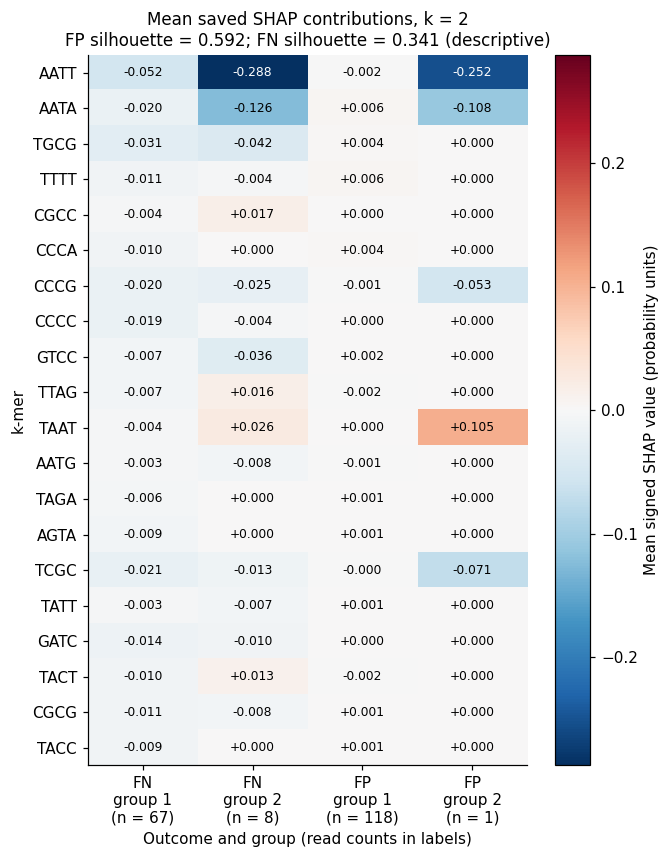

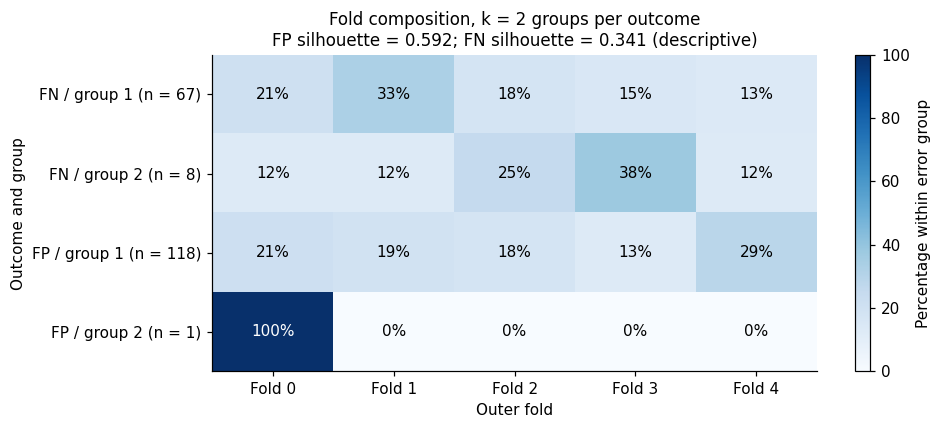

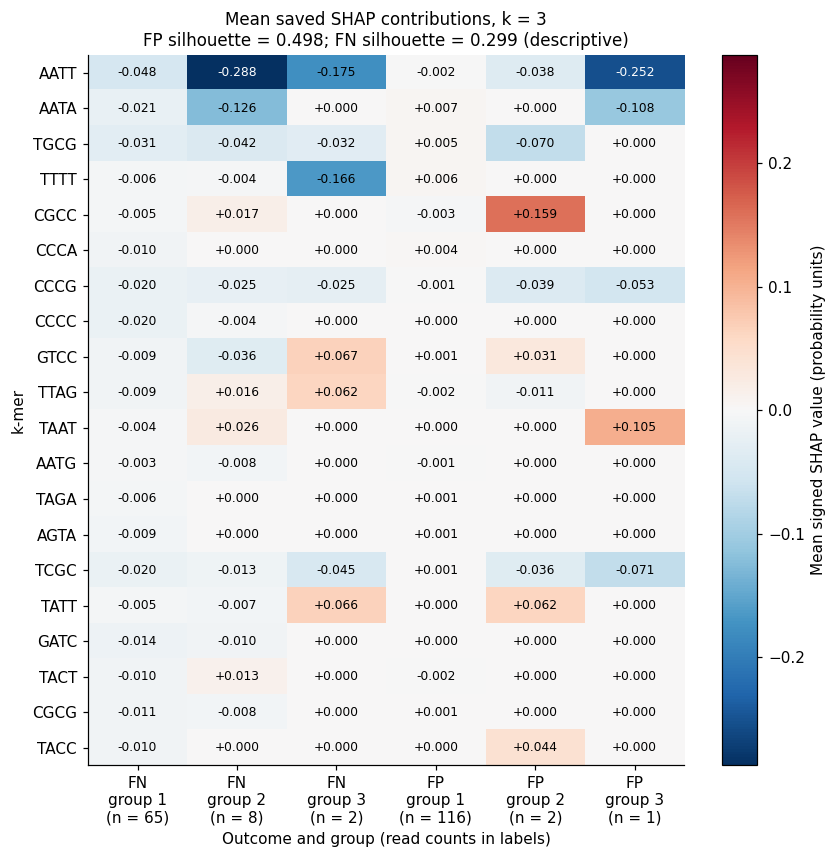

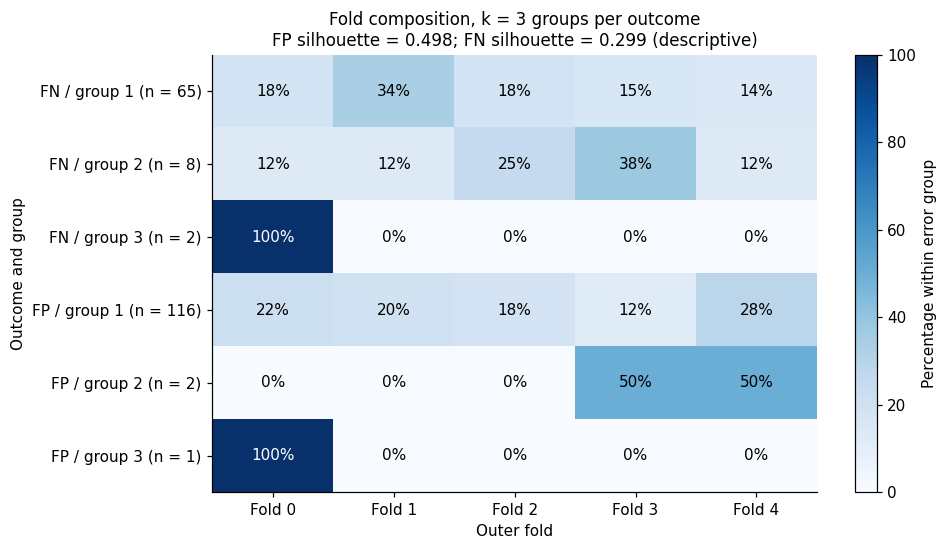

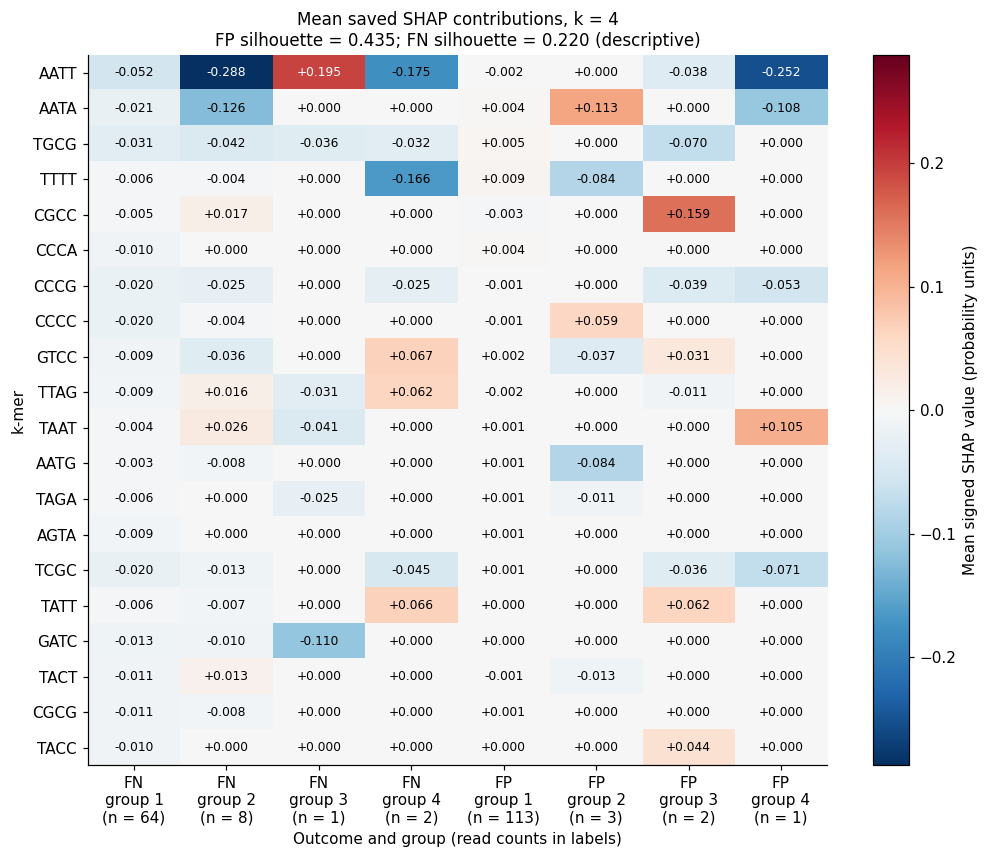

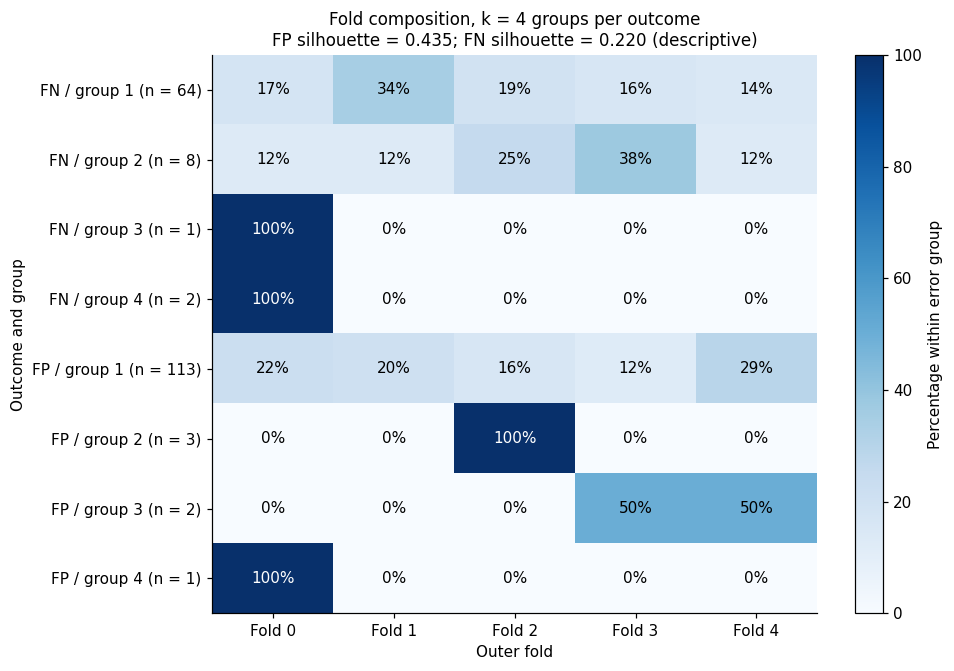

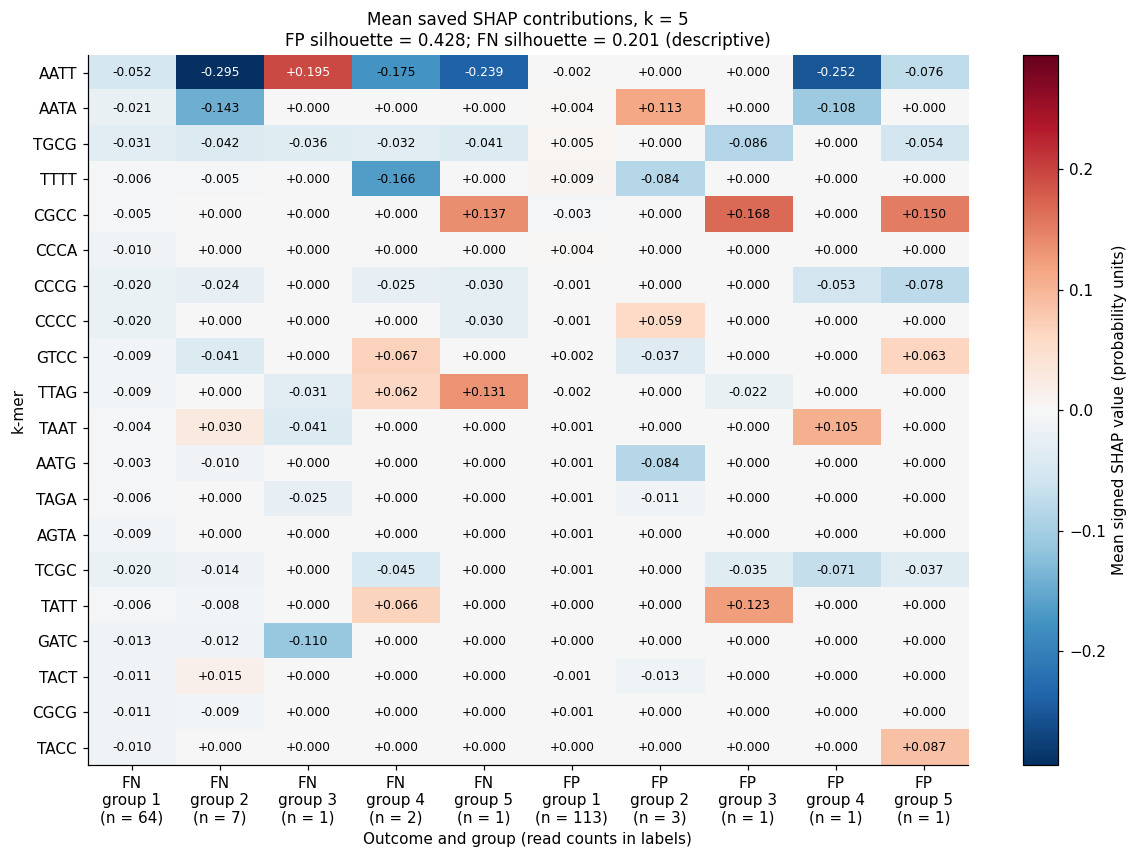

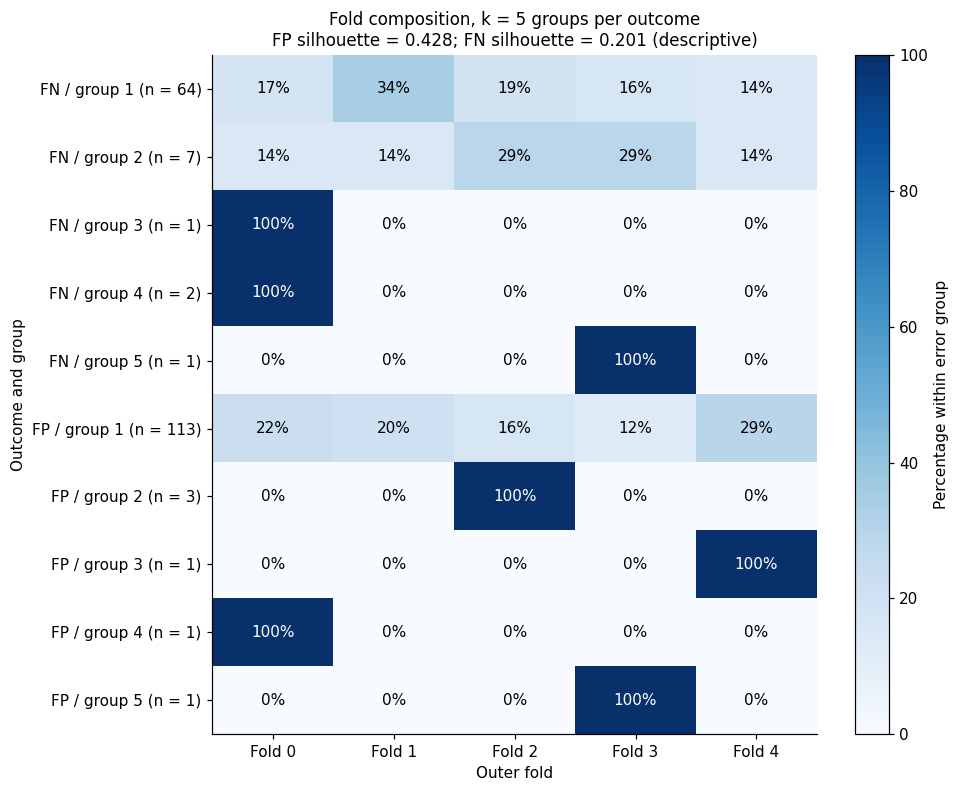

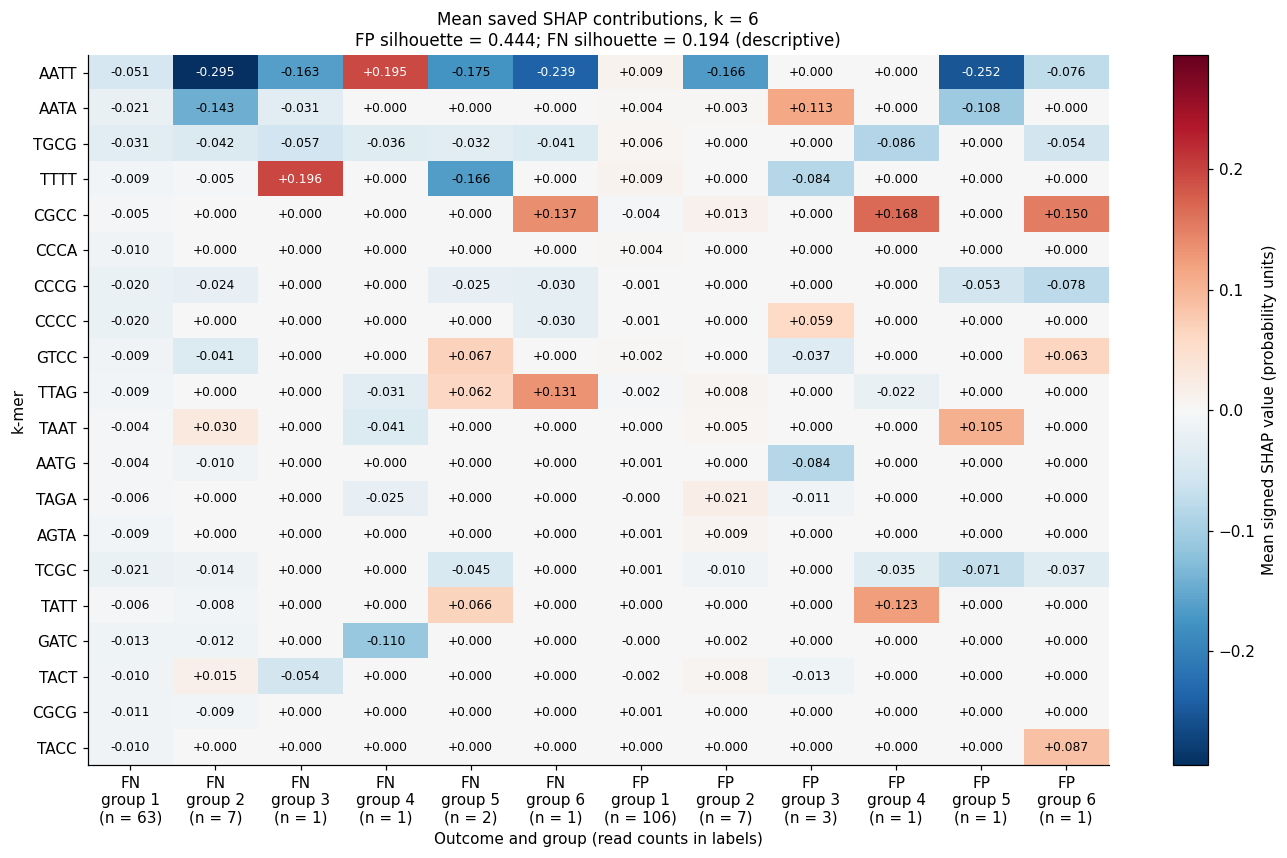

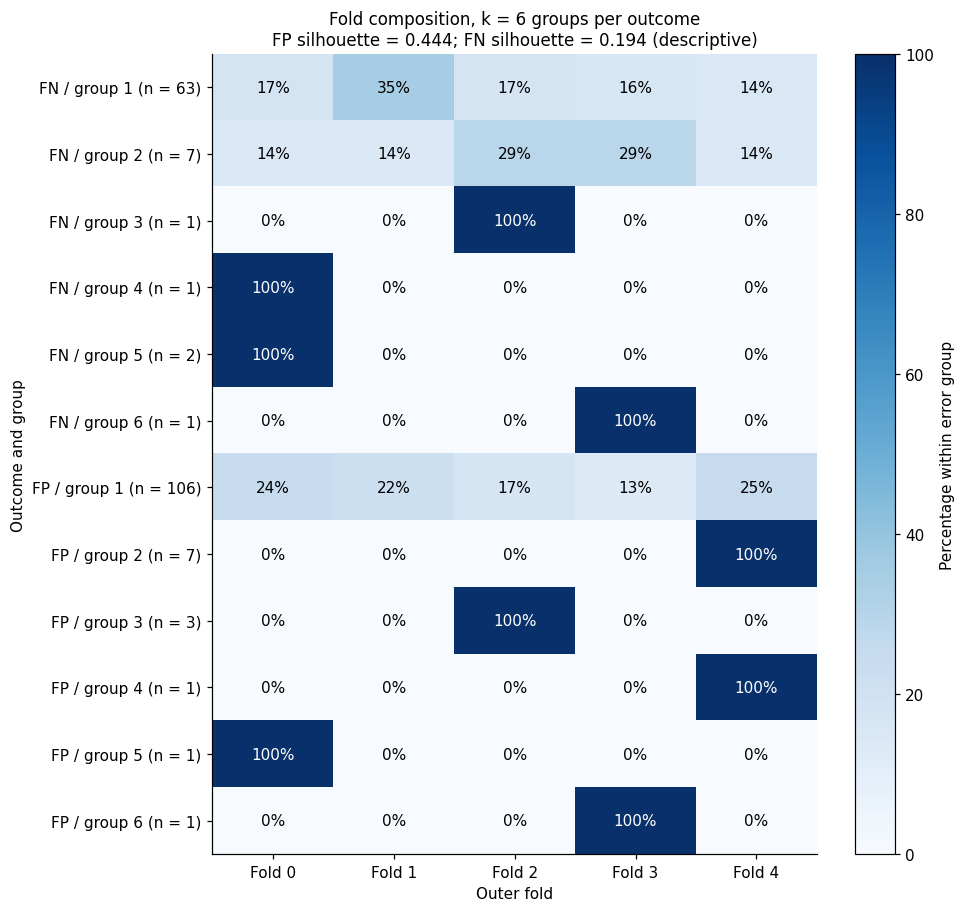

In [29]:
if not clusters.empty:
    all_fold_counts = pd.crosstab([clusters.outcome, clusters.k, clusters.cluster], clusters.outer_fold).reindex(
        columns=sorted(pred.outer_fold.unique()), fill_value=0
    )
    table(all_fold_counts.reset_index(), "05_cluster_fold_counts", rows=len(all_fold_counts))
    for k in sorted(clusters.k.unique()):
        partition = clusters.loc[clusters.k.eq(k)]
        sizes = partition.groupby(["outcome", "cluster"]).size()
        scores = diagnostics.loc[diagnostics.k.eq(k)].set_index("outcome").silhouette
        score_text = "; ".join(f"{outcome} silhouette = {score:.3f}" for outcome, score in scores.items())
        cluster_profiles = phi.loc[partition.read_id, top_features].copy()
        cluster_profiles["profile"] = [
            f"{row.outcome}\ngroup {row.cluster}\n(n = {sizes.loc[(row.outcome, row.cluster)]})"
            for row in partition.itertuples(index=False)
        ]
        profile_means = cluster_profiles.groupby("profile").mean().T
        signed_heatmap(profile_means, f"Mean saved SHAP contributions, k = {k}\n{score_text} (descriptive)",
                       f"05_k{k}_cluster_mean_profiles", xlabel="Outcome and group (read counts in labels)")

        fold_counts = all_fold_counts.xs(k, level="k")
        fold_percent = 100 * fold_counts.div(fold_counts.sum(axis=1), axis=0)
        fig, ax = plt.subplots(figsize=(9, max(3.8, .55 * len(fold_counts) + 1.8)))
        im = ax.imshow(fold_percent, cmap="Blues", aspect="auto", vmin=0, vmax=100)
        ax.set(xticks=np.arange(len(fold_counts.columns)), xticklabels=[f"Fold {f}" for f in fold_counts.columns],
               yticks=np.arange(len(fold_counts)),
               yticklabels=[f"{o} / group {c} (n = {fold_counts.loc[(o, c)].sum()})" for o, c in fold_counts.index],
               xlabel="Outer fold", ylabel="Outcome and group",
               title=f"Fold composition, k = {k} groups per outcome\n{score_text} (descriptive)")
        for i in range(len(fold_counts)):
            for j in range(len(fold_counts.columns)):
                value = fold_percent.iloc[i, j]
                ax.text(j, i, f"{value:.0f}%", ha="center", va="center", color="white" if value > 55 else "black")
        fig.colorbar(im, ax=ax, label="Percentage within error group")
        fig.tight_layout(); show_figure(fig, f"05_k{k}_cluster_fold_composition")


## 6. Inspect representative individual errors

Select the highest infection-probability FP and lowest infection-probability FN **among explained
reads**, the FP/FN with the smallest within-fold absolute-score percentile, and one medoid per
error group in every displayed partition (k = 2–6). Repeated representatives are plotted once,
with all selection reasons retained in the table. Ties are resolved by read ID. Population-wide probability extremes are also listed
to show whether they have saved explanations.

Waterfalls use the original saved baseline and all SHAP contributions; smaller contributions are
summed into an “other features” bar. The endpoint is the **older model probability reconstructed
from SHAP**, and the replayed probability is reported separately. No explanation is generated for
an unrepresented read. Absolute-score percentiles are fold-relative selection heuristics, not probabilities.
Intermediate additive totals are not separate model predictions and may fall outside [0, 1].


,outcome,read_id,probability_infected,has_saved_SHAP
0,FP,2900,1.0,False
1,FN,12199,0.0,True


,read_id,criterion,outcome,outer_fold,probability_infected,decision_score,margin_percentile_within_fold,base_value,old_probability_from_shap,probability_difference
0,1566,"FP, k=6, group 1 medoid (n=106)",FP,4,1.0000,3.0048,0.9711,0.9478,1.0000,0.0000
1,1738,"FP, k=3, group 2 medoid (n=2); FP, k=4, group ...",FP,4,0.9368,0.3152,0.0790,0.9478,0.9351,0.0017
2,2161,"FP, k=6, group 2 medoid (n=7)",FP,4,1.0000,1.3248,0.5640,0.9478,1.0000,0.0000
3,2510,"FP, k=2, group 2 medoid (n=1); FP, k=3, group ...",FP,0,0.7823,0.0170,0.0031,0.9578,0.7876,-0.0053
4,2826,"FP, k=2, group 1 medoid (n=118); FP, k=3, grou...",FP,0,1.0000,2.7690,0.9286,0.9578,1.0000,-0.0000
5,5653,"FP, k=5, group 5 medoid (n=1); FP, k=6, group ...",FP,3,0.9258,0.2732,0.0522,0.9901,0.9261,-0.0003
6,7294,FP: smallest within-fold absolute-score percen...,FP,2,0.7684,0.0085,0.0025,0.9792,0.7818,-0.0134
7,7408,"FP, k=4, group 2 medoid (n=3); FP, k=5, group ...",FP,2,0.8574,0.1431,0.0288,0.9792,0.8682,-0.0108
8,9853,FP: strongest probability support for the pred...,FP,1,1.0000,3.5316,0.9891,0.9662,1.0000,0.0000
9,12199,FN: strongest probability support for the pred...,FN,3,0.0000,-4.2719,0.9980,0.9901,0.0000,-0.0000


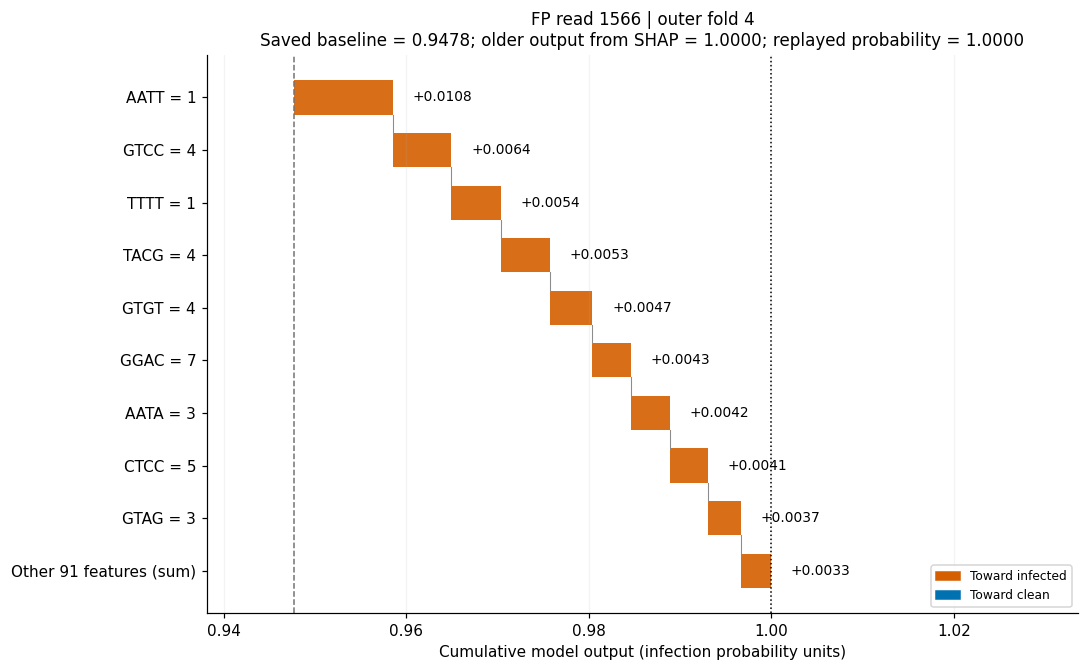

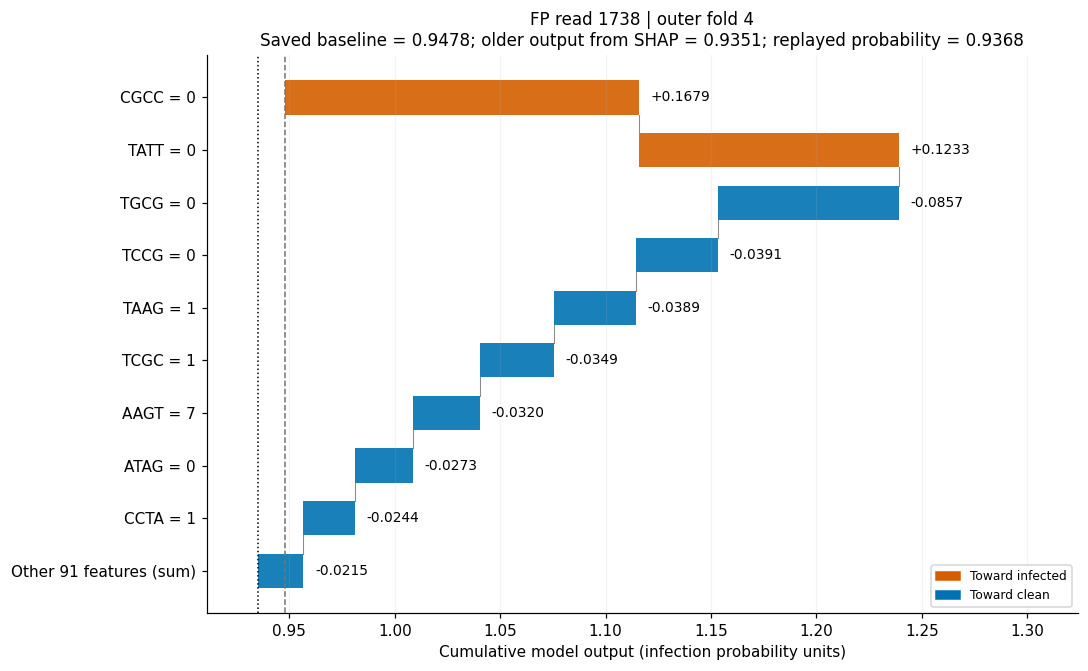

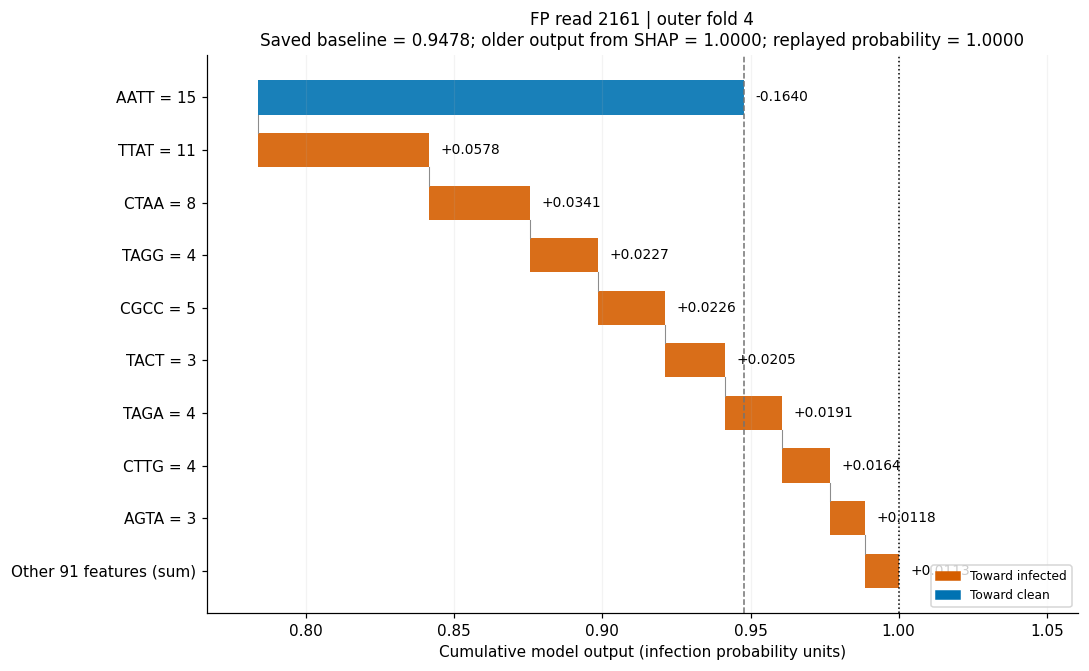

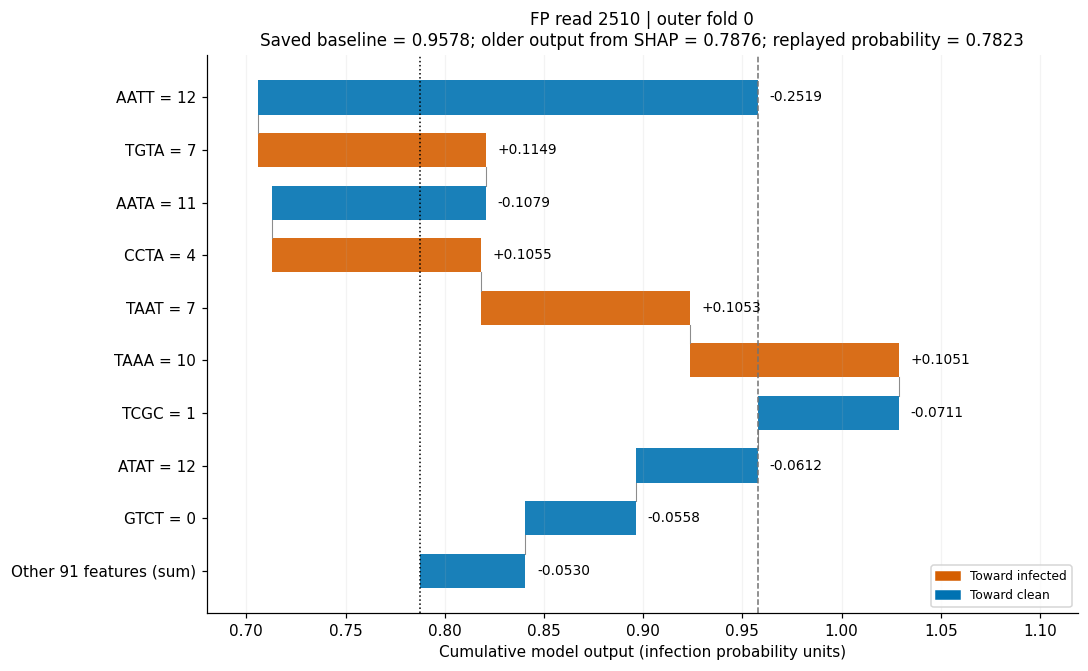

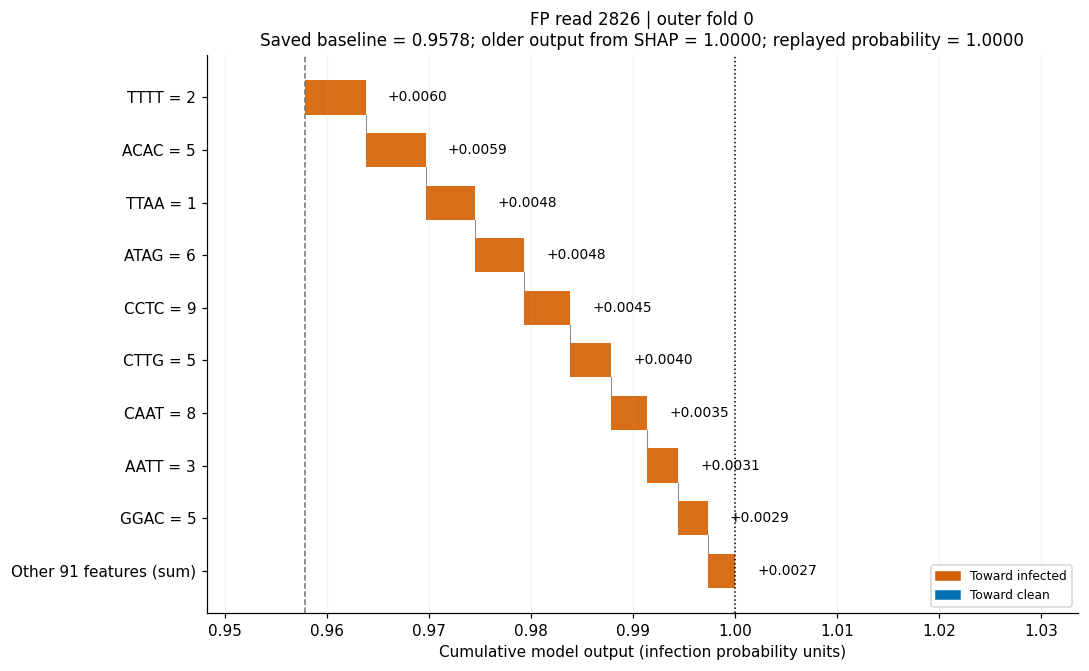

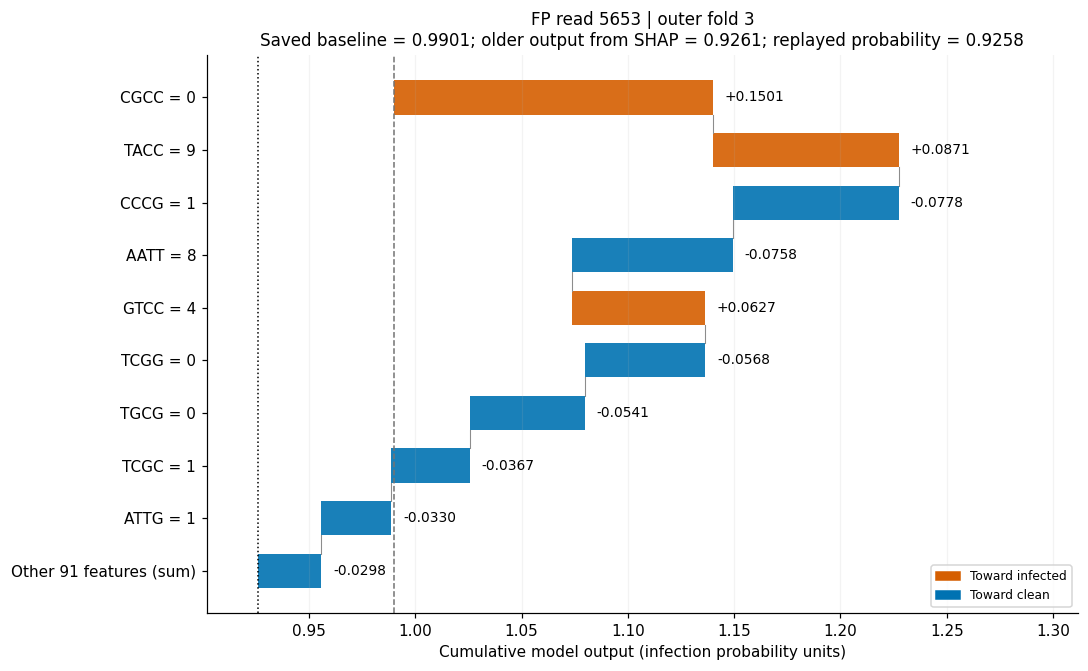

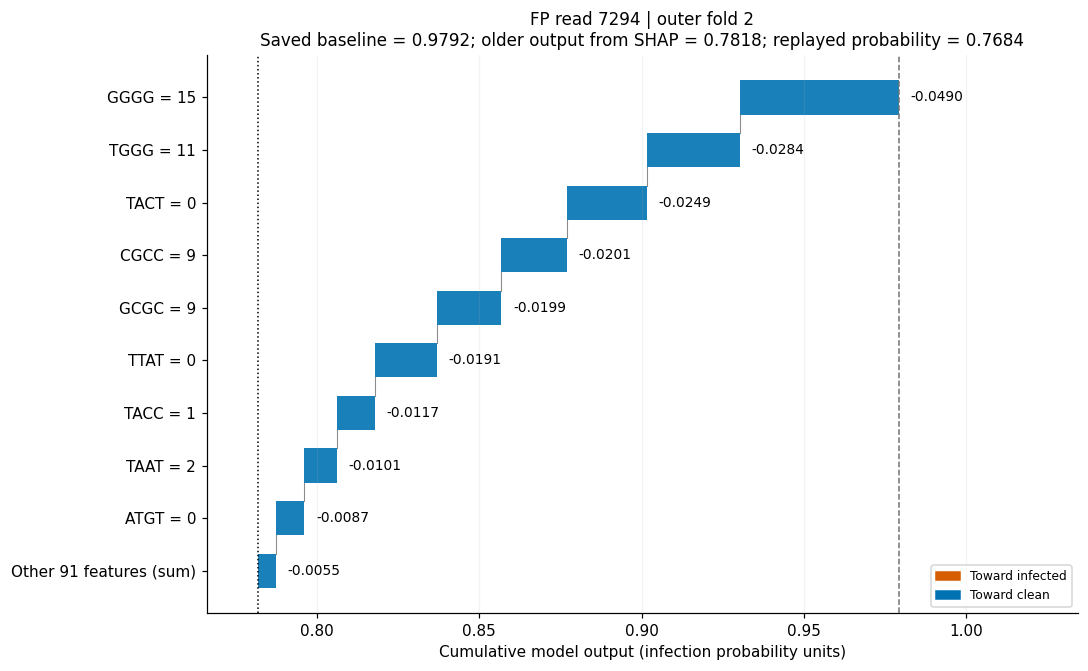

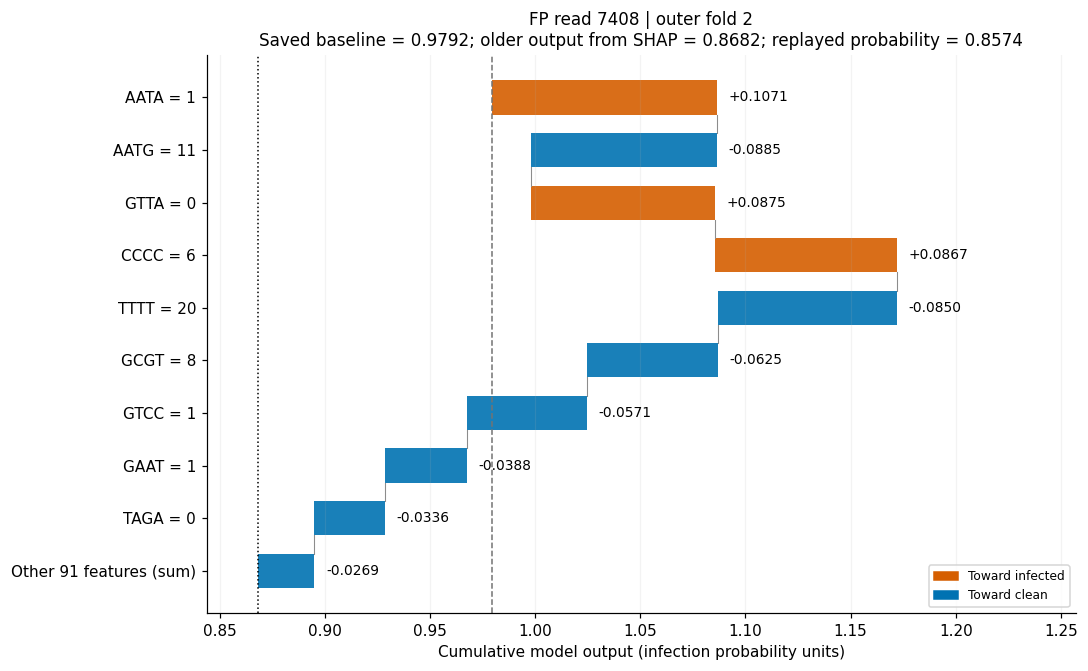

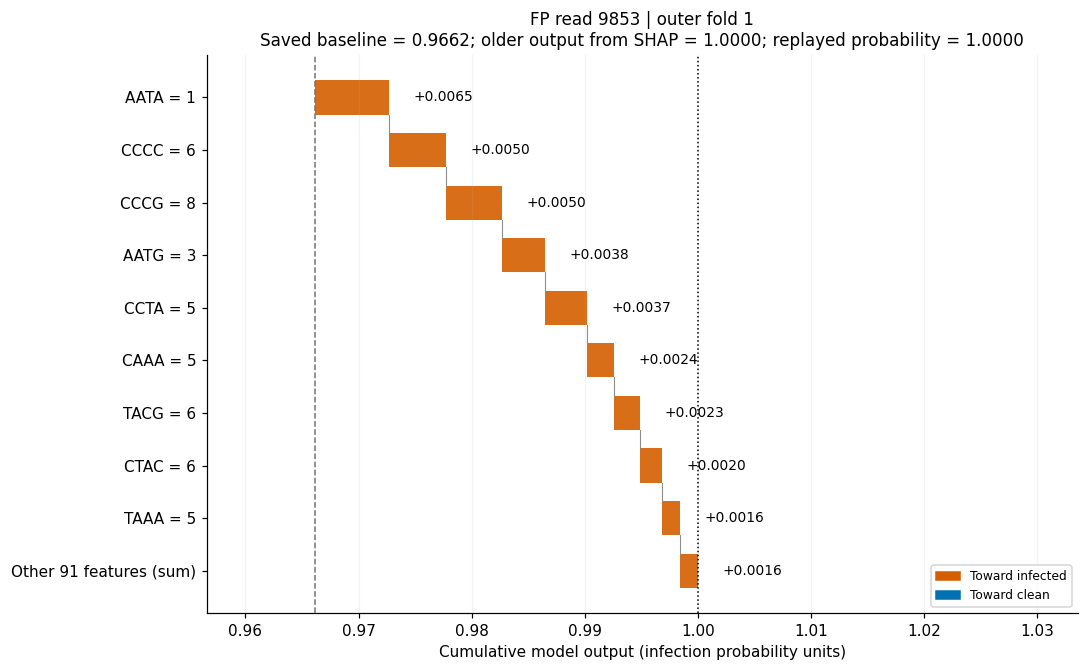

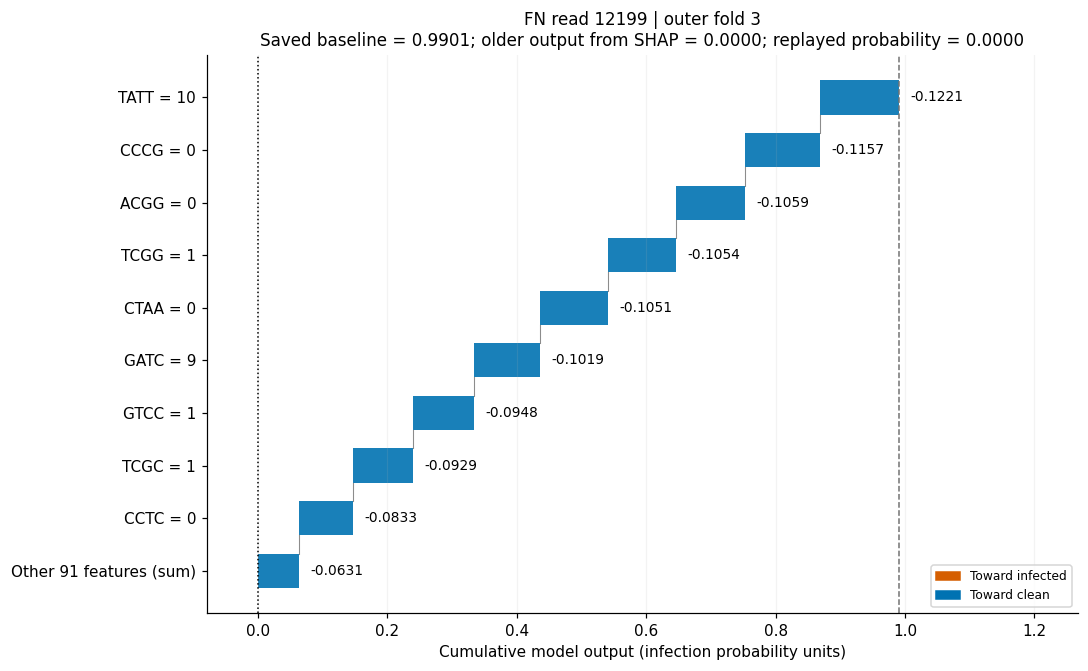

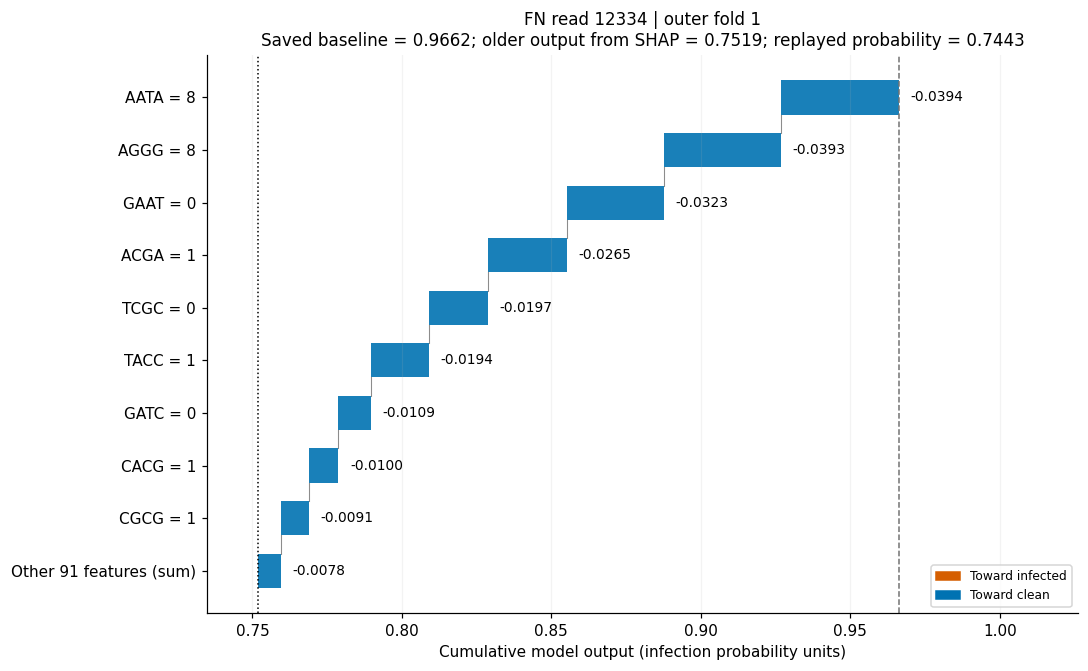

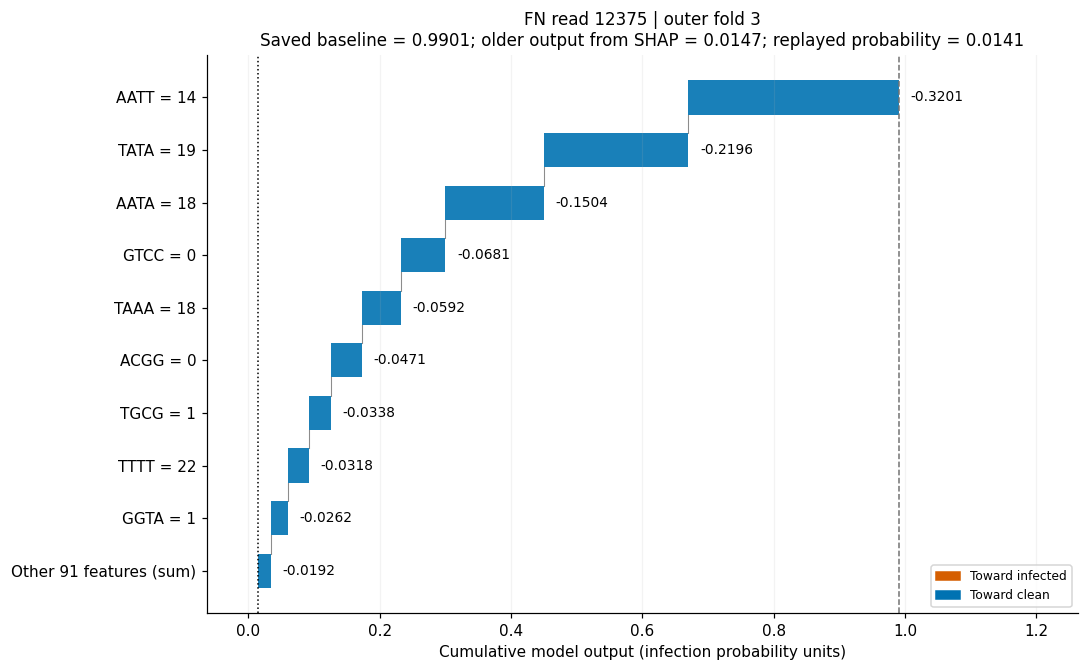

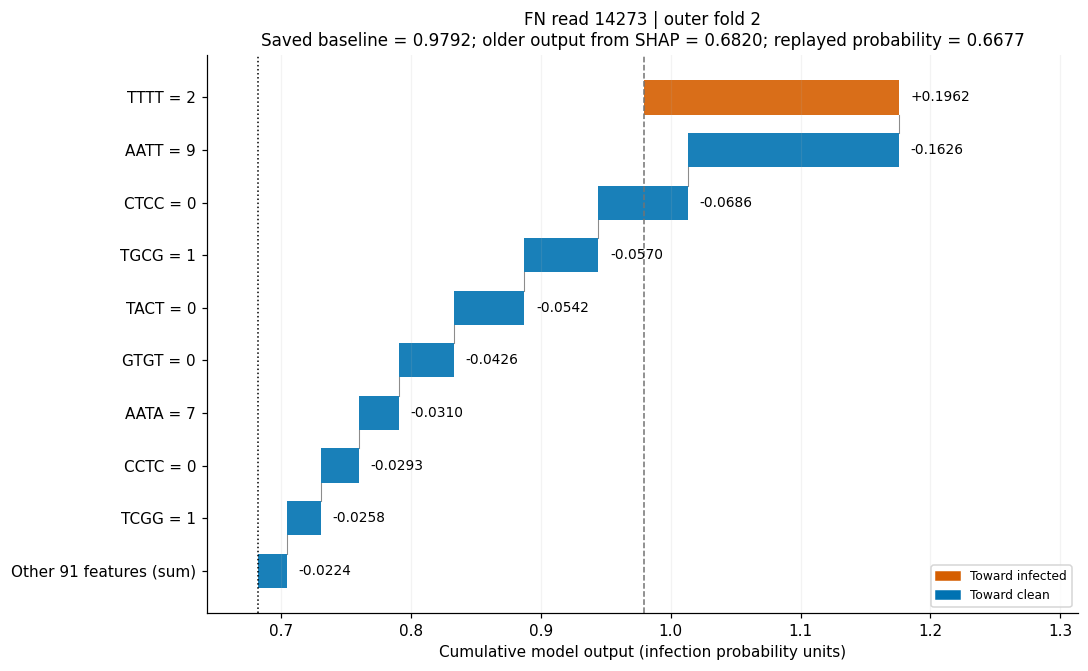

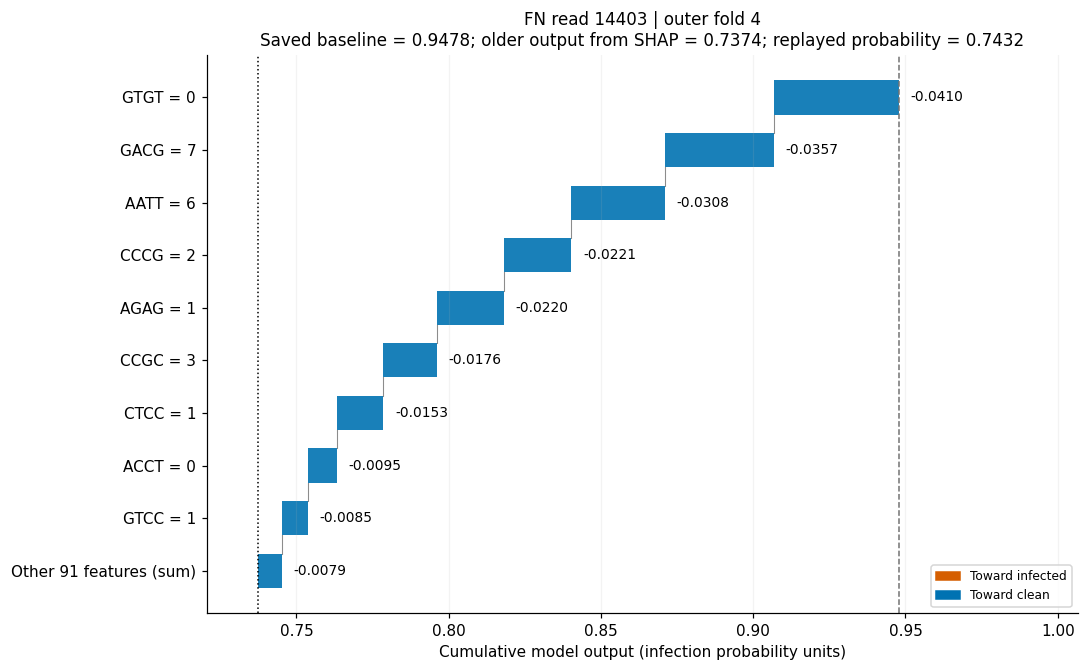

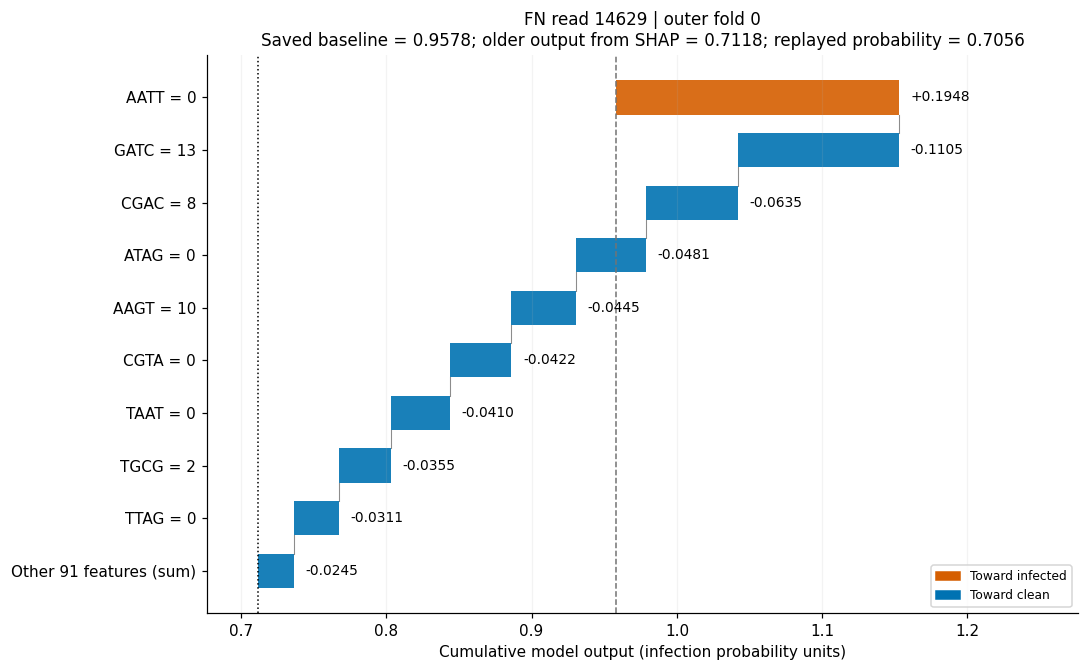

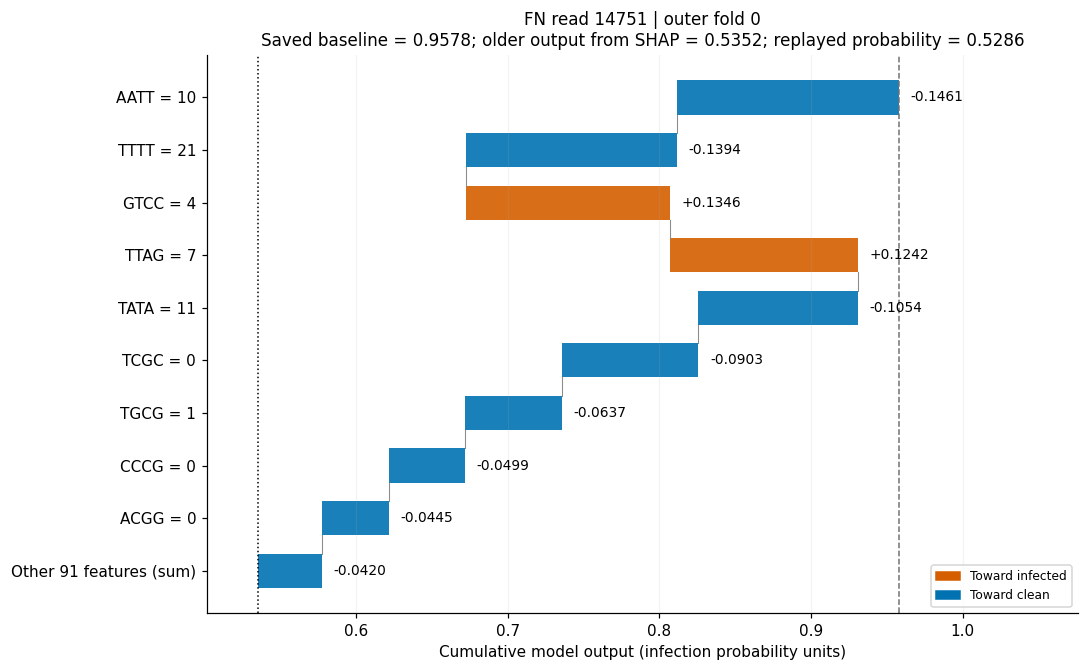

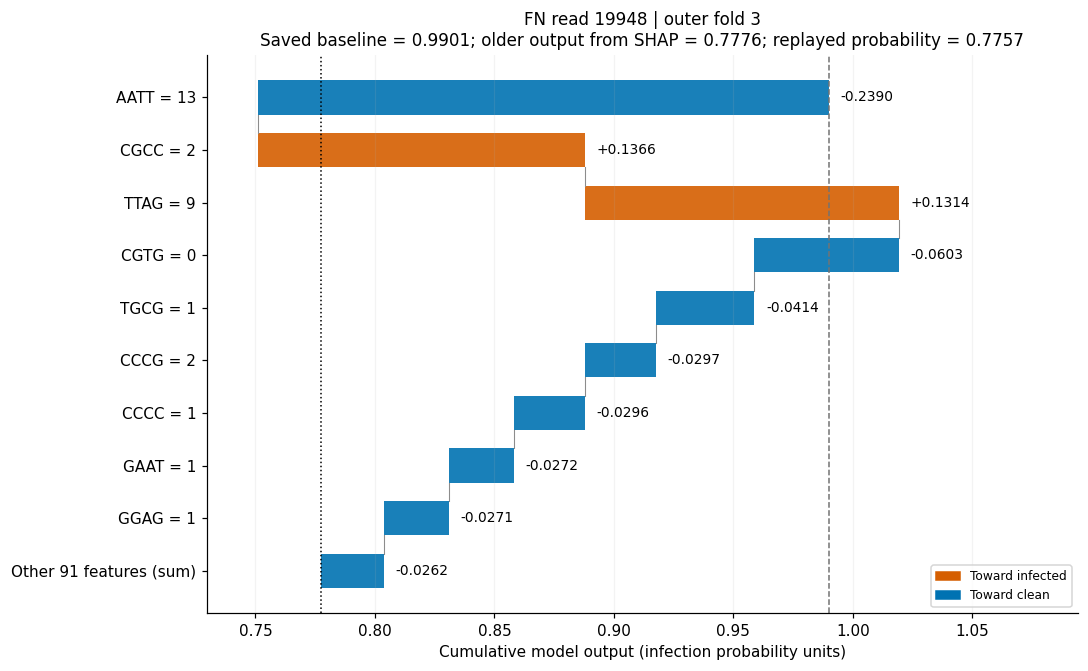

In [30]:
population_candidates, selections = [], []
for outcome, ascending in [("FP", False), ("FN", True)]:
    full = pred.loc[pred.outcome.eq(outcome)].reset_index(drop=True)
    if not full.empty:
        row = full.sort_values(["probability_infected", "read_id"], ascending=[ascending, True]).iloc[0]
        population_candidates.append({"outcome": outcome, "read_id": int(row.read_id),
                                       "probability_infected": row.probability_infected,
                                       "has_saved_SHAP": int(row.read_id) in phi.index})
    subset = reference.loc[reference.outcome.eq(outcome)].reset_index(drop=True)
    if subset.empty:
        continue
    strong = subset.sort_values(["probability_infected", "read_id"], ascending=[ascending, True]).iloc[0]
    borderline = subset.sort_values(["margin_percentile_within_fold", "read_id"]).iloc[0]
    selections.extend([
        {"read_id": int(strong.read_id), "criterion": f"{outcome}: strongest probability support for the predicted class (explained subset)"},
        {"read_id": int(borderline.read_id), "criterion": f"{outcome}: smallest within-fold absolute-score percentile (explained subset)"},
    ])
selections.extend(cluster_representatives[["read_id", "criterion"]].to_dict("records"))
selected = pd.DataFrame(selections, columns=["read_id", "criterion"])
if not selected.empty:
    selected = selected.groupby("read_id", sort=True).criterion.agg("; ".join).to_frame().join(
        reference[["outcome", "outer_fold", "probability_infected", "decision_score",
                   "margin_percentile_within_fold", "base_value", "old_probability_from_shap", "probability_difference"]]
    ).reset_index()
table(pd.DataFrame(population_candidates), "06_population_extremes_coverage")
table(selected, "06_selected_examples")

def saved_shap_waterfall(read_id):
    contributions = phi.loc[read_id]
    ordered = contributions.abs().sort_values(ascending=False, kind="stable").index.tolist()
    keep = ordered[:min(MAX_WATERFALL_FEATURES - 1, len(ordered))]
    omitted = ordered[len(keep):]
    values = contributions.loc[keep].tolist()
    labels = [f"{feature} = {saved_features.loc[read_id, feature]:g}" for feature in keep]
    if omitted:
        values.append(float(contributions.loc[omitted].sum()))
        labels.append(f"Other {len(omitted)} features (sum)")
    base = float(reference.loc[read_id, "base_value"])
    endpoints = np.r_[base, base + np.cumsum(values)]
    np.testing.assert_allclose(endpoints[-1], reference.loc[read_id, "old_probability_from_shap"], atol=1e-10)
    fig, ax = plt.subplots(figsize=(10, 6.2))
    span = max(float(np.ptp(endpoints)), .12)
    for i, value in enumerate(values):
        start, end = endpoints[i:i + 2]
        color = "#D55E00" if value >= 0 else "#0072B2"
        ax.barh(i, abs(value), left=min(start, end), height=.65, color=color, alpha=.9)
        ax.text(max(start, end) + .018 * span, i, f"{value:+.4f}", va="center", fontsize=9)
        if i < len(values) - 1:
            ax.plot([end, end], [i + .325, i + .675], color="0.55", linewidth=.7)
    ax.axvline(base, color="0.45", linestyle="--", linewidth=1)
    ax.axvline(endpoints[-1], color="black", linestyle=":", linewidth=1)
    row = reference.loc[read_id]
    ax.set(yticks=np.arange(len(labels)), yticklabels=labels,
           xlabel="Cumulative model output (infection probability units)",
           xlim=(endpoints.min() - .08 * span, endpoints.max() + .28 * span),
           title=(f"{row.outcome} read {read_id} | outer fold {int(row.outer_fold)}\n"
                  f"Saved baseline = {base:.4f}; older output from SHAP = {endpoints[-1]:.4f}; "
                  f"replayed probability = {row.probability_infected:.4f}"))
    ax.invert_yaxis(); ax.grid(axis="x", alpha=.15)
    ax.legend(handles=[Patch(color="#D55E00", label="Toward infected"),
                       Patch(color="#0072B2", label="Toward clean")], loc="lower right", fontsize=8)
    fig.tight_layout(); show_figure(fig, f"06_waterfall_read_{read_id}")

for read_id in selected.get("read_id", []):
    saved_shap_waterfall(int(read_id))


## Reporting notes

- Report the full prediction sample size and SHAP coverage separately for each outcome group.
- Feature and SHAP comparisons are conditional on the selected experiment and explained subset.
- Retain the probability-alignment audit when interpreting older explanations alongside replayed predictions.
- Error-specific importance measures association with errors; a large absolute contribution may oppose an error.
- All cuts from 2 to 6 groups are shown; silhouette is descriptive and does not select or exclude a cut.
- Assess fold composition and stability before giving clusters substantive interpretations.
- The exported provenance file records input hashes, package versions and analysis settings.
